In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nih-chest-xrays/data")

print("Path to dataset files:", path)

100%|██████████| 42.0G/42.0G [10:01<00:00, 75.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/nih-chest-xrays/data/versions/3


### ① Data Understanding

First, we will examine the basic information of the dataset and the distribution of disease labels. This will allow us to understand any biases present in the data.

In [ ]:
import pandas as pd
import os
import kagglehub # Added this import to potentially re-define path

# Ensure 'path' is defined. It should have been defined in a previous cell (pANmKzAYfOnf).
# If the kernel state was reset, this block will re-download the dataset if necessary,
# ensuring 'path' is available for this cell.
if 'path' not in locals() and 'path' not in globals():
    print("Warning: 'path' variable not found in current session. Attempting to re-download dataset...")
    path = kagglehub.dataset_download("nih-chest-xrays/data")
    print("Dataset re-downloaded to:", path)

csv_path = os.path.join(path, 'Data_Entry_2017.csv')
df = pd.read_csv(csv_path)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (112120, 12)


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


Next, we will analyze the `Finding Labels` column to check for any bias in the number of data points for each disease. This column may contain multiple labels separated by pipes `|`.

In [ ]:
# Calculate the count of each disease label
all_labels = []
for labels_str in df['Finding Labels']:
    labels = labels_str.split('|')
    all_labels.extend(labels)

label_counts = pd.Series(all_labels).value_counts()

print("Distribution of Finding Labels:")
display(label_counts)

# Also check the percentage
print("\nPercentage of Finding Labels:")
display(label_counts / len(all_labels) * 100)

print("The number of all diseases found in the images:")
display(len(all_labels))

# Especially check the percentage of 'No Finding'
if 'No Finding' in label_counts:
    no_finding_percentage = (label_counts['No Finding'] / df.shape[0]) * 100
    print(f"\n'No Finding' instances (unique images, not total labels): {df['Finding Labels'].str.contains('No Finding').sum()} ({no_finding_percentage:.2f}% of total images)")

Distribution of Finding Labels:


,count
No Finding,60361
Infiltration,19894
Effusion,13317
Atelectasis,11559
Nodule,6331
Mass,5782
Pneumothorax,5302
Consolidation,4667
Pleural_Thickening,3385
Cardiomegaly,2776



Percentage of Finding Labels:


,count
No Finding,42.646799
Infiltration,14.055689
Effusion,9.408847
Atelectasis,8.166769
Nodule,4.473035
Mass,4.085151
Pneumothorax,3.746017
Consolidation,3.297371
Pleural_Thickening,2.391601
Cardiomegaly,1.961325


The number of all diseases found in the images:


141537


'No Finding' instances (unique images, not total labels): 60361 (53.84% of total images)


In [ ]:
# Filter the DataFrame to include only 'Infiltration' or 'No Finding' labels
df_binary_classification = df[df['Finding Labels'].isin(['Infiltration', 'No Finding'])].copy()

print(f"Original DataFrame shape: {df.shape}")
print(f"Filtered DataFrame for Infiltration and No Finding shape: {df_binary_classification.shape}")

# Display the head of the filtered DataFrame
print("Filtered DataFrame head:")
display(df_binary_classification.head())

Original DataFrame shape: (112120, 12)
Filtered DataFrame for Infiltration and No Finding shape: (69908, 12)
Filtered DataFrame head:


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
13,00000005_000.png,No Finding,0,5,69,F,PA,2048,2500,0.168,0.168,NaN
14,00000005_001.png,No Finding,1,5,69,F,AP,2500,2048,0.168,0.168,NaN
15,00000005_002.png,No Finding,2,5,69,F,AP,2500,2048,0.168,0.168,NaN
16,00000005_003.png,No Finding,3,5,69,F,PA,2992,2991,0.143,0.143,NaN


We have now created `df_binary_classification` which contains only images with 'Infiltration' or 'No Finding' labels. The subsequent steps for data splitting and label numericalization will use this filtered DataFrame.

### ② Data Splitting

A crucial rule for data splitting is to ensure that images from the same patient do not overlap across the training, validation, and test sets. To prevent this data leakage, we will split the dataset based on `Patient ID`.

Furthermore, considering the imbalance of disease labels and the characteristics of multi-label classification, we will apply stratified sampling. To avoid the problem of too many disease label combinations for stratification keys, we will simplify each patient's disease status into aggregated categories: "No Finding only," "1 type of disease," "2 types of diseases," or "3 or more types of diseases."

This will ensure that each dataset (training, validation, and test) is representative in terms of disease distribution.

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

# Get all unique disease labels (excluding 'No Finding')
all_disease_labels = sorted([label for label in label_counts.index if label != 'No Finding'])
print("All unique disease labels (excluding 'No Finding'):", all_disease_labels)

# --- Stratification Key Generation --- #

# Helper function to get a patient-level stratification key based on disease presence and count.
def get_patient_stratification_key(patient_df_group, all_disease_labels_list):
    all_finding_labels_for_patient = []
    for labels_str in patient_df_group['Finding Labels'].tolist():
        all_finding_labels_for_patient.extend(labels_str.split('|'))

    unique_diseases_for_patient = set()
    has_no_finding = False
    for label in all_finding_labels_for_patient:
        if label == 'No Finding':
            has_no_finding = True
        elif label in all_disease_labels_list:
            unique_diseases_for_patient.add(label)

    if not unique_diseases_for_patient and has_no_finding:
        # Patient has only 'No Finding' across all their images
        return "No_Finding_Only"
    elif unique_diseases_for_patient:
        # Patient has at least one disease. Stratify by number of unique diseases.
        num_diseases = len(unique_diseases_for_patient)
        if num_diseases == 1:
            return "Diseases_1"
        elif num_diseases == 2:
            return "Diseases_2"
        elif num_diseases >= 3: # Group 3 or more diseases together
            return "Diseases_3Plus"
        else: # Should not happen if unique_diseases_for_patient is not empty
            return "Unknown_Disease_Count"
    else:
        # Patient has neither 'No Finding' nor any specific disease (e.g., empty 'Finding Labels' string)
        # This is an edge case, but good to handle.
        return "No_Labels_Found"

# Generate a stratification key for each unique patient
# `patient_stratify_keys` will be a Series with Patient ID as index
# and a simplified stratification string as its value.
patient_stratify_keys = df.groupby('Patient ID').apply(
    lambda x: get_patient_stratification_key(x, all_disease_labels)
)

# Get the list of unique patient IDs that will be split
patient_ids_for_split = patient_stratify_keys.index.to_numpy()

# Create the `y` array for the `stratify` parameter, matching the order of `patient_ids_for_split`
# This `y` array contains the stratification key for each patient.
stratify_y = patient_stratify_keys.to_numpy()

print(f"Number of unique stratification key combinations: {len(np.unique(stratify_y))}")

# --- End of Stratification Key Generation --- #

# Split Patient IDs for training, validation, and testing
# First, split into training+validation and test sets (e.g., 80% / 20%)
# Stratified sampling is performed using patient-specific disease label information for the `stratify` parameter.
patient_train_val, patient_test, _, _ = train_test_split(
    patient_ids_for_split, stratify_y, test_size=0.2, random_state=42, stratify=stratify_y
)

# Next, split training+validation into training and validation sets (e.g., 70% training, 10% validation from 80% total)
val_size_relative_to_train_val = (0.1 / (1 - 0.2)) # 0.1 / 0.8 = 0.125

# The `stratify` argument passed to `train_test_split` must correspond to the data being split (`patient_train_val`).
# Therefore, filter and use stratification keys that match the patient IDs included in `patient_train_val`.
stratify_y_train_val = patient_stratify_keys.loc[patient_train_val].to_numpy()

patient_train, patient_val, _, _ = train_test_split(
    patient_train_val,
    stratify_y_train_val, # Use the filtered stratification keys
    test_size=val_size_relative_to_train_val,
    random_state=42,
    stratify=stratify_y_train_val # Use the filtered stratification keys
)

print(f"Total unique patients: {len(patient_ids_for_split)}")
print(f"Train patients: {len(patient_train)}")
print(f"Validation patients: {len(patient_val)}")
print(f"Test patients: {len(patient_test)}")

# Create dataframes based on the split patient IDs
df_train = df[df['Patient ID'].isin(patient_train)]
df_val = df[df['Patient ID'].isin(patient_val)]
df_test = df[df['Patient ID'].isin(patient_test)]

print(f"\nTrain dataset shape: {df_train.shape}")
print(f"Validation dataset shape: {df_val.shape}")
print(f"Test dataset shape: {df_test.shape}")

# Display a few sample images from each set
print("\nTrain set head:")
display(df_train.head())

All unique disease labels (excluding 'No Finding'): ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']
Number of unique stratification key combinations: 4
Total unique patients: 30805
Train patients: 21563
Validation patients: 3081
Test patients: 6161

Train dataset shape: (78059, 12)
Validation dataset shape: (12007, 12)
Test dataset shape: (22054, 12)

Train set head:


/tmp/ipykernel_4926/3229201189.py:46: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  patient_stratify_keys = df.groupby('Patient ID').apply(


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


### Filtering DataFrames for Binary Classification (Infiltration vs. No Finding)

To align with the strategy of focusing on 'Infiltration' versus 'No Finding', we will filter the `df_train`, `df_val`, and `df_test` DataFrames. This creates new dataframes containing only these two labels, which will be used for binary classification training.

In [ ]:
# Filter the training, validation, and test DataFrames to include only 'Infiltration' or 'No Finding' labels
df_train_binary = df_train[df_train['Finding Labels'].isin(['Infiltration', 'No Finding'])].copy()
df_val_binary = df_val[df_val['Finding Labels'].isin(['Infiltration', 'No Finding'])].copy()
df_test_binary = df_test[df_test['Finding Labels'].isin(['Infiltration', 'No Finding'])].copy()

print(f"\nFiltered Training DataFrame (Infiltration/No Finding) shape: {df_train_binary.shape}")
print(f"Filtered Validation DataFrame (Infiltration/No Finding) shape: {df_val_binary.shape}")
print(f"Filtered Test DataFrame (Infiltration/No Finding) shape: {df_test_binary.shape}")

# Display the head of the filtered training DataFrame
print("\nFiltered Training DataFrame head:")
display(df_train_binary.head())


Filtered Training DataFrame (Infiltration/No Finding) shape: (48772, 12)
Filtered Validation DataFrame (Infiltration/No Finding) shape: (7265, 12)
Filtered Test DataFrame (Infiltration/No Finding) shape: (13871, 12)

Filtered Training DataFrame head:


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
13,00000005_000.png,No Finding,0,5,69,F,PA,2048,2500,0.168,0.168,NaN
14,00000005_001.png,No Finding,1,5,69,F,AP,2500,2048,0.168,0.168,NaN
15,00000005_002.png,No Finding,2,5,69,F,AP,2500,2048,0.168,0.168,NaN
16,00000005_003.png,No Finding,3,5,69,F,PA,2992,2991,0.143,0.143,NaN


Let's examine the distribution of 'Infiltration' and 'No Finding' labels within these binary classification datasets to understand the class balance in each split.


--- Train (Binary) Dataset Binary Label Distribution ---
Total images: 48772


,Count,Percentage
Finding Labels,,
No Finding,42075,86.268761
Infiltration,6697,13.731239



--- Validation (Binary) Dataset Binary Label Distribution ---
Total images: 7265


,Count,Percentage
Finding Labels,,
No Finding,6233,85.794907
Infiltration,1032,14.205093



--- Test (Binary) Dataset Binary Label Distribution ---
Total images: 13871


,Count,Percentage
Finding Labels,,
No Finding,12053,86.893519
Infiltration,1818,13.106481


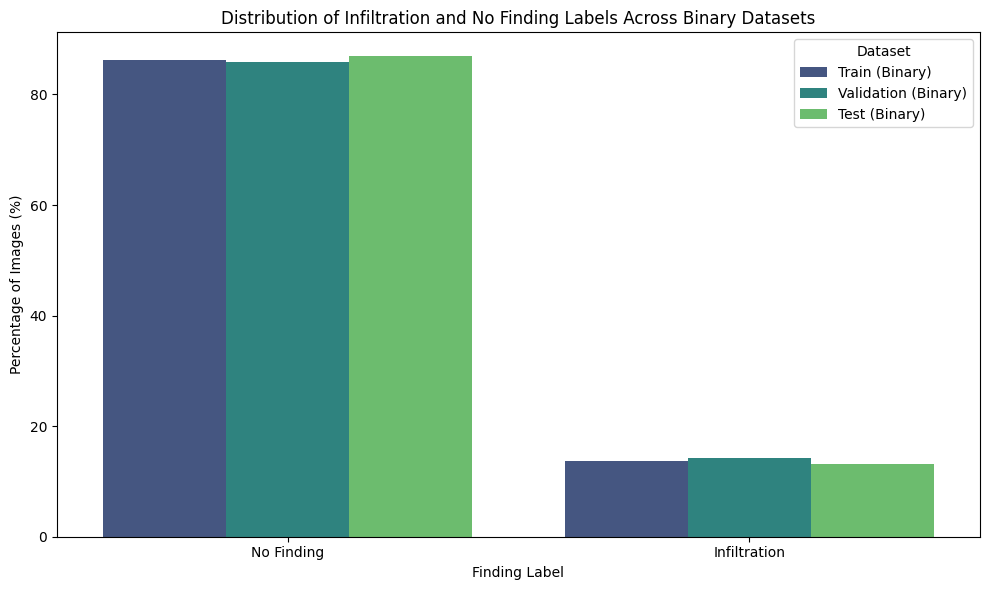

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def get_binary_label_distribution(df_subset, dataset_name):
    # Count 'No Finding' and 'Infiltration'
    label_counts = df_subset['Finding Labels'].value_counts()

    # Ensure both labels are present, even if count is 0
    if 'No Finding' not in label_counts: label_counts['No Finding'] = 0
    if 'Infiltration' not in label_counts: label_counts['Infiltration'] = 0

    total_images = len(df_subset)
    label_percentages = (label_counts / total_images) * 100

    print(f"\n--- {dataset_name} Dataset Binary Label Distribution ---")
    print(f"Total images: {total_images}")
    display(pd.DataFrame({'Count': label_counts, 'Percentage': label_percentages}))

    return pd.DataFrame({
        'Label': label_percentages.index,
        'Percentage': label_percentages.values,
        'Dataset': dataset_name
    })

# Get distributions for each binary split
binary_dist_train = get_binary_label_distribution(df_train_binary, 'Train (Binary)')
binary_dist_val = get_binary_label_distribution(df_val_binary, 'Validation (Binary)')
binary_dist_test = get_binary_label_distribution(df_test_binary, 'Test (Binary)')

# Concatenate for plotting
combined_binary_dist = pd.concat([binary_dist_train, binary_dist_val, binary_dist_test])

plt.figure(figsize=(10, 6))
sns.barplot(x='Label', y='Percentage', hue='Dataset', data=combined_binary_dist, palette='viridis')
plt.title('Distribution of Infiltration and No Finding Labels Across Binary Datasets')
plt.ylabel('Percentage of Images (%)')
plt.xlabel('Finding Label')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### ③ Strategy for Pre-processing

This section describes the pre-processing strategy for images and labels. While the actual code implementation is often done as part of the model training pipeline, here we clarify the approach.

#### 1. Resizing

*   **Policy:** Original image size will be reduced to 64x64, which balances detail preservation with processing speed and memory usage. This size is commonly used as input for various deep learning models.

#### 2. Normalization

*   **Policy:** Image pixel values (0-255) will be normalized to the range of 0-1 by dividing by 255.0. ImageNet's mean and standard deviation will *not* be used for standardization, as these are typically not suitable for X-ray images and we confirmed the images are 8-bit.

#### 3. Channel Handling

*   **Policy:** X-ray images are typically grayscale. For compatibility with many deep learning models (especially those pre-trained on ImageNet that expect 3 channels), images will be loaded as grayscale and processed to have a single channel output, formatted as `(1, Height, Width)` for PyTorch compatibility. This means the single grayscale channel will be used as-is, without repeating it three times.


### Image Preprocessing Implementation Policy

In [ ]:
from PIL import Image
import numpy as np

# Define the preprocessing function
def preprocess_image(image_path, target_size=(64, 64)):
    # 1. Load image in grayscale
    img = Image.open(image_path).convert('L') # 'L' for grayscale

    # 2. Resize
    img = img.resize(target_size, Image.LANCZOS)

    # 3. Convert to numpy array and scale to 0-1
    img_array = np.array(img).astype(np.float32) / 255.0

    # 4. Add a channel dimension at the beginning for 1-channel grayscale image (H, W) -> (1, H, W)
    img_array = np.expand_dims(img_array, axis=0)

    return img_array

print("Defined image preprocessing function `preprocess_image`.")

Defined image preprocessing function `preprocess_image`.


The `preprocess_image` function takes an image file path, resizes it, converts it to 1 channel (grayscale), and normalizes pixel values to a 0-1 range, returning a NumPy array with shape `(1, Height, Width)`.

**Notes:**
*   Only 0-1 scaling is done within this function.
*   This function will be applied to image paths derived from the 'Image Index' column in `df_train`, `df_val`, and `df_test` when creating the final dataset.

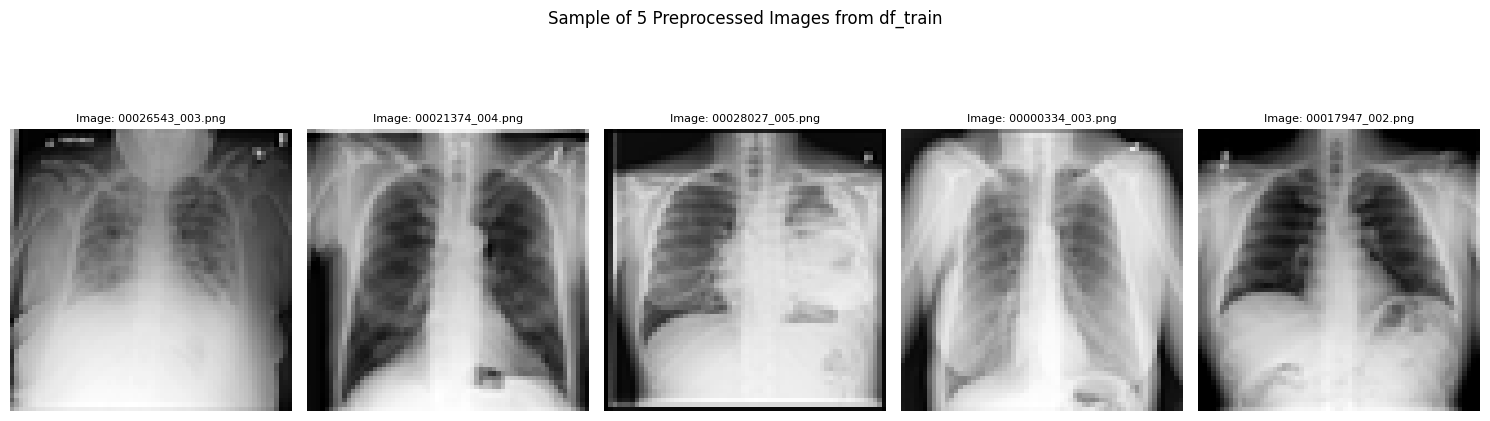

In [ ]:
import matplotlib.pyplot as plt
import random
import os # Import os for path manipulation

# Helper function to find the actual path of an image
def find_full_image_path(image_filename, base_path):
    # Potential subdirectories where images might be located
    # Based on the structure observed in the NIH Chest X-ray dataset
    potential_subdirs = [f'images_{i:03d}' for i in range(1, 13)] # images_001 to images_012

    for sub_dir in potential_subdirs:
        candidate_path = os.path.join(base_path, sub_dir, 'images', image_filename)
        if os.path.exists(candidate_path):
            return candidate_path
    # If not found in any standard subdirectory, try direct path under 'images' (less common but good fallback)
    candidate_path_direct = os.path.join(base_path, 'images', image_filename)
    if os.path.exists(candidate_path_direct):
        return candidate_path_direct
    return None # Image not found

num_images_to_display = 5 # Number of images to display

# Select random image indices from df_train
random_indices = random.sample(range(len(df_train)), num_images_to_display)

plt.figure(figsize=(15, 5))

for i, idx in enumerate(random_indices):
    image_filename = df_train.iloc[idx]['Image Index']
    full_image_path = find_full_image_path(image_filename, path) # 'path' is the base path of the dataset

    if full_image_path:
        processed_img_array = preprocess_image(full_image_path) # Apply the preprocessing function

        plt.subplot(1, num_images_to_display, i + 1)
        # imshow expects (H, W) or (H, W, C) format, so remove the channel from (1, H, W)
        plt.imshow(processed_img_array.squeeze(), cmap='gray')
        plt.title(f"Image: {image_filename}", fontsize=8)
        plt.axis('off')
    else:
        print(f"Warning: Image file not found for {image_filename}")

plt.tight_layout()
plt.suptitle(f'Sample of {num_images_to_display} Preprocessed Images from df_train', y=1.02) # Overall title
plt.show()

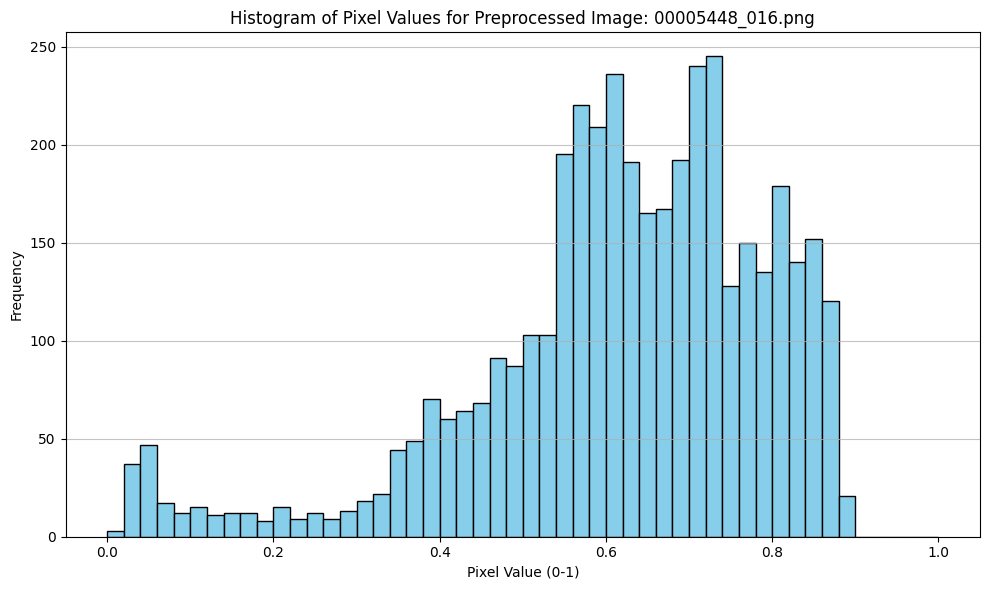

In [ ]:
import matplotlib.pyplot as plt
import random

# Get a random image from df_train for demonstration
random_idx_hist = random.randint(0, len(df_train) - 1)
image_filename_hist = df_train.iloc[random_idx_hist]['Image Index']
full_image_path_hist = find_full_image_path(image_filename_hist, path)

if full_image_path_hist:
    # Preprocess the image
    processed_img_for_hist = preprocess_image(full_image_path_hist)

    # Flatten the image array to 1D for histogram plotting
    flattened_pixels = processed_img_for_hist.flatten()

    plt.figure(figsize=(10, 6))
    plt.hist(flattened_pixels, bins=50, color='skyblue', edgecolor='black', range=(0, 1))
    plt.title(f'Histogram of Pixel Values for Preprocessed Image: {image_filename_hist}')
    plt.xlabel('Pixel Value (0-1)')
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)
    plt.tight_layout()
    plt.show()
else:
    print(f"Warning: Image file not found for {image_filename_hist}")

In [ ]:
import random

# Select a random image from the DataFrame for demonstration
random_idx = random.randint(0, len(df) - 1)
random_image_filename = df.loc[random_idx, 'Image Index']

# Find the full path to the image
full_path_for_demo = find_full_image_path(random_image_filename, path)

if full_path_for_demo:
    print(f"Processing random image: {random_image_filename}")
    print(f"Full path: {full_path_for_demo}")
    # Apply the preprocess_image function
    processed_img_array = preprocess_image(full_path_for_demo, target_size=(512, 512))

    # Display the properties of the processed image
    print(f"Processed image shape: {processed_img_array.shape}")
    print(f"Processed image data type: {processed_img_array.dtype}")
    print(f"Processed image min value: {processed_img_array.min()}")
    print(f"Processed image max value: {processed_img_array.max()}")
else:
    print(f"Error: Could not find image file for {random_image_filename} at expected locations.")

Processing random image: 00017360_000.png
Full path: /root/.cache/kagglehub/datasets/nih-chest-xrays/data/versions/3/images_008/images/00017360_000.png
Processed image shape: (1, 512, 512)
Processed image data type: float32
Processed image min value: 0.0
Processed image max value: 1.0


### ④ Image Pixel Value Check

We will inspect a sample X-ray image to verify its pixel value range and data type to understand its true bit depth (e.g., 8-bit vs. 12/16-bit).

In [ ]:
import os
# Using the 'path' variable obtained in cell [3]
images_path = os.path.join(path, 'images_001', 'images')
if os.path.exists(images_path):
    print("Image folder found!:", images_path)
    print("First 5 files:", os.listdir(images_path)[:5])
else:
    print("Path seems to be incorrect.")

Image folder found!: /root/.cache/kagglehub/datasets/nih-chest-xrays/data/versions/3/images_001/images
First 5 files: ['00001222_012.png', '00000746_000.png', '00000428_000.png', '00000470_000.png', '00000802_000.png']


In [ ]:
from PIL import Image
import numpy as np
import os
import random

# Helper function to find the actual path of an image
def find_full_image_path(image_filename, base_path):
    # Potential subdirectories where images might be located
    # Based on the structure observed in the NIH Chest X-ray dataset
    potential_subdirs = [f'images_{i:03d}' for i in range(1, 13)] # images_001 to images_012

    for sub_dir in potential_subdirs:
        candidate_path = os.path.join(base_path, sub_dir, 'images', image_filename)
        if os.path.exists(candidate_path):
            return candidate_path
    # If not found in any standard subdirectory, try direct path under 'images' (less common but good fallback)
    candidate_path_direct = os.path.join(base_path, 'images', image_filename)
    if os.path.exists(candidate_path_direct):
        return candidate_path_direct
    return None # Image not found

num_samples = 5
# Randomly select image indices from the DataFrame
random_image_indices = random.sample(range(len(df)), num_samples)

print(f"Checking {num_samples} random images:")
for i, idx in enumerate(random_image_indices):
    image_filename = df.loc[idx, 'Image Index']
    full_image_path = find_full_image_path(image_filename, path) # 'path' is the base path from kagglehub download

    if full_image_path:
        try:
            img = Image.open(full_image_path)
            img_array = np.array(img)
            print(f"\n--- Sample {i+1}: Image Index: {image_filename} ---")
            print(f"Full path: {full_image_path}")
            print(f"Max value: {img_array.max()}")
            print(f"Data type: {img_array.dtype}")
        except Exception as e:
            print(f"\n--- Sample {i+1}: Image Index: {image_filename} ---")
            print(f"Error opening image {full_image_path}: {e}")
    else:
        print(f"\n--- Sample {i+1}: Image Index: {image_filename} ---")
        print(f"Warning: Image file not found at expected locations for {image_filename}.")


Checking 5 random images:

--- Sample 1: Image Index: 00017972_040.png ---
Full path: /root/.cache/kagglehub/datasets/nih-chest-xrays/data/versions/3/images_008/images/00017972_040.png
Max value: 255
Data type: uint8

--- Sample 2: Image Index: 00013112_007.png ---
Full path: /root/.cache/kagglehub/datasets/nih-chest-xrays/data/versions/3/images_006/images/00013112_007.png
Max value: 253
Data type: uint8

--- Sample 3: Image Index: 00014644_000.png ---
Full path: /root/.cache/kagglehub/datasets/nih-chest-xrays/data/versions/3/images_007/images/00014644_000.png
Max value: 255
Data type: uint8

--- Sample 4: Image Index: 00003028_072.png ---
Full path: /root/.cache/kagglehub/datasets/nih-chest-xrays/data/versions/3/images_002/images/00003028_072.png
Max value: 255
Data type: uint8

--- Sample 5: Image Index: 00030016_000.png ---
Full path: /root/.cache/kagglehub/datasets/nih-chest-xrays/data/versions/3/images_012/images/00030016_000.png
Max value: 155
Data type: uint8


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import os

# --- 1. Define the Dataset Class ---
class NIHChestXrayDataset(Dataset):
    def __init__(self, dataframe, image_dir):
        self.dataframe = dataframe
        self.image_dir = image_dir

        # Pre-scan the contents of all image folders (images_001 to 012) for speed optimization
        self.all_image_paths = {}
        for sub_dir in [f'images_{i:03d}' for i in range(1, 13)]:
            full_sub_dir = os.path.join(image_dir, sub_dir, 'images')
            if os.path.exists(full_sub_dir):
                for f in os.listdir(full_sub_dir):
                    self.all_image_paths[f] = os.path.join(full_sub_dir, f)

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        # Get the filename from the CSV
        img_name = self.dataframe.iloc[idx]['Image Index']
        img_path = self.all_image_paths.get(img_name)

        if img_path is None:
            raise FileNotFoundError(f"Image {img_name} not found.")

        # Call the already created 'preprocess_image' function
        # This function is assumed to perform grayscale conversion, resizing, and 255-normalization
        image_np = preprocess_image(img_path)

        # Convert NumPy array to PyTorch tensor
        # If preprocess_image returns (1, 512, 512), convert as is
        image_tensor = torch.from_numpy(image_np).float()

        # Get the label (e.g., No Finding = 0, otherwise = 1)
        label_text = self.dataframe.iloc[idx]['Finding Labels']
        label = 0 if label_text == 'No Finding' else 1

        return image_tensor, label

# --- 2. Create the DataLoader ---
# Using df_train and df_val split by Mashiro
# 'path' should specify the base path obtained from kagglehub
image_base_path = path

train_dataset = NIHChestXrayDataset(dataframe=df_train, image_dir=image_base_path)
val_dataset = NIHChestXrayDataset(dataframe=df_val, image_dir=image_base_path)

# Assignment: The final DataLoader to feed images into ViT
# Set batch_size to 64 or similar according to the syllabus code [cite: 2, 3]
batch_size = 64 # Define batch_size here
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"DataLoader is ready! Number of batches per epoch: {len(train_loader)}")

DataLoader is ready! Number of batches per epoch: 1220


### Creating Sub-datasets (for Hyperparameter Tuning)

To quickly tune hyperparameters, we will create sub-datasets by sampling a small number of images from the training and validation datasets.

In [ ]:
import numpy as np

# Create training sub-dataset (1000 images) from df_train_binary
num_train_samples_sub = 1000
if len(df_train_binary) < num_train_samples_sub:
    print(f"Warning: The number of samples in df_train_binary ({len(df_train_binary)}) is less than {num_train_samples_sub}, so all samples will be used.")
    df_train_sub = df_train_binary.copy()
else:
    df_train_sub = df_train_binary.sample(n=num_train_samples_sub, random_state=42).copy()

# Create validation sub-dataset (200 images) from df_val_binary
num_val_samples_sub = 200
if len(df_val_binary) < num_val_samples_sub:
    print(f"Warning: The number of samples in df_val_binary ({len(df_val_binary)}) is less than {num_val_samples_sub}, so all samples will be used.")
    df_val_sub = df_val_binary.copy()
else:
    df_val_sub = df_val_binary.sample(n=num_val_samples_sub, random_state=42).copy()

print(f"Shape of created training sub-dataset: {df_train_sub.shape}")
print(f"Shape of created validation sub-dataset: {df_val_sub.shape}")

# Display the head of the sub-datasets
print("df_train_sub head:")
display(df_train_sub.head())

print("df_val_sub head:")
display(df_val_sub.head())

Shape of created training sub-dataset: (1000, 12)
Shape of created validation sub-dataset: (200, 12)
df_train_sub head:


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
41983,00010808_010.png,No Finding,10,10808,34,F,AP,2500,2048,0.168,0.168,NaN
27859,00007256_001.png,No Finding,1,7256,65,M,AP,3056,2544,0.139,0.139,NaN
89304,00022170_003.png,Infiltration,3,22170,27,F,AP,3056,2544,0.139,0.139,NaN
101393,00026936_000.png,No Finding,0,26936,43,F,PA,2544,3056,0.139,0.139,NaN
100177,00026546_010.png,No Finding,10,26546,32,F,PA,2992,2991,0.143,0.143,NaN


df_val_sub head:


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
21327,00005684_005.png,No Finding,5,5684,26,M,AP,2500,2048,0.171,0.171,NaN
65581,00016189_000.png,No Finding,0,16189,58,M,PA,2778,2991,0.143,0.143,NaN
92394,00023075_010.png,No Finding,10,23075,29,M,PA,2992,2991,0.143,0.143,NaN
62595,00015502_002.png,No Finding,2,15502,47,M,AP,2500,2048,0.168,0.168,NaN
38465,00010054_003.png,Infiltration,3,10054,21,F,PA,2730,2991,0.143,0.143,NaN


Next, we will use these sub-datasets (which are now filtered for 'Infiltration' vs. 'No Finding' binary classification) to create new `NIHChestXrayDataset` and `DataLoader` instances. This allows us to quickly experiment with model hyperparameters using these smaller datasets, instead of training on the entire original dataset.

In [ ]:
# Create DataLoaders for the sub-datasets
train_dataset_sub = NIHChestXrayDataset(dataframe=df_train_sub, image_dir=image_base_path)
val_dataset_sub = NIHChestXrayDataset(dataframe=df_val_sub, image_dir=image_base_path)

train_loader_sub = DataLoader(train_dataset_sub, batch_size=batch_size, shuffle=True)
val_loader_sub = DataLoader(val_dataset_sub, batch_size=batch_size, shuffle=False)

print(f"Sub-training DataLoader is ready! Number of batches per epoch: {len(train_loader_sub)}")
print(f"Sub-validation DataLoader is ready! Number of batches per epoch: {len(val_loader_sub)}")

Sub-training DataLoader is ready! Number of batches per epoch: 16
Sub-validation DataLoader is ready! Number of batches per epoch: 4


Now, you can run the training loop using `train_loader_sub` and `val_loader_sub` instead of `train_loader` and `val_loader` to tune hyperparameters. By temporarily replacing `train_loader` and `val_loader` in the existing training loop (cell `0tK_RdvP0D-5`) with these sub-loaders, you can quickly check the model's behavior on a smaller dataset.

### ⑤ Vision Transformer Model

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Resume Training from Checkpoint

To resume training, we need to load the last saved checkpoint, which contains the model's state, optimizer's state, and the epoch number where it left off. We'll then set the training loop to start from the next epoch.

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import os
import glob
from sklearn.metrics import f1_score, recall_score # Import f1_score and recall_score

# --- IMPORTANT: The DataLoader cell (defining train_loader and val_loader, cell `dONj8bZ-qqR_`)
#               must be executed before this cell to avoid NameError. If restarting the kernel,
#               please run all cells from "### ② Data Splitting" down to the DataLoader definitions. ---

# --- Training Configuration ---
# Number of training samples processed before the model's internal parameters are updated
batch_size = 64

# --- Image Geometry ---
# Height and width of the input image (28x28 pixels)
img_size = 64 # Changed from 28 to 64

# Size of the smaller square 'tiles' the image is divided into (7x7 pixels)
patch_size = 16 # Changed from 7 to 64

# Number of color channels (1 for Grayscale, 3 for RGB)
num_channels = 1

# --- Patch Calculation ---
# Total number of patches per image: (28 / 7)^2 = 4^2 = 16 patches
num_patches = (img_size // patch_size) ** 2

# --- Transformer Architecture ---
# Number of attention heads in the Multi-Head Attention layer
num_heads = 4

# The size of the vector space where patches are projected (latent space dimensionality)
embed_dim = 32

# Number of neurons in the hidden layer of the MLP (Feed-Forward Network) inside the transformer
mlp_dim = 64

# The number of Transformer Encoder blocks to stack on top of each other
transformer_units = 1

# Removed MNIST-specific transform and dataset loading

class PatchEmbedding(nn.Module):
    def __init__(self):
        super().__init__()
        # Use a 2D Convolution to both 'cut' the image into patches and 'embed' them.
        # kernel_size=7, stride=7 means the filter moves in chunks of 7 pixels,
        # so there is no overlap between patches.
        self.patch_embed = nn.Conv2d(num_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        # 1. Input: (Batch, 1, 512, 512) - img_size changed
        # 2. After Conv2d: (Batch, 16, 32, 32) -> Each 16x16 patch is now a single vector of length 16.
        x = self.patch_embed(x)

        # 3. Flatten the spatial dimensions (32x32) into a single sequence (1024).
        # Result: (Batch, 16, 1024)
        x = x.flatten(2)

        # 4. Swap dimensions so the sequence length comes before the embedding dimension.
        # Result: (Batch, 1024, 16) -> (Batch, Sequence_Length, Embedding_Dim)
        x = x.transpose(1, 2)

        return x

class TransformerArchitecture(nn.Module):
    def __init__(self):
        super().__init__()
        # --- 1. Attention Components ---
        # Normalizes the features to keep training stable (mean 0, variance 1)
        self.layer_norm_1 = nn.LayerNorm(embed_dim)
        # The core mechanism: allows each patch to attend to every other patch
        self.self_attention = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)

        # --- 2. Feed-Forward Components (MLP) ---
        self.layer_norm_2 = nn.LayerNorm(embed_dim)
        self.multi_layer_perceptron = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim),
            nn.GELU(),
            nn.Linear(mlp_dim, embed_dim)
        )

    def forward(self, x):
        # --- First Sub-Layer: Attention ---
        residual_1 = x # Save for "Residual Connection"
        attention_output = self.self_attention(
            self.layer_norm_1(x),
            self.layer_norm_1(x),
            self.layer_norm_1(x)
        )[0]
        x = attention_output + residual_1

        # --- Second Sub-Layer: MLP ---
        residual_2 = x # Save for second skip connection
        mlp_output = self.multi_layer_perceptron(self.layer_norm_2(x))
        x = mlp_output + residual_2

        return x

class VisionTransformer(nn.Module):
    def __init__(self):
        super().__init__()
        # 1. Image to Patches: Converts (512x512) image to 1024 vectors
        self.patch_embedding = PatchEmbedding()

        # 2. Learnable Class Token: A "blank slate" vector that will eventually
        # represent the summary of the entire image.
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))

        # 3. Positional Embedding: Since Transformers don't know the order of
        # patches, we add these numbers so the model knows which patch is where.
        # Size is (num_patches + 1) to account for the extra CLS token.
        self.pos_embed = nn.Parameter(torch.randn(1, (img_size // patch_size) ** 2 + 1, embed_dim))

        # 4. Transformer Stack: Creates a list of Transformer blocks
        # (based on transformer_units variable)
        self.transformer_layers = nn.Sequential(*[TransformerArchitecture() for _ in range(transformer_units)])

        # 5. Classification Head: Final layer that looks at the CLS token
        # and predicts one of the 10 digits (0-9).
        self.mlp_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, 2) # Changed from 10 to 2 for binary classification
        )

    def forward(self, x):
        # --- Preparation ---
        x = self.patch_embedding(x) # Shape: (Batch, 1024, 16)
        B = x.size(0)               # Get the current batch size

        # --- Adding the 'Special' Info ---
        # Expand the single CLS token to match the batch size
        cls_tokens = self.cls_token.expand(B, -1, -1)
        # Glue the CLS token to the front of the patch sequence
        # Shape becomes: (Batch, 1025, 16)
        x = torch.cat((cls_tokens, x), dim=1)
        # Add spatial info (Postional Encoding) to the vectors
        x = x + self.pos_embed

        # --- Processing ---
        x = self.transformer_layers(x) # Send through the transformer blocks

        # --- Output ---
        # Take ONLY the first vector (the CLS token) from the sequence.
        # It has now "absorbed" information from all other patches.
        x = x[:, 0]
        # Map that 16-length vector to 2 probabilities
        x = self.mlp_head(x)
        return x

# --- Hardware Setup ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VisionTransformer().to(device)

# --- Optimization Setup ---
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# --- Loss Function ---
criterion = nn.CrossEntropyLoss()

start_epoch = 0

# Lists to store metrics for plotting
train_losses = []
train_accuracies = []
val_accuracies = []
val_f1_scores = [] # New list for F1-scores
val_recalls = []   # New list for Recalls

# --- Checkpoint Loading (if available) ---
checkpoint_dir = '/content/drive/MyDrive/'
resume_epoch_num = 58 # Set to the last successfully completed epoch to resume from the next one
specific_checkpoint_path = os.path.join(checkpoint_dir, f'model_checkpoint_epoch_{resume_epoch_num}.pth')

if os.path.exists(specific_checkpoint_path):
    print(f"Attempting to resume training from checkpoint: {specific_checkpoint_path}")
    try:
        checkpoint = torch.load(specific_checkpoint_path)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch'] + 1 # Start from the epoch after the loaded one

        # Load historical metrics if available in the checkpoint
        train_losses = checkpoint.get('train_losses', [])
        train_accuracies = checkpoint.get('train_accuracies', [])
        val_accuracies = checkpoint.get('val_accuracies', [])
        val_f1_scores = checkpoint.get('val_f1_scores', [])
        val_recalls = checkpoint.get('val_recalls', [])

        print(f"Successfully loaded checkpoint. Resuming training from epoch {start_epoch}.")
    except Exception as e:
        print(f"Error loading checkpoint {specific_checkpoint_path}: {e}")
        print("Starting training from epoch 0.")
        start_epoch = 0 # Fallback to start from 0 if loading fails
else:
    print(f"Specific checkpoint {specific_checkpoint_path} not found. Starting training from epoch 0.")
    start_epoch = 0

# Changed max epochs to 150 as requested
for epoch in range(start_epoch, 150):
    model.train()
    total_loss = 0
    correct_epoch = 0
    total_epoch = 0
    print(f"\nEpoch {epoch+1}")

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct = (preds == labels).sum().item()
        accuracy = 100.0 * correct / labels.size(0)

        correct_epoch += correct
        total_epoch += labels.size(0)

        if batch_idx % 100 == 0:
            print(f"  Batch {batch_idx+1:3d}: Loss = {loss.item():.4f}, Accuracy = {accuracy:.2f}%")

    epoch_acc = 100.0 * correct_epoch / total_epoch
    print(f"==> Epoch {epoch+1} Summary: Total Loss = {total_loss:.4f}, Accuracy = {epoch_acc:.2f}%")

    train_losses.append(total_loss)
    train_accuracies.append(epoch_acc)

    # Save checkpoint every epoch
    checkpoint_dir = '/content/drive/MyDrive/'
    if not os.path.exists(checkpoint_dir):
        os.makedirs(checkpoint_dir)
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': total_loss,
        'train_losses': train_losses,
        'train_accuracies': train_accuracies,
        'val_accuracies': val_accuracies,
        'val_f1_scores': val_f1_scores,
        'val_recalls': val_recalls,
    }, os.path.join(checkpoint_dir, f'model_checkpoint_epoch_{epoch+1}.pth'))
    print(f"Checkpoint saved for epoch {epoch+1}.")

    # Perform validation every 10 epochs
    if (epoch + 1) % 10 == 0:
        model.eval()
        val_correct = 0
        val_total = 0
        all_val_preds = []
        all_val_labels = []
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                preds = outputs.argmax(dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)
                all_val_preds.extend(preds.cpu().numpy()) # Collect predictions
                all_val_labels.extend(labels.cpu().numpy()) # Collect true labels

        val_acc = 100.0 * val_correct / val_total
        print(f"==> Epoch {epoch+1} Validation Accuracy: {val_acc:.2f}%")
        val_accuracies.append(val_acc)

        # Calculate F1-score and Recall for 'Infiltration' (positive class, which is 1)
        # If 'No Finding' is 0 and 'Infiltration' is 1, then pos_label=1 is correct
        val_f1 = f1_score(all_val_labels, all_val_preds, pos_label=1, zero_division=0) * 100
        val_recall = recall_score(all_val_labels, all_val_preds, pos_label=1, zero_division=0) * 100
        print(f"==> Epoch {epoch+1} Validation F1-score (Infiltration): {val_f1:.2f}%")
        print(f"==> Epoch {epoch+1} Validation Recall (Infiltration): {val_recall:.2f}%")
        val_f1_scores.append(val_f1)
        val_recalls.append(val_recall)

    else:
        val_accuracies.append(None)
        val_f1_scores.append(None)
        val_recalls.append(None)

# The plotting and image display part should ideally be in a separate cell
# or commented out during actual training. For now, I'll keep it commented out,
# as it runs AFTER the entire training loop completes and might not be desired mid-training.

"""
# 1. Prepare for Inference
model.eval()

# 2. Grab a Single Batch
images, labels = next(iter(val_loader))
images, labels = images.to(device), labels.to(device)

# 3. Get Predictions
with torch.no_grad():
    outputs = model(images)
    preds = outputs.argmax(dim=1)

# 4. Visualization (Plotting)
plt.figure(figsize=(12, 4))
for i in range(20):
    plt.subplot(4, 5, i+1)
    plt.imshow(images[i].cpu().squeeze(), cmap='gray')
    plt.title(f"Pred: {preds[i].item()}\nTrue: {labels[i].item()}")
    plt.axis('off')

plt.tight_layout()
plt.show()

# Get one batch from the validation data
images, labels = next(iter(val_loader))

# Print the shape of the images tensor
print("Shape of images in a batch:", images.shape)
patch_embed = nn.Conv2d(num_channels, embed_dim, kernel_size=patch_size, stride=patch_size)
embedded_data = patch_embed(images)
embedded_data = embedded_data.flatten(2)
embedded_data = embedded_data.transpose(1,2)
print("Shape of embedded data:", embedded_data.shape)
print(torch.randn(1,1,embed_dim).shape)
"""

Attempting to resume training from checkpoint: /content/drive/MyDrive/model_checkpoint_epoch_58.pth
Successfully loaded checkpoint. Resuming training from epoch 58.

Epoch 59
  Batch   1: Loss = 0.6128, Accuracy = 68.75%
  Batch 101: Loss = 0.5926, Accuracy = 68.75%
  Batch 201: Loss = 0.6129, Accuracy = 68.75%
  Batch 301: Loss = 0.6529, Accuracy = 62.50%
  Batch 401: Loss = 0.6457, Accuracy = 67.19%
  Batch 501: Loss = 0.6129, Accuracy = 68.75%
  Batch 601: Loss = 0.6730, Accuracy = 54.69%
  Batch 701: Loss = 0.6150, Accuracy = 62.50%
  Batch 801: Loss = 0.6689, Accuracy = 60.94%
  Batch 901: Loss = 0.7077, Accuracy = 56.25%
  Batch 1001: Loss = 0.5246, Accuracy = 75.00%
  Batch 1101: Loss = 0.6374, Accuracy = 70.31%
  Batch 1201: Loss = 0.6177, Accuracy = 62.50%
==> Epoch 59 Summary: Total Loss = 752.9692, Accuracy = 66.68%
Checkpoint saved for epoch 59.

Epoch 60
  Batch   1: Loss = 0.6734, Accuracy = 54.69%
  Batch 101: Loss = 0.5765, Accuracy = 73.44%
  Batch 201: Loss = 0.6837, 

KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(18, 6)) # Increase figure size to accommodate more plots

# Plotting Training Loss
plt.subplot(1, 3, 1) # 1 row, 3 columns, 1st plot
sns.lineplot(x=epochs_range, y=train_losses, marker='o', color='red')
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

# Plotting Training and Validation Accuracy
plt.subplot(1, 3, 2) # 1 row, 3 columns, 2nd plot
sns.lineplot(x=epochs_range, y=train_accuracies, marker='o', label='Training Accuracy', color='blue')

# Filter out None values for validation metrics before plotting
val_epochs_with_data = [e for e, acc in zip(epochs_range, val_accuracies) if acc is not None]
val_accuracies_filtered = [acc for acc in val_accuracies if acc is not None]
sns.lineplot(x=val_epochs_with_data, y=val_accuracies_filtered, marker='o', label='Validation Accuracy', color='green')

plt.title('Training and Validation Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
plt.legend()
plt.grid(True)

# Plotting Validation F1-score and Recall
plt.subplot(1, 3, 3) # 1 row, 3 columns, 3rd plot

# Filter out None values for F1-score and Recall before plotting
val_f1_filtered = [f1 for f1 in val_f1_scores if f1 is not None]
val_recall_filtered = [rec for rec in val_recalls if rec is not None]

sns.lineplot(x=val_epochs_with_data, y=val_f1_filtered, marker='o', label='Validation F1-score', color='purple')
sns.lineplot(x=val_epochs_with_data, y=val_recall_filtered, marker='o', label='Validation Recall', color='orange')

plt.title('Validation F1-score and Recall per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Score (%)')
plt.ylim(0, 100)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
Epoch 1
  Batch   1: Loss = 0.8289, Accuracy = 46.88%
  Batch 101: Loss = 0.7187, Accuracy = 42.19%
  Batch 201: Loss = 0.6648, Accuracy = 60.94%
  Batch 301: Loss = 0.6443, Accuracy = 64.06%
  Batch 401: Loss = 0.6492, Accuracy = 60.94%
  Batch 501: Loss = 0.6245, Accuracy = 68.75%
  Batch 601: Loss = 0.6619, Accuracy = 59.38%
  Batch 701: Loss = 0.7055, Accuracy = 64.06%
  Batch 801: Loss = 0.6603, Accuracy = 53.12%
  Batch 901: Loss = 0.6538, Accuracy = 64.06%
  Batch 1001: Loss = 0.6945, Accuracy = 57.81%
  Batch 1101: Loss = 0.7066, Accuracy = 57.81%
  Batch 1201: Loss = 0.6360, Accuracy = 67.19%
==> Epoch 1 Summary: Total Loss = 808.7093, Accuracy = 60.33%
Checkpoint saved for epoch 1.

Epoch 2
  Batch   1: Loss = 0.6775, Accuracy = 54.69%
  Batch 101: Loss = 0.7051, Accuracy = 53.12%
  Batch 201: Loss = 0.6124, Accuracy = 67.19%
  Batch 301: Loss = 0.6791, Accuracy = 54.69%
  Batch 401: Loss = 0.6586, Accuracy = 60.94%
  Batch 501: Loss = 0.6449, Accuracy = 75.00%
  Batch 601: Loss = 0.6323, Accuracy = 64.06%
  Batch 701: Loss = 0.6882, Accuracy = 56.25%
  Batch 801: Loss = 0.6616, Accuracy = 62.50%
  Batch 901: Loss = 0.5892, Accuracy = 71.88%
  Batch 1001: Loss = 0.6115, Accuracy = 65.62%
  Batch 1101: Loss = 0.6616, Accuracy = 59.38%
  Batch 1201: Loss = 0.6204, Accuracy = 68.75%
==> Epoch 2 Summary: Total Loss = 791.3101, Accuracy = 62.68%
Checkpoint saved for epoch 2.

Epoch 3
  Batch   1: Loss = 0.6101, Accuracy = 68.75%
  Batch 101: Loss = 0.7061, Accuracy = 51.56%
  Batch 201: Loss = 0.6260, Accuracy = 70.31%
  Batch 301: Loss = 0.6221, Accuracy = 70.31%
  Batch 401: Loss = 0.6761, Accuracy = 65.62%
  Batch 501: Loss = 0.6557, Accuracy = 57.81%
  Batch 601: Loss = 0.7270, Accuracy = 45.31%
  Batch 701: Loss = 0.5941, Accuracy = 68.75%
  Batch 801: Loss = 0.7079, Accuracy = 56.25%
  Batch 901: Loss = 0.6359, Accuracy = 59.38%
  Batch 1001: Loss = 0.6258, Accuracy = 67.19%
  Batch 1101: Loss = 0.6598, Accuracy = 60.94%
  Batch 1201: Loss = 0.6784, Accuracy = 60.94%
==> Epoch 3 Summary: Total Loss = 786.7691, Accuracy = 63.23%
Checkpoint saved for epoch 3.

Epoch 4
  Batch   1: Loss = 0.6222, Accuracy = 67.19%
  Batch 101: Loss = 0.6254, Accuracy = 65.62%
  Batch 201: Loss = 0.6743, Accuracy = 54.69%
  Batch 301: Loss = 0.5940, Accuracy = 70.31%
  Batch 401: Loss = 0.6716, Accuracy = 60.94%
  Batch 501: Loss = 0.6335, Accuracy = 57.81%
  Batch 601: Loss = 0.6331, Accuracy = 57.81%
  Batch 701: Loss = 0.6480, Accuracy = 65.62%
  Batch 801: Loss = 0.6234, Accuracy = 64.06%
  Batch 901: Loss = 0.6118, Accuracy = 67.19%
  Batch 1001: Loss = 0.6713, Accuracy = 57.81%
  Batch 1101: Loss = 0.6216, Accuracy = 64.06%
  Batch 1201: Loss = 0.5918, Accuracy = 71.88%
==> Epoch 4 Summary: Total Loss = 784.8151, Accuracy = 63.37%
Checkpoint saved for epoch 4.

Epoch 5
  Batch   1: Loss = 0.5975, Accuracy = 70.31%
  Batch 101: Loss = 0.6364, Accuracy = 62.50%
  Batch 201: Loss = 0.6498, Accuracy = 64.06%
  Batch 301: Loss = 0.6062, Accuracy = 64.06%
  Batch 401: Loss = 0.6352, Accuracy = 64.06%
  Batch 501: Loss = 0.6705, Accuracy = 59.38%
  Batch 601: Loss = 0.6198, Accuracy = 62.50%
  Batch 701: Loss = 0.6375, Accuracy = 60.94%
  Batch 801: Loss = 0.5937, Accuracy = 73.44%
  Batch 901: Loss = 0.7141, Accuracy = 56.25%
  Batch 1001: Loss = 0.6265, Accuracy = 64.06%
  Batch 1101: Loss = 0.5772, Accuracy = 70.31%
  Batch 1201: Loss = 0.6574, Accuracy = 57.81%
==> Epoch 5 Summary: Total Loss = 783.0468, Accuracy = 63.64%
Checkpoint saved for epoch 5.

Epoch 6
  Batch   1: Loss = 0.6497, Accuracy = 57.81%
  Batch 101: Loss = 0.6231, Accuracy = 64.06%
  Batch 201: Loss = 0.6720, Accuracy = 60.94%
  Batch 301: Loss = 0.6102, Accuracy = 70.31%
  Batch 401: Loss = 0.6995, Accuracy = 53.12%
  Batch 501: Loss = 0.7018, Accuracy = 54.69%
  Batch 601: Loss = 0.6741, Accuracy = 59.38%
  Batch 701: Loss = 0.6946, Accuracy = 50.00%
  Batch 801: Loss = 0.6367, Accuracy = 64.06%
  Batch 901: Loss = 0.6135, Accuracy = 67.19%
  Batch 1001: Loss = 0.6101, Accuracy = 68.75%
  Batch 1101: Loss = 0.6499, Accuracy = 64.06%
  Batch 1201: Loss = 0.6626, Accuracy = 62.50%
==> Epoch 6 Summary: Total Loss = 781.6647, Accuracy = 63.75%
Checkpoint saved for epoch 6.

Epoch 7
  Batch   1: Loss = 0.6677, Accuracy = 60.94%
  Batch 101: Loss = 0.6383, Accuracy = 67.19%
  Batch 201: Loss = 0.6852, Accuracy = 60.94%
  Batch 301: Loss = 0.6340, Accuracy = 67.19%
  Batch 401: Loss = 0.6579, Accuracy = 59.38%
  Batch 501: Loss = 0.6055, Accuracy = 70.31%
  Batch 601: Loss = 0.6800, Accuracy = 56.25%
  Batch 701: Loss = 0.6473, Accuracy = 67.19%
  Batch 801: Loss = 0.5667, Accuracy = 71.88%
  Batch 901: Loss = 0.6485, Accuracy = 57.81%
  Batch 1001: Loss = 0.6354, Accuracy = 65.62%
  Batch 1101: Loss = 0.5877, Accuracy = 75.00%
  Batch 1201: Loss = 0.6970, Accuracy = 53.12%
==> Epoch 7 Summary: Total Loss = 780.6989, Accuracy = 63.88%
Checkpoint saved for epoch 7.

Epoch 8
  Batch   1: Loss = 0.6261, Accuracy = 59.38%
  Batch 101: Loss = 0.7118, Accuracy = 59.38%
  Batch 201: Loss = 0.6133, Accuracy = 64.06%
  Batch 301: Loss = 0.6640, Accuracy = 60.94%
  Batch 401: Loss = 0.6262, Accuracy = 64.06%
  Batch 501: Loss = 0.7012, Accuracy = 56.25%
  Batch 601: Loss = 0.6557, Accuracy = 62.50%
  Batch 701: Loss = 0.5693, Accuracy = 71.88%
  Batch 801: Loss = 0.6548, Accuracy = 67.19%
  Batch 901: Loss = 0.5757, Accuracy = 70.31%
  Batch 1001: Loss = 0.6627, Accuracy = 62.50%
  Batch 1101: Loss = 0.6359, Accuracy = 60.94%
  Batch 1201: Loss = 0.6143, Accuracy = 67.19%
==> Epoch 8 Summary: Total Loss = 779.8898, Accuracy = 64.00%
Checkpoint saved for epoch 8.

Epoch 9
  Batch   1: Loss = 0.6264, Accuracy = 62.50%
  Batch 101: Loss = 0.6312, Accuracy = 67.19%
  Batch 201: Loss = 0.6301, Accuracy = 64.06%
  Batch 301: Loss = 0.6493, Accuracy = 64.06%
  Batch 401: Loss = 0.6542, Accuracy = 67.19%
  Batch 501: Loss = 0.5663, Accuracy = 71.88%
  Batch 601: Loss = 0.5931, Accuracy = 73.44%
  Batch 701: Loss = 0.5989, Accuracy = 67.19%
  Batch 801: Loss = 0.6666, Accuracy = 53.12%
  Batch 901: Loss = 0.6013, Accuracy = 68.75%
  Batch 1001: Loss = 0.7367, Accuracy = 54.69%
  Batch 1101: Loss = 0.6430, Accuracy = 62.50%
  Batch 1201: Loss = 0.6226, Accuracy = 64.06%
==> Epoch 9 Summary: Total Loss = 778.6261, Accuracy = 64.08%
Checkpoint saved for epoch 9.

Epoch 10
  Batch   1: Loss = 0.6025, Accuracy = 70.31%
  Batch 101: Loss = 0.5805, Accuracy = 75.00%
  Batch 201: Loss = 0.6552, Accuracy = 65.62%
  Batch 301: Loss = 0.6288, Accuracy = 60.94%
  Batch 401: Loss = 0.6396, Accuracy = 62.50%
  Batch 501: Loss = 0.6425, Accuracy = 65.62%
  Batch 601: Loss = 0.6493, Accuracy = 60.94%
  Batch 701: Loss = 0.6401, Accuracy = 64.06%
  Batch 801: Loss = 0.6222, Accuracy = 68.75%
  Batch 901: Loss = 0.7048, Accuracy = 54.69%
  Batch 1001: Loss = 0.7827, Accuracy = 43.75%
  Batch 1101: Loss = 0.6621, Accuracy = 59.38%
  Batch 1201: Loss = 0.7102, Accuracy = 56.25%
==> Epoch 10 Summary: Total Loss = 778.8469, Accuracy = 64.12%
Checkpoint saved for epoch 10.
==> Epoch 10 Validation Accuracy: 63.75%
==> Epoch 10 Validation F1-score (Infiltration): 59.54%
==> Epoch 10 Validation Recall (Infiltration): 55.47%

Epoch 11
  Batch   1: Loss = 0.5877, Accuracy = 71.88%
  Batch 101: Loss = 0.6189, Accuracy = 64.06%
  Batch 201: Loss = 0.6978, Accuracy = 54.69%
  Batch 301: Loss = 0.6502, Accuracy = 64.06%
  Batch 401: Loss = 0.7150, Accuracy = 56.25%
  Batch 501: Loss = 0.6011, Accuracy = 68.75%
  Batch 601: Loss = 0.6213, Accuracy = 60.94%
  Batch 701: Loss = 0.7007, Accuracy = 54.69%
  Batch 801: Loss = 0.6183, Accuracy = 70.31%
  Batch 901: Loss = 0.6446, Accuracy = 60.94%
  Batch 1001: Loss = 0.5539, Accuracy = 73.44%
  Batch 1101: Loss = 0.6579, Accuracy = 68.75%
  Batch 1201: Loss = 0.6865, Accuracy = 50.00%
==> Epoch 11 Summary: Total Loss = 777.5750, Accuracy = 64.19%
Checkpoint saved for epoch 11.

Epoch 12
  Batch   1: Loss = 0.5536, Accuracy = 76.56%
  Batch 101: Loss = 0.6203, Accuracy = 60.94%
  Batch 201: Loss = 0.6037, Accuracy = 68.75%
  Batch 301: Loss = 0.6391, Accuracy = 62.50%
  Batch 401: Loss = 0.6759, Accuracy = 65.62%
  Batch 501: Loss = 0.7043, Accuracy = 56.25%
  Batch 601: Loss = 0.6085, Accuracy = 64.06%
  Batch 701: Loss = 0.6996, Accuracy = 60.94%
  Batch 801: Loss = 0.6735, Accuracy = 60.94%
  Batch 901: Loss = 0.6415, Accuracy = 56.25%
  Batch 1001: Loss = 0.6091, Accuracy = 65.62%
  Batch 1101: Loss = 0.6498, Accuracy = 60.94%
  Batch 1201: Loss = 0.6105, Accuracy = 65.62%
==> Epoch 12 Summary: Total Loss = 776.9818, Accuracy = 64.25%
Checkpoint saved for epoch 12.

Epoch 13
  Batch   1: Loss = 0.6964, Accuracy = 60.94%
  Batch 101: Loss = 0.6895, Accuracy = 56.25%
  Batch 201: Loss = 0.6346, Accuracy = 70.31%
  Batch 301: Loss = 0.6558, Accuracy = 65.62%
  Batch 401: Loss = 0.6291, Accuracy = 68.75%
  Batch 501: Loss = 0.6983, Accuracy = 57.81%
  Batch 601: Loss = 0.5595, Accuracy = 67.19%
  Batch 701: Loss = 0.6601, Accuracy = 64.06%
  Batch 801: Loss = 0.6118, Accuracy = 67.19%
  Batch 901: Loss = 0.6450, Accuracy = 62.50%
  Batch 1001: Loss = 0.6024, Accuracy = 67.19%
  Batch 1101: Loss = 0.6690, Accuracy = 60.94%
  Batch 1201: Loss = 0.6502, Accuracy = 65.62%
==> Epoch 13 Summary: Total Loss = 777.0064, Accuracy = 64.21%
Checkpoint saved for epoch 13.

Epoch 14
  Batch   1: Loss = 0.6397, Accuracy = 62.50%
  Batch 101: Loss = 0.6329, Accuracy = 65.62%
  Batch 201: Loss = 0.6308, Accuracy = 67.19%
  Batch 301: Loss = 0.6538, Accuracy = 62.50%
  Batch 401: Loss = 0.5954, Accuracy = 70.31%
  Batch 501: Loss = 0.5898, Accuracy = 70.31%
  Batch 601: Loss = 0.5695, Accuracy = 65.62%
  Batch 701: Loss = 0.6282, Accuracy = 60.94%
  Batch 801: Loss = 0.7065, Accuracy = 57.81%
  Batch 901: Loss = 0.6653, Accuracy = 59.38%
  Batch 1001: Loss = 0.7404, Accuracy = 50.00%
  Batch 1101: Loss = 0.5992, Accuracy = 67.19%
  Batch 1201: Loss = 0.6615, Accuracy = 62.50%
==> Epoch 14 Summary: Total Loss = 775.7407, Accuracy = 64.38%
Checkpoint saved for epoch 14.

Epoch 15
  Batch   1: Loss = 0.6265, Accuracy = 60.94%
  Batch 101: Loss = 0.6058, Accuracy = 70.31%
  Batch 201: Loss = 0.6106, Accuracy = 73.44%
  Batch 301: Loss = 0.6436, Accuracy = 65.62%
  Batch 401: Loss = 0.6095, Accuracy = 70.31%
  Batch 501: Loss = 0.6842, Accuracy = 59.38%
  Batch 601: Loss = 0.7245, Accuracy = 51.56%
  Batch 701: Loss = 0.6959, Accuracy = 60.94%
  Batch 801: Loss = 0.6057, Accuracy = 73.44%
  Batch 901: Loss = 0.6589, Accuracy = 59.38%
  Batch 1001: Loss = 0.6190, Accuracy = 70.31%
  Batch 1101: Loss = 0.5725, Accuracy = 70.31%
  Batch 1201: Loss = 0.6392, Accuracy = 67.19%
==> Epoch 15 Summary: Total Loss = 775.2702, Accuracy = 64.50%
Checkpoint saved for epoch 15.


Epoch 16
  Batch   1: Loss = 0.6558, Accuracy = 67.19%
  Batch 101: Loss = 0.6518, Accuracy = 62.50%
  Batch 201: Loss = 0.6806, Accuracy = 62.50%
  Batch 301: Loss = 0.6335, Accuracy = 65.62%
  Batch 401: Loss = 0.6924, Accuracy = 64.06%
  Batch 501: Loss = 0.5357, Accuracy = 81.25%
  Batch 601: Loss = 0.6170, Accuracy = 67.19%
  Batch 701: Loss = 0.6512, Accuracy = 62.50%
  Batch 801: Loss = 0.5860, Accuracy = 65.62%
  Batch 901: Loss = 0.6004, Accuracy = 67.19%
  Batch 1001: Loss = 0.5516, Accuracy = 70.31%
  Batch 1101: Loss = 0.5914, Accuracy = 70.31%
  Batch 1201: Loss = 0.5747, Accuracy = 71.88%
==> Epoch 16 Summary: Total Loss = 774.6096, Accuracy = 64.43%
Checkpoint saved for epoch 16.

Epoch 17
  Batch   1: Loss = 0.6864, Accuracy = 53.12%
  Batch 101: Loss = 0.6548, Accuracy = 64.06%
  Batch 201: Loss = 0.6371, Accuracy = 62.50%
  Batch 301: Loss = 0.5884, Accuracy = 70.31%
  Batch 401: Loss = 0.6274, Accuracy = 62.50%
  Batch 501: Loss = 0.6455, Accuracy = 60.94%
  Batch 601: Loss = 0.5886, Accuracy = 71.88%
  Batch 701: Loss = 0.6983, Accuracy = 60.94%
  Batch 801: Loss = 0.6912, Accuracy = 62.50%
  Batch 901: Loss = 0.6579, Accuracy = 67.19%
  Batch 1001: Loss = 0.6736, Accuracy = 60.94%
  Batch 1101: Loss = 0.6881, Accuracy = 59.38%
  Batch 1201: Loss = 0.5728, Accuracy = 73.44%
==> Epoch 17 Summary: Total Loss = 773.6372, Accuracy = 64.61%
Checkpoint saved for epoch 17.

Epoch 18
  Batch   1: Loss = 0.6093, Accuracy = 67.19%
  Batch 101: Loss = 0.5459, Accuracy = 78.12%
  Batch 201: Loss = 0.6130, Accuracy = 65.62%
  Batch 301: Loss = 0.6437, Accuracy = 68.75%
  Batch 401: Loss = 0.6202, Accuracy = 67.19%
  Batch 501: Loss = 0.6497, Accuracy = 65.62%
  Batch 601: Loss = 0.6973, Accuracy = 59.38%
  Batch 701: Loss = 0.6266, Accuracy = 65.62%
  Batch 801: Loss = 0.6674, Accuracy = 57.81%
  Batch 901: Loss = 0.6080, Accuracy = 62.50%
  Batch 1001: Loss = 0.6710, Accuracy = 60.94%
  Batch 1101: Loss = 0.5961, Accuracy = 67.19%
  Batch 1201: Loss = 0.4931, Accuracy = 82.81%
==> Epoch 18 Summary: Total Loss = 772.9682, Accuracy = 64.71%
Checkpoint saved for epoch 18.

Epoch 19
  Batch   1: Loss = 0.6413, Accuracy = 65.62%
  Batch 101: Loss = 0.6519, Accuracy = 62.50%
  Batch 201: Loss = 0.6823, Accuracy = 60.94%
  Batch 301: Loss = 0.6312, Accuracy = 68.75%
  Batch 401: Loss = 0.6801, Accuracy = 59.38%
  Batch 501: Loss = 0.6320, Accuracy = 62.50%


Epoch 20
  Batch   1: Loss = 0.6340, Accuracy = 62.50%
  Batch 101: Loss = 0.7121, Accuracy = 51.56%
  Batch 201: Loss = 0.6709, Accuracy = 56.25%
  Batch 301: Loss = 0.7128, Accuracy = 56.25%
  Batch 401: Loss = 0.5632, Accuracy = 75.00%
  Batch 501: Loss = 0.6350, Accuracy = 65.62%
  Batch 601: Loss = 0.6612, Accuracy = 60.94%
  Batch 701: Loss = 0.7092, Accuracy = 53.12%
  Batch 801: Loss = 0.6718, Accuracy = 62.50%
  Batch 901: Loss = 0.6106, Accuracy = 71.88%
  Batch 1001: Loss = 0.6673, Accuracy = 60.94%
  Batch 1101: Loss = 0.6721, Accuracy = 57.81%
  Batch 1201: Loss = 0.5982, Accuracy = 67.19%
==> Epoch 20 Summary: Total Loss = 789.9915, Accuracy = 63.03%
Checkpoint saved for epoch 20.
==> Epoch 20 Validation Accuracy: 62.81%
==> Epoch 20 Validation F1-score (Infiltration): 59.04%
==> Epoch 20 Validation Recall (Infiltration): 55.73%

Epoch 21
  Batch   1: Loss = 0.6372, Accuracy = 64.06%
  Batch 101: Loss = 0.6428, Accuracy = 65.62%
  Batch 201: Loss = 0.6549, Accuracy = 59.38%
  Batch 301: Loss = 0.6257, Accuracy = 67.19%
  Batch 401: Loss = 0.6665, Accuracy = 57.81%
  Batch 501: Loss = 0.6739, Accuracy = 59.38%
  Batch 601: Loss = 0.6715, Accuracy = 57.81%
  Batch 701: Loss = 0.6589, Accuracy = 62.50%
  Batch 801: Loss = 0.6739, Accuracy = 57.81%
  Batch 901: Loss = 0.6555, Accuracy = 59.38%
  Batch 1001: Loss = 0.6221, Accuracy = 65.62%
  Batch 1101: Loss = 0.6141, Accuracy = 67.19%
  Batch 1201: Loss = 0.6507, Accuracy = 62.50%
==> Epoch 21 Summary: Total Loss = 787.9587, Accuracy = 63.23%
Checkpoint saved for epoch 21.

Epoch 22
  Batch   1: Loss = 0.6680, Accuracy = 62.50%
  Batch 101: Loss = 0.6523, Accuracy = 60.94%
  Batch 201: Loss = 0.6324, Accuracy = 60.94%
  Batch 301: Loss = 0.6718, Accuracy = 60.94%
  Batch 401: Loss = 0.6161, Accuracy = 62.50%
  Batch 501: Loss = 0.6388, Accuracy = 64.06%
  Batch 601: Loss = 0.5964, Accuracy = 68.75%
  Batch 701: Loss = 0.6406, Accuracy = 65.62%
  Batch 801: Loss = 0.6289, Accuracy = 64.06%
  Batch 901: Loss = 0.6124, Accuracy = 70.31%
  Batch 1001: Loss = 0.6151, Accuracy = 70.31%
  Batch 1101: Loss = 0.6138, Accuracy = 65.62%
  Batch 1201: Loss = 0.6379, Accuracy = 62.50%
==> Epoch 22 Summary: Total Loss = 785.2063, Accuracy = 63.55%
Checkpoint saved for epoch 22.

Epoch 23
  Batch   1: Loss = 0.6314, Accuracy = 70.31%
  Batch 101: Loss = 0.6708, Accuracy = 56.25%
  Batch 201: Loss = 0.6946, Accuracy = 64.06%
  Batch 301: Loss = 0.5796, Accuracy = 71.88%
  Batch 401: Loss = 0.6422, Accuracy = 65.62%
  Batch 501: Loss = 0.6480, Accuracy = 64.06%
  Batch 601: Loss = 0.6839, Accuracy = 51.56%
  Batch 701: Loss = 0.6694, Accuracy = 64.06%
  Batch 801: Loss = 0.6507, Accuracy = 60.94%
  Batch 901: Loss = 0.6836, Accuracy = 59.38%
  Batch 1001: Loss = 0.6647, Accuracy = 62.50%
  Batch 1101: Loss = 0.6699, Accuracy = 60.94%
  Batch 1201: Loss = 0.6323, Accuracy = 68.75%
==> Epoch 23 Summary: Total Loss = 783.8827, Accuracy = 63.84%
Checkpoint saved for epoch 23.

Epoch 24
  Batch   1: Loss = 0.6430, Accuracy = 64.06%
  Batch 101: Loss = 0.6125, Accuracy = 65.62%
  Batch 201: Loss = 0.6547, Accuracy = 59.38%
  Batch 301: Loss = 0.6629, Accuracy = 65.62%
  Batch 401: Loss = 0.6185, Accuracy = 64.06%
  Batch 501: Loss = 0.6376, Accuracy = 64.06%
  Batch 601: Loss = 0.6209, Accuracy = 65.62%
  Batch 701: Loss = 0.6218, Accuracy = 67.19%
  Batch 801: Loss = 0.6160, Accuracy = 64.06%
  Batch 901: Loss = 0.6586, Accuracy = 62.50%
  Batch 1001: Loss = 0.6662, Accuracy = 59.38%
  Batch 1101: Loss = 0.6801, Accuracy = 60.94%
  Batch 1201: Loss = 0.6109, Accuracy = 70.31%
==> Epoch 24 Summary: Total Loss = 781.2450, Accuracy = 64.10%
Checkpoint saved for epoch 24.

Epoch 25
  Batch   1: Loss = 0.6325, Accuracy = 62.50%
  Batch 101: Loss = 0.6318, Accuracy = 65.62%
  Batch 201: Loss = 0.5647, Accuracy = 76.56%
  Batch 301: Loss = 0.6488, Accuracy = 64.06%
  Batch 401: Loss = 0.5743, Accuracy = 76.56%
  Batch 501: Loss = 0.6131, Accuracy = 67.19%
  Batch 601: Loss = 0.6164, Accuracy = 67.19%
  Batch 701: Loss = 0.6851, Accuracy = 53.12%
  Batch 801: Loss = 0.5931, Accuracy = 68.75%
  Batch 901: Loss = 0.6294, Accuracy = 68.75%
  Batch 1001: Loss = 0.6307, Accuracy = 62.50%
  Batch 1101: Loss = 0.6341, Accuracy = 64.06%
  Batch 1201: Loss = 0.5697, Accuracy = 75.00%
==> Epoch 25 Summary: Total Loss = 780.1153, Accuracy = 64.10%
Checkpoint saved for epoch 25.

Epoch 26
  Batch   1: Loss = 0.6442, Accuracy = 64.06%
  Batch 101: Loss = 0.6963, Accuracy = 57.81%
  Batch 201: Loss = 0.7357, Accuracy = 57.81%
  Batch 301: Loss = 0.6537, Accuracy = 68.75%
  Batch 401: Loss = 0.6297, Accuracy = 64.06%
  Batch 501: Loss = 0.6235, Accuracy = 68.75%
  Batch 601: Loss = 0.6136, Accuracy = 71.88%
  Batch 701: Loss = 0.6943, Accuracy = 62.50%
  Batch 801: Loss = 0.6704, Accuracy = 60.94%
  Batch 901: Loss = 0.5779, Accuracy = 68.75%
  Batch 1001: Loss = 0.6462, Accuracy = 62.50%
  Batch 1101: Loss = 0.5821, Accuracy = 70.31%
  Batch 1201: Loss = 0.7155, Accuracy = 51.56%
==> Epoch 26 Summary: Total Loss = 779.1904, Accuracy = 64.18%
Checkpoint saved for epoch 26.

Epoch 27
  Batch   1: Loss = 0.6603, Accuracy = 65.62%
  Batch 101: Loss = 0.5853, Accuracy = 71.88%
  Batch 201: Loss = 0.6083, Accuracy = 68.75%
  Batch 301: Loss = 0.6196, Accuracy = 67.19%
  Batch 401: Loss = 0.6351, Accuracy = 65.62%
  Batch 501: Loss = 0.5976, Accuracy = 75.00%
  Batch 601: Loss = 0.6651, Accuracy = 54.69%
  Batch 701: Loss = 0.5855, Accuracy = 75.00%
  Batch 801: Loss = 0.6010, Accuracy = 70.31%
  Batch 901: Loss = 0.5076, Accuracy = 79.69%
  Batch 1001: Loss = 0.7093, Accuracy = 54.69%
  Batch 1101: Loss = 0.6681, Accuracy = 64.06%
  Batch 1201: Loss = 0.5816, Accuracy = 67.19%
==> Epoch 27 Summary: Total Loss = 778.3492, Accuracy = 64.38%
Checkpoint saved for epoch 27.

Epoch 28
  Batch   1: Loss = 0.6599, Accuracy = 59.38%
  Batch 101: Loss = 0.6324, Accuracy = 64.06%
  Batch 201: Loss = 0.6464, Accuracy = 59.38%
  Batch 301: Loss = 0.6439, Accuracy = 59.38%
  Batch 401: Loss = 0.6230, Accuracy = 65.62%
  Batch 501: Loss = 0.5585, Accuracy = 71.88%
  Batch 601: Loss = 0.6369, Accuracy = 64.06%
  Batch 701: Loss = 0.6426, Accuracy = 67.19%
  Batch 801: Loss = 0.6590, Accuracy = 57.81%
  Batch 901: Loss = 0.6438, Accuracy = 60.94%
  Batch 1001: Loss = 0.6764, Accuracy = 62.50%
  Batch 1101: Loss = 0.7111, Accuracy = 50.00%
  Batch 1201: Loss = 0.6901, Accuracy = 57.81%
==> Epoch 28 Summary: Total Loss = 776.7157, Accuracy = 64.42%
Checkpoint saved for epoch 28.

Epoch 29
  Batch   1: Loss = 0.6286, Accuracy = 64.06%
  Batch 101: Loss = 0.6223, Accuracy = 67.19%
  Batch 201: Loss = 0.6884, Accuracy = 59.38%
  Batch 301: Loss = 0.6608, Accuracy = 64.06%
  Batch 401: Loss = 0.6300, Accuracy = 68.75%
  Batch 501: Loss = 0.6706, Accuracy = 57.81%
  Batch 601: Loss = 0.6111, Accuracy = 67.19%
  Batch 701: Loss = 0.5910, Accuracy = 71.88%
  Batch 801: Loss = 0.6501, Accuracy = 57.81%
  Batch 901: Loss = 0.6429, Accuracy = 60.94%
  Batch 1001: Loss = 0.5917, Accuracy = 67.19%
  Batch 1101: Loss = 0.6400, Accuracy = 65.62%
  Batch 1201: Loss = 0.6507, Accuracy = 67.19%
==> Epoch 29 Summary: Total Loss = 775.8075, Accuracy = 64.47%
Checkpoint saved for epoch 29.

Epoch 30
  Batch   1: Loss = 0.5912, Accuracy = 75.00%
  Batch 101: Loss = 0.5858, Accuracy = 73.44%
  Batch 201: Loss = 0.6494, Accuracy = 68.75%
  Batch 301: Loss = 0.5995, Accuracy = 70.31%
  Batch 401: Loss = 0.5909, Accuracy = 68.75%
  Batch 501: Loss = 0.5833, Accuracy = 71.88%
  Batch 601: Loss = 0.6100, Accuracy = 67.19%
  Batch 701: Loss = 0.6054, Accuracy = 73.44%
  Batch 801: Loss = 0.6652, Accuracy = 65.62%
  Batch 901: Loss = 0.6171, Accuracy = 64.06%
  Batch 1001: Loss = 0.6266, Accuracy = 62.50%
  Batch 1101: Loss = 0.6174, Accuracy = 62.50%
  Batch 1201: Loss = 0.5717, Accuracy = 71.88%
==> Epoch 30 Summary: Total Loss = 773.5181, Accuracy = 64.85%
Checkpoint saved for epoch 30.
==> Epoch 30 Validation Accuracy: 64.38%
==> Epoch 30 Validation F1-score (Infiltration): 63.66%
==> Epoch 30 Validation Recall (Infiltration): 64.89%

Epoch 31
  Batch   1: Loss = 0.6689, Accuracy = 57.81%
  Batch 101: Loss = 0.6379, Accuracy = 65.62%
  Batch 201: Loss = 0.5716, Accuracy = 70.31%
  Batch 301: Loss = 0.6071, Accuracy = 60.94%
  Batch 401: Loss = 0.7067, Accuracy = 57.81%
  Batch 501: Loss = 0.5949, Accuracy = 70.31%
  Batch 601: Loss = 0.6424, Accuracy = 65.62%
  Batch 701: Loss = 0.6907, Accuracy = 56.25%
  Batch 801: Loss = 0.6062, Accuracy = 68.75%
  Batch 901: Loss = 0.6651, Accuracy = 56.25%
  Batch 1001: Loss = 0.5325, Accuracy = 76.56%
  Batch 1101: Loss = 0.5465, Accuracy = 75.00%
  Batch 1201: Loss = 0.7592, Accuracy = 46.88%
==> Epoch 31 Summary: Total Loss = 771.9508, Accuracy = 65.03%
Checkpoint saved for epoch 31.

Epoch 32
  Batch   1: Loss = 0.5657, Accuracy = 71.88%
  Batch 101: Loss = 0.6203, Accuracy = 62.50%
  Batch 201: Loss = 0.6274, Accuracy = 67.19%
  Batch 301: Loss = 0.6037, Accuracy = 70.31%
  Batch 401: Loss = 0.5798, Accuracy = 67.19%
  Batch 501: Loss = 0.5927, Accuracy = 73.44%
  Batch 601: Loss = 0.6259, Accuracy = 67.19%
  Batch 701: Loss = 0.6234, Accuracy = 65.62%
  Batch 801: Loss = 0.6941, Accuracy = 62.50%
  Batch 901: Loss = 0.6946, Accuracy = 60.94%
  Batch 1001: Loss = 0.6327, Accuracy = 68.75%
  Batch 1101: Loss = 0.6585, Accuracy = 62.50%
  Batch 1201: Loss = 0.6309, Accuracy = 59.38%
==> Epoch 32 Summary: Total Loss = 770.1653, Accuracy = 65.15%
Checkpoint saved for epoch 32.

Epoch 33
  Batch   1: Loss = 0.5946, Accuracy = 70.31%
  Batch 101: Loss = 0.7159, Accuracy = 57.81%
  Batch 201: Loss = 0.6205, Accuracy = 68.75%
  Batch 301: Loss = 0.6578, Accuracy = 62.50%
  Batch 401: Loss = 0.6196, Accuracy = 68.75%
  Batch 501: Loss = 0.6491, Accuracy = 62.50%
  Batch 601: Loss = 0.6145, Accuracy = 65.62%
  Batch 701: Loss = 0.6670, Accuracy = 60.94%
  Batch 801: Loss = 0.5951, Accuracy = 70.31%
  Batch 901: Loss = 0.6619, Accuracy = 62.50%
  Batch 1001: Loss = 0.5614, Accuracy = 75.00%
  Batch 1101: Loss = 0.6776, Accuracy = 59.38%
  Batch 1201: Loss = 0.5983, Accuracy = 65.62%
==> Epoch 33 Summary: Total Loss = 768.6016, Accuracy = 65.27%
Checkpoint saved for epoch 33.

Epoch 34
  Batch   1: Loss = 0.6653, Accuracy = 57.81%
  Batch 101: Loss = 0.6199, Accuracy = 64.06%
  Batch 201: Loss = 0.6287, Accuracy = 64.06%
  Batch 301: Loss = 0.6151, Accuracy = 65.62%
  Batch 401: Loss = 0.5652, Accuracy = 76.56%
  Batch 501: Loss = 0.6394, Accuracy = 65.62%
  Batch 601: Loss = 0.6854, Accuracy = 59.38%
  Batch 701: Loss = 0.6585, Accuracy = 62.50%
  Batch 801: Loss = 0.6926, Accuracy = 56.25%
  Batch 901: Loss = 0.6420, Accuracy = 64.06%
  Batch 1001: Loss = 0.5944, Accuracy = 71.88%
  Batch 1101: Loss = 0.6477, Accuracy = 64.06%
  Batch 1201: Loss = 0.6667, Accuracy = 64.06%
==> Epoch 34 Summary: Total Loss = 767.6948, Accuracy = 65.35%
Checkpoint saved for epoch 34.

Epoch 35
  Batch   1: Loss = 0.5612, Accuracy = 73.44%
  Batch 101: Loss = 0.6549, Accuracy = 64.06%
  Batch 201: Loss = 0.6206, Accuracy = 67.19%
  Batch 301: Loss = 0.5812, Accuracy = 65.62%
  Batch 401: Loss = 0.6601, Accuracy = 60.94%
  Batch 501: Loss = 0.6301, Accuracy = 62.50%
  Batch 601: Loss = 0.6083, Accuracy = 65.62%
  Batch 701: Loss = 0.5689, Accuracy = 64.06%
  Batch 801: Loss = 0.6109, Accuracy = 65.62%
  Batch 901: Loss = 0.6229, Accuracy = 65.62%
  Batch 1001: Loss = 0.5711, Accuracy = 65.62%
  Batch 1101: Loss = 0.6419, Accuracy = 65.62%
  Batch 1201: Loss = 0.6633, Accuracy = 60.94%
==> Epoch 35 Summary: Total Loss = 767.2422, Accuracy = 65.42%
Checkpoint saved for epoch 35.

Epoch 36
  Batch   1: Loss = 0.6277, Accuracy = 60.94%
  Batch 101: Loss = 0.6115, Accuracy = 68.75%
  Batch 201: Loss = 0.6287, Accuracy = 62.50%
  Batch 301: Loss = 0.6189, Accuracy = 64.06%
  Batch 401: Loss = 0.6089, Accuracy = 68.75%
  Batch 501: Loss = 0.6429, Accuracy = 64.06%
  Batch 601: Loss = 0.6598, Accuracy = 60.94%
  Batch 701: Loss = 0.7293, Accuracy = 51.56%
  Batch 801: Loss = 0.5950, Accuracy = 65.62%
  Batch 901: Loss = 0.6683, Accuracy = 56.25%
  Batch 1001: Loss = 0.6278, Accuracy = 70.31%
  Batch 1101: Loss = 0.6145, Accuracy = 65.62%
  Batch 1201: Loss = 0.6662, Accuracy = 60.94%
==> Epoch 36 Summary: Total Loss = 766.1923, Accuracy = 65.49%
Checkpoint saved for epoch 36.

Epoch 37
  Batch   1: Loss = 0.5660, Accuracy = 75.00%
  Batch 101: Loss = 0.6246, Accuracy = 64.06%
  Batch 201: Loss = 0.6296, Accuracy = 64.06%
  Batch 301: Loss = 0.6306, Accuracy = 70.31%
  Batch 401: Loss = 0.7047, Accuracy = 54.69%
  Batch 501: Loss = 0.6827, Accuracy = 59.38%
  Batch 601: Loss = 0.6334, Accuracy = 68.75%
  Batch 701: Loss = 0.6429, Accuracy = 62.50%
  Batch 801: Loss = 0.6664, Accuracy = 65.62%
  Batch 901: Loss = 0.6709, Accuracy = 64.06%
  Batch 1001: Loss = 0.5490, Accuracy = 76.56%
  Batch 1101: Loss = 0.6327, Accuracy = 71.88%
  Batch 1201: Loss = 0.6009, Accuracy = 73.44%
==> Epoch 37 Summary: Total Loss = 765.0922, Accuracy = 65.43%
Checkpoint saved for epoch 37.

Epoch 38
  Batch   1: Loss = 0.6248, Accuracy = 67.19%
  Batch 101: Loss = 0.6616, Accuracy = 60.94%
  Batch 201: Loss = 0.6705, Accuracy = 59.38%
  Batch 301: Loss = 0.6501, Accuracy = 62.50%
  Batch 401: Loss = 0.6814, Accuracy = 62.50%
  Batch 501: Loss = 0.6647, Accuracy = 56.25%
  Batch 601: Loss = 0.6814, Accuracy = 62.50%
  Batch 701: Loss = 0.6024, Accuracy = 64.06%
  Batch 801: Loss = 0.7194, Accuracy = 51.56%
  Batch 901: Loss = 0.6810, Accuracy = 59.38%
  Batch 1001: Loss = 0.6654, Accuracy = 60.94%
  Batch 1101: Loss = 0.6263, Accuracy = 67.19%
  Batch 1201: Loss = 0.5965, Accuracy = 70.31%
==> Epoch 38 Summary: Total Loss = 764.8245, Accuracy = 65.80%
Checkpoint saved for epoch 38.

Epoch 39
  Batch   1: Loss = 0.6683, Accuracy = 60.94%
  Batch 101: Loss = 0.5999, Accuracy = 70.31%
  Batch 201: Loss = 0.5988, Accuracy = 68.75%
  Batch 301: Loss = 0.5708, Accuracy = 71.88%
  Batch 401: Loss = 0.7079, Accuracy = 59.38%
  Batch 501: Loss = 0.6162, Accuracy = 73.44%
  Batch 601: Loss = 0.6031, Accuracy = 67.19%
  Batch 701: Loss = 0.5802, Accuracy = 70.31%
  Batch 801: Loss = 0.5934, Accuracy = 71.88%
  Batch 901: Loss = 0.6035, Accuracy = 67.19%
  Batch 1001: Loss = 0.6304, Accuracy = 65.62%
  Batch 1101: Loss = 0.6401, Accuracy = 65.62%
  Batch 1201: Loss = 0.6239, Accuracy = 65.62%
==> Epoch 39 Summary: Total Loss = 763.3479, Accuracy = 65.87%
Checkpoint saved for epoch 39.

Epoch 40
  Batch   1: Loss = 0.6121, Accuracy = 60.94%
  Batch 101: Loss = 0.5787, Accuracy = 70.31%
  Batch 201: Loss = 0.5616, Accuracy = 65.62%
  Batch 301: Loss = 0.6537, Accuracy = 65.62%
  Batch 401: Loss = 0.6400, Accuracy = 64.06%
  Batch 501: Loss = 0.5988, Accuracy = 67.19%
  Batch 601: Loss = 0.6027, Accuracy = 67.19%
  Batch 701: Loss = 0.5772, Accuracy = 76.56%
  Batch 801: Loss = 0.5970, Accuracy = 71.88%
  Batch 901: Loss = 0.6989, Accuracy = 57.81%
  Batch 1001: Loss = 0.6133, Accuracy = 70.31%
  Batch 1101: Loss = 0.6182, Accuracy = 70.31%
  Batch 1201: Loss = 0.5910, Accuracy = 67.19%
==> Epoch 40 Summary: Total Loss = 763.0508, Accuracy = 65.79%
Checkpoint saved for epoch 40.
==> Epoch 40 Validation Accuracy: 64.06%
==> Epoch 40 Validation F1-score (Infiltration): 61.18%
==> Epoch 40 Validation Recall (Infiltration): 58.88%

Epoch 41
  Batch   1: Loss = 0.6278, Accuracy = 65.62%
  Batch 101: Loss = 0.6979, Accuracy = 57.81%
  Batch 201: Loss = 0.6261, Accuracy = 62.50%
  Batch 301: Loss = 0.6529, Accuracy = 56.25%
  Batch 401: Loss = 0.6029, Accuracy = 64.06%
  Batch 501: Loss = 0.6479, Accuracy = 62.50%
  Batch 601: Loss = 0.6563, Accuracy = 64.06%
  Batch 701: Loss = 0.5927, Accuracy = 67.19%
  Batch 801: Loss = 0.7191, Accuracy = 54.69%
  Batch 901: Loss = 0.6370, Accuracy = 64.06%
  Batch 1001: Loss = 0.6127, Accuracy = 70.31%
  Batch 1101: Loss = 0.5937, Accuracy = 67.19%
  Batch 1201: Loss = 0.5913, Accuracy = 71.88%
==> Epoch 41 Summary: Total Loss = 762.3881, Accuracy = 65.79%
Checkpoint saved for epoch 41.

Epoch 42
  Batch   1: Loss = 0.6658, Accuracy = 59.38%
  Batch 101: Loss = 0.4963, Accuracy = 79.69%
  Batch 201: Loss = 0.6350, Accuracy = 59.38%
  Batch 301: Loss = 0.6622, Accuracy = 62.50%
  Batch 401: Loss = 0.7260, Accuracy = 56.25%
  Batch 501: Loss = 0.6162, Accuracy = 65.62%
  Batch 601: Loss = 0.5495, Accuracy = 71.88%
  Batch 701: Loss = 0.6123, Accuracy = 70.31%
  Batch 801: Loss = 0.6108, Accuracy = 64.06%
  Batch 901: Loss = 0.6209, Accuracy = 65.62%
  Batch 1001: Loss = 0.6160, Accuracy = 70.31%
  Batch 1101: Loss = 0.6286, Accuracy = 62.50%
  Batch 1201: Loss = 0.6537, Accuracy = 64.06%
==> Epoch 42 Summary: Total Loss = 761.9945, Accuracy = 65.85%
Checkpoint saved for epoch 42.

Epoch 43
  Batch   1: Loss = 0.6364, Accuracy = 59.38%
  Batch 101: Loss = 0.6402, Accuracy = 65.62%
  Batch 201: Loss = 0.5713, Accuracy = 71.88%
  Batch 301: Loss = 0.6324, Accuracy = 64.06%
  Batch 401: Loss = 0.5548, Accuracy = 71.88%
  Batch 501: Loss = 0.6165, Accuracy = 68.75%
  Batch 601: Loss = 0.6027, Accuracy = 65.62%
  Batch 701: Loss = 0.6640, Accuracy = 62.50%
  Batch 801: Loss = 0.6062, Accuracy = 65.62%
  Batch 901: Loss = 0.6415, Accuracy = 62.50%
  Batch 1001: Loss = 0.6954, Accuracy = 57.81%
  Batch 1101: Loss = 0.5623, Accuracy = 71.88%
  Batch 1201: Loss = 0.6997, Accuracy = 60.94%
==> Epoch 43 Summary: Total Loss = 760.9582, Accuracy = 65.87%
Checkpoint saved for epoch 43.

Epoch 44
  Batch   1: Loss = 0.6818, Accuracy = 59.38%
  Batch 101: Loss = 0.6192, Accuracy = 64.06%
  Batch 201: Loss = 0.6058, Accuracy = 64.06%
  Batch 301: Loss = 0.6116, Accuracy = 64.06%
  Batch 401: Loss = 0.5751, Accuracy = 73.44%
  Batch 501: Loss = 0.6898, Accuracy = 59.38%
  Batch 601: Loss = 0.6771, Accuracy = 60.94%
  Batch 701: Loss = 0.6460, Accuracy = 64.06%
  Batch 801: Loss = 0.6331, Accuracy = 62.50%
  Batch 901: Loss = 0.6240, Accuracy = 71.88%
  Batch 1001: Loss = 0.6224, Accuracy = 65.62%
  Batch 1101: Loss = 0.5910, Accuracy = 70.31%
  Batch 1201: Loss = 0.6759, Accuracy = 59.38%
==> Epoch 44 Summary: Total Loss = 760.1673, Accuracy = 66.05%
Checkpoint saved for epoch 44.

Epoch 45
  Batch   1: Loss = 0.6548, Accuracy = 65.62%
  Batch 101: Loss = 0.7590, Accuracy = 48.44%
  Batch 201: Loss = 0.6753, Accuracy = 65.62%
  Batch 301: Loss = 0.6534, Accuracy = 60.94%
  Batch 401: Loss = 0.6764, Accuracy = 59.38%
  Batch 501: Loss = 0.5940, Accuracy = 73.44%
  Batch 601: Loss = 0.5440, Accuracy = 76.56%
  Batch 701: Loss = 0.6887, Accuracy = 54.69%
  Batch 801: Loss = 0.6493, Accuracy = 65.62%
  Batch 901: Loss = 0.6270, Accuracy = 59.38%
  Batch 1001: Loss = 0.6119, Accuracy = 70.31%
  Batch 1101: Loss = 0.6312, Accuracy = 65.62%
  Batch 1201: Loss = 0.7796, Accuracy = 48.44%
==> Epoch 45 Summary: Total Loss = 760.3979, Accuracy = 65.97%
Checkpoint saved for epoch 45.

Epoch 46
  Batch   1: Loss = 0.5863, Accuracy = 68.75%
  Batch 101: Loss = 0.6872, Accuracy = 60.94%
  Batch 201: Loss = 0.5706, Accuracy = 76.56%
  Batch 301: Loss = 0.6418, Accuracy = 68.75%
  Batch 401: Loss = 0.6197, Accuracy = 67.19%
  Batch 501: Loss = 0.6338, Accuracy = 59.38%
  Batch 601: Loss = 0.6748, Accuracy = 62.50%
  Batch 701: Loss = 0.5950, Accuracy = 68.75%
  Batch 801: Loss = 0.5607, Accuracy = 75.00%
  Batch 901: Loss = 0.6025, Accuracy = 68.75%
  Batch 1001: Loss = 0.6154, Accuracy = 68.75%
  Batch 1101: Loss = 0.5762, Accuracy = 68.75%
  Batch 1201: Loss = 0.6496, Accuracy = 62.50%
==> Epoch 46 Summary: Total Loss = 759.8004, Accuracy = 66.05%
Checkpoint saved for epoch 46.

Epoch 47
  Batch   1: Loss = 0.6777, Accuracy = 57.81%
  Batch 101: Loss = 0.5935, Accuracy = 65.62%
  Batch 201: Loss = 0.6975, Accuracy = 60.94%
  Batch 301: Loss = 0.5899, Accuracy = 68.75%
  Batch 401: Loss = 0.5646, Accuracy = 75.00%
  Batch 501: Loss = 0.5638, Accuracy = 73.44%
  Batch 601: Loss = 0.6395, Accuracy = 65.62%
  Batch 701: Loss = 0.5883, Accuracy = 68.75%
  Batch 801: Loss = 0.6372, Accuracy = 64.06%
  Batch 901: Loss = 0.6889, Accuracy = 51.56%
  Batch 1001: Loss = 0.5425, Accuracy = 73.44%
  Batch 1101: Loss = 0.6754, Accuracy = 62.50%
  Batch 1201: Loss = 0.6443, Accuracy = 62.50%
==> Epoch 47 Summary: Total Loss = 759.1170, Accuracy = 66.05%
Checkpoint saved for epoch 47.

Epoch 48
  Batch   1: Loss = 0.6544, Accuracy = 56.25%
  Batch 101: Loss = 0.6012, Accuracy = 68.75%
  Batch 201: Loss = 0.5888, Accuracy = 73.44%
  Batch 301: Loss = 0.5945, Accuracy = 70.31%
  Batch 401: Loss = 0.6141, Accuracy = 67.19%
  Batch 501: Loss = 0.6355, Accuracy = 65.62%
  Batch 601: Loss = 0.6226, Accuracy = 62.50%
  Batch 701: Loss = 0.5939, Accuracy = 73.44%
  Batch 801: Loss = 0.6913, Accuracy = 59.38%
  Batch 901: Loss = 0.6829, Accuracy = 56.25%
  Batch 1001: Loss = 0.6488, Accuracy = 67.19%
  Batch 1101: Loss = 0.5642, Accuracy = 78.12%
  Batch 1201: Loss = 0.6143, Accuracy = 64.06%
==> Epoch 48 Summary: Total Loss = 758.9095, Accuracy = 66.22%
Checkpoint saved for epoch 48.

Epoch 49
  Batch   1: Loss = 0.6006, Accuracy = 67.19%
  Batch 101: Loss = 0.6783, Accuracy = 59.38%
  Batch 201: Loss = 0.6947, Accuracy = 54.69%
  Batch 301: Loss = 0.6063, Accuracy = 68.75%
  Batch 401: Loss = 0.6010, Accuracy = 71.88%
  Batch 501: Loss = 0.6596, Accuracy = 57.81%
  Batch 601: Loss = 0.5993, Accuracy = 70.31%
  Batch 701: Loss = 0.5498, Accuracy = 75.00%
  Batch 801: Loss = 0.6907, Accuracy = 59.38%
  Batch 901: Loss = 0.6994, Accuracy = 48.44%
  Batch 1001: Loss = 0.5815, Accuracy = 67.19%
  Batch 1101: Loss = 0.6807, Accuracy = 64.06%
  Batch 1201: Loss = 0.5513, Accuracy = 76.56%
==> Epoch 49 Summary: Total Loss = 757.1640, Accuracy = 66.28%
Checkpoint saved for epoch 49.

Epoch 50
  Batch   1: Loss = 0.5566, Accuracy = 78.12%
  Batch 101: Loss = 0.5640, Accuracy = 71.88%
  Batch 201: Loss = 0.6215, Accuracy = 67.19%
  Batch 301: Loss = 0.6297, Accuracy = 62.50%
  Batch 401: Loss = 0.6587, Accuracy = 60.94%
  Batch 501: Loss = 0.6065, Accuracy = 75.00%
  Batch 601: Loss = 0.5726, Accuracy = 76.56%
  Batch 701: Loss = 0.6337, Accuracy = 68.75%
  Batch 801: Loss = 0.6964, Accuracy = 60.94%
  Batch 901: Loss = 0.5867, Accuracy = 73.44%
  Batch 1001: Loss = 0.5907, Accuracy = 68.75%
  Batch 1101: Loss = 0.7152, Accuracy = 54.69%
  Batch 1201: Loss = 0.6068, Accuracy = 67.19%
==> Epoch 50 Summary: Total Loss = 757.1699, Accuracy = 66.32%
Checkpoint saved for epoch 50.
==> Epoch 50 Validation Accuracy: 64.35%
==> Epoch 50 Validation F1-score (Infiltration): 62.99%
==> Epoch 50 Validation Recall (Infiltration): 63.09%

Epoch 51
  Batch   1: Loss = 0.6142, Accuracy = 67.19%
  Batch 101: Loss = 0.6720, Accuracy = 56.25%
  Batch 201: Loss = 0.6094, Accuracy = 67.19%
  Batch 301: Loss = 0.6203, Accuracy = 62.50%
  Batch 401: Loss = 0.6107, Accuracy = 64.06%
  Batch 501: Loss = 0.6281, Accuracy = 67.19%
  Batch 601: Loss = 0.6591, Accuracy = 59.38%
  Batch 701: Loss = 0.5944, Accuracy = 65.62%
  Batch 801: Loss = 0.6269, Accuracy = 60.94%
  Batch 901: Loss = 0.5950, Accuracy = 65.62%
  Batch 1001: Loss = 0.5931, Accuracy = 68.75%
  Batch 1101: Loss = 0.6181, Accuracy = 64.06%
  Batch 1201: Loss = 0.6036, Accuracy = 67.19%
==> Epoch 51 Summary: Total Loss = 756.3748, Accuracy = 66.43%
Checkpoint saved for epoch 51.

Epoch 52
  Batch   1: Loss = 0.6143, Accuracy = 65.62%
  Batch 101: Loss = 0.6516, Accuracy = 67.19%
  Batch 201: Loss = 0.5543, Accuracy = 75.00%
  Batch 301: Loss = 0.6171, Accuracy = 68.75%
  Batch 401: Loss = 0.6767, Accuracy = 59.38%
  Batch 501: Loss = 0.6079, Accuracy = 65.62%
  Batch 601: Loss = 0.6718, Accuracy = 59.38%
  Batch 701: Loss = 0.6113, Accuracy = 60.94%
  Batch 801: Loss = 0.7246, Accuracy = 50.00%
  Batch 901: Loss = 0.6201, Accuracy = 67.19%
  Batch 1001: Loss = 0.6369, Accuracy = 64.06%
  Batch 1101: Loss = 0.5716, Accuracy = 71.88%
  Batch 1201: Loss = 0.6710, Accuracy = 60.94%
==> Epoch 52 Summary: Total Loss = 755.9112, Accuracy = 66.45%
Checkpoint saved for epoch 52.

Epoch 53
  Batch   1: Loss = 0.5810, Accuracy = 68.75%
  Batch 101: Loss = 0.5318, Accuracy = 79.69%
  Batch 201: Loss = 0.6283, Accuracy = 67.19%
  Batch 301: Loss = 0.5926, Accuracy = 70.31%
  Batch 401: Loss = 0.5966, Accuracy = 65.62%
  Batch 501: Loss = 0.5986, Accuracy = 65.62%
  Batch 601: Loss = 0.6351, Accuracy = 62.50%
  Batch 701: Loss = 0.6289, Accuracy = 64.06%
  Batch 801: Loss = 0.5592, Accuracy = 79.69%
  Batch 901: Loss = 0.5860, Accuracy = 67.19%
  Batch 1001: Loss = 0.5254, Accuracy = 73.44%
  Batch 1101: Loss = 0.6449, Accuracy = 64.06%
  Batch 1201: Loss = 0.6125, Accuracy = 67.19%
==> Epoch 53 Summary: Total Loss = 755.7925, Accuracy = 66.43%
Checkpoint saved for epoch 53.

Epoch 54
  Batch   1: Loss = 0.5443, Accuracy = 76.56%
  Batch 101: Loss = 0.6803, Accuracy = 57.81%
  Batch 201: Loss = 0.6556, Accuracy = 65.62%
  Batch 301: Loss = 0.6451, Accuracy = 64.06%
  Batch 401: Loss = 0.5455, Accuracy = 79.69%
  Batch 501: Loss = 0.6646, Accuracy = 64.06%
  Batch 601: Loss = 0.6090, Accuracy = 65.62%
  Batch 701: Loss = 0.5595, Accuracy = 76.56%
  Batch 801: Loss = 0.5903, Accuracy = 70.31%
  Batch 901: Loss = 0.5051, Accuracy = 82.81%
  Batch 1001: Loss = 0.6374, Accuracy = 64.06%
  Batch 1101: Loss = 0.6360, Accuracy = 59.38%
  Batch 1201: Loss = 0.6705, Accuracy = 64.06%
==> Epoch 54 Summary: Total Loss = 755.2396, Accuracy = 66.40%
Checkpoint saved for epoch 54.

Epoch 55
  Batch   1: Loss = 0.6277, Accuracy = 68.75%
  Batch 101: Loss = 0.5746, Accuracy = 73.44%
  Batch 201: Loss = 0.6817, Accuracy = 59.38%
  Batch 301: Loss = 0.6631, Accuracy = 56.25%
  Batch 401: Loss = 0.5411, Accuracy = 76.56%
  Batch 501: Loss = 0.5485, Accuracy = 71.88%
  Batch 601: Loss = 0.6241, Accuracy = 73.44%
  Batch 701: Loss = 0.7359, Accuracy = 56.25%
  Batch 801: Loss = 0.6357, Accuracy = 64.06%
  Batch 901: Loss = 0.6601, Accuracy = 59.38%
  Batch 1001: Loss = 0.6970, Accuracy = 59.38%
  Batch 1101: Loss = 0.6136, Accuracy = 64.06%
  Batch 1201: Loss = 0.6547, Accuracy = 60.94%
==> Epoch 55 Summary: Total Loss = 754.3769, Accuracy = 66.60%
Checkpoint saved for epoch 55.

Epoch 56
  Batch   1: Loss = 0.7623, Accuracy = 56.25%
  Batch 101: Loss = 0.5730, Accuracy = 67.19%
  Batch 201: Loss = 0.5809, Accuracy = 73.44%
  Batch 301: Loss = 0.6635, Accuracy = 62.50%
  Batch 401: Loss = 0.5985, Accuracy = 70.31%
  Batch 501: Loss = 0.6881, Accuracy = 56.25%
  Batch 601: Loss = 0.5926, Accuracy = 68.75%
  Batch 701: Loss = 0.5586, Accuracy = 75.00%
  Batch 801: Loss = 0.6451, Accuracy = 65.62%
  Batch 901: Loss = 0.6467, Accuracy = 60.94%
  Batch 1001: Loss = 0.6211, Accuracy = 70.31%
  Batch 1101: Loss = 0.5889, Accuracy = 68.75%
  Batch 1201: Loss = 0.6202, Accuracy = 73.44%
==> Epoch 56 Summary: Total Loss = 754.2975, Accuracy = 66.45%
Checkpoint saved for epoch 56.

Epoch 57
  Batch   1: Loss = 0.5918, Accuracy = 65.62%
  Batch 101: Loss = 0.6085, Accuracy = 68.75%
  Batch 201: Loss = 0.6457, Accuracy = 64.06%
  Batch 301: Loss = 0.6501, Accuracy = 67.19%
  Batch 401: Loss = 0.6399, Accuracy = 65.62%
  Batch 501: Loss = 0.5766, Accuracy = 73.44%
  Batch 601: Loss = 0.6992, Accuracy = 51.56%
  Batch 701: Loss = 0.5360, Accuracy = 75.00%
  Batch 801: Loss = 0.6885, Accuracy = 59.38%
  Batch 901: Loss = 0.5750, Accuracy = 67.19%
  Batch 1001: Loss = 0.6523, Accuracy = 67.19%
  Batch 1101: Loss = 0.6080, Accuracy = 62.50%
  Batch 1201: Loss = 0.6711, Accuracy = 65.62%
==> Epoch 57 Summary: Total Loss = 753.3184, Accuracy = 66.67%
Checkpoint saved for epoch 57.

Epoch 58
  Batch   1: Loss = 0.6257, Accuracy = 65.62%
  Batch 101: Loss = 0.7099, Accuracy = 51.56%
  Batch 201: Loss = 0.6576, Accuracy = 62.50%
  Batch 301: Loss = 0.6138, Accuracy = 70.31%
  Batch 401: Loss = 0.6777, Accuracy = 64.06%
  Batch 501: Loss = 0.5601, Accuracy = 68.75%
  Batch 601: Loss = 0.6106, Accuracy = 70.31%
  Batch 701: Loss = 0.6760, Accuracy = 62.50%
  Batch 801: Loss = 0.5414, Accuracy = 70.31%
  Batch 901: Loss = 0.6181, Accuracy = 70.31%
  Batch 1001: Loss = 0.6491, Accuracy = 67.19%
  Batch 1101: Loss = 0.5041, Accuracy = 79.69%
  Batch 1201: Loss = 0.6048, Accuracy = 68.75%
==> Epoch 58 Summary: Total Loss = 753.5038, Accuracy = 66.71%
Checkpoint saved for epoch 58.


Epoch 59
  Batch   1: Loss = 0.6128, Accuracy = 68.75%
  Batch 101: Loss = 0.5926, Accuracy = 68.75%
  Batch 201: Loss = 0.6129, Accuracy = 68.75%
  Batch 301: Loss = 0.6529, Accuracy = 62.50%
  Batch 401: Loss = 0.6457, Accuracy = 67.19%
  Batch 501: Loss = 0.6129, Accuracy = 68.75%
  Batch 601: Loss = 0.6730, Accuracy = 54.69%
  Batch 701: Loss = 0.6150, Accuracy = 62.50%
  Batch 801: Loss = 0.6689, Accuracy = 60.94%
  Batch 901: Loss = 0.7077, Accuracy = 56.25%
  Batch 1001: Loss = 0.5246, Accuracy = 75.00%
  Batch 1101: Loss = 0.6374, Accuracy = 70.31%
  Batch 1201: Loss = 0.6177, Accuracy = 62.50%
==> Epoch 59 Summary: Total Loss = 752.9692, Accuracy = 66.68%
Checkpoint saved for epoch 59.

Epoch 60
  Batch   1: Loss = 0.6734, Accuracy = 54.69%
  Batch 101: Loss = 0.5765, Accuracy = 73.44%
  Batch 201: Loss = 0.6837, Accuracy = 56.25%
  Batch 301: Loss = 0.6368, Accuracy = 60.94%
  Batch 401: Loss = 0.5788, Accuracy = 70.31%
  Batch 501: Loss = 0.5796, Accuracy = 73.44%
  Batch 601: Loss = 0.6606, Accuracy = 62.50%
  Batch 701: Loss = 0.6036, Accuracy = 67.19%
  Batch 801: Loss = 0.6300, Accuracy = 67.19%
  Batch 901: Loss = 0.5995, Accuracy = 70.31%
  Batch 1001: Loss = 0.5519, Accuracy = 73.44%
  Batch 1101: Loss = 0.5775, Accuracy = 70.31%
  Batch 1201: Loss = 0.6867, Accuracy = 64.06%
==> Epoch 60 Summary: Total Loss = 752.1688, Accuracy = 66.74%
Checkpoint saved for epoch 60.
==> Epoch 60 Validation Accuracy: 64.50%
==> Epoch 60 Validation F1-score (Infiltration): 61.71%
==> Epoch 60 Validation Recall (Infiltration): 59.49%

Epoch 61
  Batch   1: Loss = 0.6287, Accuracy = 67.19%
  Batch 101: Loss = 0.5398, Accuracy = 67.19%
  Batch 201: Loss = 0.5586, Accuracy = 73.44%
  Batch 301: Loss = 0.6330, Accuracy = 68.75%
  Batch 401: Loss = 0.6202, Accuracy = 62.50%
  Batch 501: Loss = 0.6154, Accuracy = 68.75%
  Batch 601: Loss = 0.6512, Accuracy = 62.50%
  Batch 701: Loss = 0.6069, Accuracy = 67.19%
  Batch 801: Loss = 0.5697, Accuracy = 70.31%
  Batch 901: Loss = 0.6075, Accuracy = 75.00%
  Batch 1001: Loss = 0.6976, Accuracy = 59.38%
  Batch 1101: Loss = 0.5892, Accuracy = 68.75%
  Batch 1201: Loss = 0.6516, Accuracy = 60.94%
==> Epoch 61 Summary: Total Loss = 752.0023, Accuracy = 66.78%
Checkpoint saved for epoch 61.

Epoch 62
  Batch   1: Loss = 0.7273, Accuracy = 57.81%
  Batch 101: Loss = 0.6061, Accuracy = 67.19%
  Batch 201: Loss = 0.5914, Accuracy = 67.19%
  Batch 301: Loss = 0.5708, Accuracy = 68.75%
  Batch 401: Loss = 0.5519, Accuracy = 71.88%
  Batch 501: Loss = 0.6560, Accuracy = 62.50%
  Batch 601: Loss = 0.6518, Accuracy = 68.75%
  Batch 701: Loss = 0.5842, Accuracy = 67.19%
  Batch 801: Loss = 0.6781, Accuracy = 60.94%
  Batch 901: Loss = 0.5810, Accuracy = 76.56%
  Batch 1001: Loss = 0.6407, Accuracy = 65.62%
  Batch 1101: Loss = 0.5792, Accuracy = 70.31%
  Batch 1201: Loss = 0.6007, Accuracy = 70.31%
==> Epoch 62 Summary: Total Loss = 750.8772, Accuracy = 66.90%
Checkpoint saved for epoch 62.

Epoch 63
  Batch   1: Loss = 0.6528, Accuracy = 60.94%
  Batch 101: Loss = 0.5548, Accuracy = 71.88%
  Batch 201: Loss = 0.5739, Accuracy = 67.19%
  Batch 301: Loss = 0.5885, Accuracy = 71.88%
  Batch 401: Loss = 0.6295, Accuracy = 60.94%
  Batch 501: Loss = 0.5910, Accuracy = 70.31%
  Batch 601: Loss = 0.6296, Accuracy = 64.06%
  Batch 701: Loss = 0.6432, Accuracy = 64.06%
  Batch 801: Loss = 0.5570, Accuracy = 70.31%
  Batch 901: Loss = 0.6153, Accuracy = 65.62%
  Batch 1001: Loss = 0.6355, Accuracy = 59.38%
  Batch 1101: Loss = 0.4770, Accuracy = 84.38%
  Batch 1201: Loss = 0.5890, Accuracy = 75.00%
==> Epoch 63 Summary: Total Loss = 751.4272, Accuracy = 66.63%
Checkpoint saved for epoch 63.

Epoch 64
  Batch   1: Loss = 0.6478, Accuracy = 62.50%
  Batch 101: Loss = 0.6393, Accuracy = 68.75%
  Batch 201: Loss = 0.5886, Accuracy = 68.75%
  Batch 301: Loss = 0.6635, Accuracy = 60.94%
  Batch 401: Loss = 0.6389, Accuracy = 62.50%
  Batch 501: Loss = 0.6881, Accuracy = 59.38%
  Batch 601: Loss = 0.5964, Accuracy = 67.19%
  Batch 701: Loss = 0.6454, Accuracy = 65.62%
  Batch 801: Loss = 0.6167, Accuracy = 71.88%

In [ ]:
Epoch 1
  Batch   1: Loss = 0.8289, Accuracy = 46.88%
  Batch 101: Loss = 0.7187, Accuracy = 42.19%
  Batch 201: Loss = 0.6648, Accuracy = 60.94%
  Batch 301: Loss = 0.6443, Accuracy = 64.06%
  Batch 401: Loss = 0.6492, Accuracy = 60.94%
  Batch 501: Loss = 0.6245, Accuracy = 68.75%
  Batch 601: Loss = 0.6619, Accuracy = 59.38%
  Batch 701: Loss = 0.7055, Accuracy = 64.06%
  Batch 801: Loss = 0.6603, Accuracy = 53.12%
  Batch 901: Loss = 0.6538, Accuracy = 64.06%
  Batch 1001: Loss = 0.6945, Accuracy = 57.81%
  Batch 1101: Loss = 0.7066, Accuracy = 57.81%
  Batch 1201: Loss = 0.6360, Accuracy = 67.19%
==> Epoch 1 Summary: Total Loss = 808.7093, Accuracy = 60.33%
Checkpoint saved for epoch 1.

Epoch 2
  Batch   1: Loss = 0.6775, Accuracy = 54.69%
  Batch 101: Loss = 0.7051, Accuracy = 53.12%
  Batch 201: Loss = 0.6124, Accuracy = 67.19%
  Batch 301: Loss = 0.6791, Accuracy = 54.69%
  Batch 401: Loss = 0.6586, Accuracy = 60.94%
  Batch 501: Loss = 0.6449, Accuracy = 75.00%
  Batch 601: Loss = 0.6323, Accuracy = 64.06%
  Batch 701: Loss = 0.6882, Accuracy = 56.25%
  Batch 801: Loss = 0.6616, Accuracy = 62.50%
  Batch 901: Loss = 0.5892, Accuracy = 71.88%
  Batch 1001: Loss = 0.6115, Accuracy = 65.62%
  Batch 1101: Loss = 0.6616, Accuracy = 59.38%
  Batch 1201: Loss = 0.6204, Accuracy = 68.75%
==> Epoch 2 Summary: Total Loss = 791.3101, Accuracy = 62.68%
Checkpoint saved for epoch 2.

Epoch 3
  Batch   1: Loss = 0.6101, Accuracy = 68.75%
  Batch 101: Loss = 0.7061, Accuracy = 51.56%
  Batch 201: Loss = 0.6260, Accuracy = 70.31%
  Batch 301: Loss = 0.6221, Accuracy = 70.31%
  Batch 401: Loss = 0.6761, Accuracy = 65.62%
  Batch 501: Loss = 0.6557, Accuracy = 57.81%
  Batch 601: Loss = 0.7270, Accuracy = 45.31%
  Batch 701: Loss = 0.5941, Accuracy = 68.75%
  Batch 801: Loss = 0.7079, Accuracy = 56.25%
  Batch 901: Loss = 0.6359, Accuracy = 59.38%
  Batch 1001: Loss = 0.6258, Accuracy = 67.19%
  Batch 1101: Loss = 0.6598, Accuracy = 60.94%
  Batch 1201: Loss = 0.6784, Accuracy = 60.94%
==> Epoch 3 Summary: Total Loss = 786.7691, Accuracy = 63.23%
Checkpoint saved for epoch 3.

Epoch 4
  Batch   1: Loss = 0.6222, Accuracy = 67.19%
  Batch 101: Loss = 0.6254, Accuracy = 65.62%
  Batch 201: Loss = 0.6743, Accuracy = 54.69%
  Batch 301: Loss = 0.5940, Accuracy = 70.31%
  Batch 401: Loss = 0.6716, Accuracy = 60.94%
  Batch 501: Loss = 0.6335, Accuracy = 57.81%
  Batch 601: Loss = 0.6331, Accuracy = 57.81%
  Batch 701: Loss = 0.6480, Accuracy = 65.62%
  Batch 801: Loss = 0.6234, Accuracy = 64.06%
  Batch 901: Loss = 0.6118, Accuracy = 67.19%
  Batch 1001: Loss = 0.6713, Accuracy = 57.81%
  Batch 1101: Loss = 0.6216, Accuracy = 64.06%
  Batch 1201: Loss = 0.5918, Accuracy = 71.88%
==> Epoch 4 Summary: Total Loss = 784.8151, Accuracy = 63.37%
Checkpoint saved for epoch 4.

Epoch 5
  Batch   1: Loss = 0.5975, Accuracy = 70.31%
  Batch 101: Loss = 0.6364, Accuracy = 62.50%
  Batch 201: Loss = 0.6498, Accuracy = 64.06%
  Batch 301: Loss = 0.6062, Accuracy = 64.06%
  Batch 401: Loss = 0.6352, Accuracy = 64.06%
  Batch 501: Loss = 0.6705, Accuracy = 59.38%
  Batch 601: Loss = 0.6198, Accuracy = 62.50%
  Batch 701: Loss = 0.6375, Accuracy = 60.94%
  Batch 801: Loss = 0.5937, Accuracy = 73.44%
  Batch 901: Loss = 0.7141, Accuracy = 56.25%
  Batch 1001: Loss = 0.6265, Accuracy = 64.06%
  Batch 1101: Loss = 0.5772, Accuracy = 70.31%
  Batch 1201: Loss = 0.6574, Accuracy = 57.81%
==> Epoch 5 Summary: Total Loss = 783.0468, Accuracy = 63.64%
Checkpoint saved for epoch 5.

Epoch 6
  Batch   1: Loss = 0.6497, Accuracy = 57.81%
  Batch 101: Loss = 0.6231, Accuracy = 64.06%
  Batch 201: Loss = 0.6720, Accuracy = 60.94%
  Batch 301: Loss = 0.6102, Accuracy = 70.31%
  Batch 401: Loss = 0.6995, Accuracy = 53.12%
  Batch 501: Loss = 0.7018, Accuracy = 54.69%
  Batch 601: Loss = 0.6741, Accuracy = 59.38%
  Batch 701: Loss = 0.6946, Accuracy = 50.00%
  Batch 801: Loss = 0.6367, Accuracy = 64.06%
  Batch 901: Loss = 0.6135, Accuracy = 67.19%
  Batch 1001: Loss = 0.6101, Accuracy = 68.75%
  Batch 1101: Loss = 0.6499, Accuracy = 64.06%
  Batch 1201: Loss = 0.6626, Accuracy = 62.50%
==> Epoch 6 Summary: Total Loss = 781.6647, Accuracy = 63.75%
Checkpoint saved for epoch 6.

Epoch 7
  Batch   1: Loss = 0.6677, Accuracy = 60.94%
  Batch 101: Loss = 0.6383, Accuracy = 67.19%
  Batch 201: Loss = 0.6852, Accuracy = 60.94%
  Batch 301: Loss = 0.6340, Accuracy = 67.19%
  Batch 401: Loss = 0.6579, Accuracy = 59.38%
  Batch 501: Loss = 0.6055, Accuracy = 70.31%
  Batch 601: Loss = 0.6800, Accuracy = 56.25%
  Batch 701: Loss = 0.6473, Accuracy = 67.19%
  Batch 801: Loss = 0.5667, Accuracy = 71.88%
  Batch 901: Loss = 0.6485, Accuracy = 57.81%
  Batch 1001: Loss = 0.6354, Accuracy = 65.62%
  Batch 1101: Loss = 0.5877, Accuracy = 75.00%
  Batch 1201: Loss = 0.6970, Accuracy = 53.12%
==> Epoch 7 Summary: Total Loss = 780.6989, Accuracy = 63.88%
Checkpoint saved for epoch 7.

Epoch 8
  Batch   1: Loss = 0.6261, Accuracy = 59.38%
  Batch 101: Loss = 0.7118, Accuracy = 59.38%
  Batch 201: Loss = 0.6133, Accuracy = 64.06%
  Batch 301: Loss = 0.6640, Accuracy = 60.94%
  Batch 401: Loss = 0.6262, Accuracy = 64.06%
  Batch 501: Loss = 0.7012, Accuracy = 56.25%
  Batch 601: Loss = 0.6557, Accuracy = 62.50%
  Batch 701: Loss = 0.5693, Accuracy = 71.88%
  Batch 801: Loss = 0.6548, Accuracy = 67.19%
  Batch 901: Loss = 0.5757, Accuracy = 70.31%
  Batch 1001: Loss = 0.6627, Accuracy = 62.50%
  Batch 1101: Loss = 0.6359, Accuracy = 60.94%
  Batch 1201: Loss = 0.6143, Accuracy = 67.19%
==> Epoch 8 Summary: Total Loss = 779.8898, Accuracy = 64.00%
Checkpoint saved for epoch 8.

Epoch 9
  Batch   1: Loss = 0.6264, Accuracy = 62.50%
  Batch 101: Loss = 0.6312, Accuracy = 67.19%
  Batch 201: Loss = 0.6301, Accuracy = 64.06%
  Batch 301: Loss = 0.6493, Accuracy = 64.06%
  Batch 401: Loss = 0.6542, Accuracy = 67.19%
  Batch 501: Loss = 0.5663, Accuracy = 71.88%
  Batch 601: Loss = 0.5931, Accuracy = 73.44%
  Batch 701: Loss = 0.5989, Accuracy = 67.19%
  Batch 801: Loss = 0.6666, Accuracy = 53.12%
  Batch 901: Loss = 0.6013, Accuracy = 68.75%
  Batch 1001: Loss = 0.7367, Accuracy = 54.69%
  Batch 1101: Loss = 0.6430, Accuracy = 62.50%
  Batch 1201: Loss = 0.6226, Accuracy = 64.06%
==> Epoch 9 Summary: Total Loss = 778.6261, Accuracy = 64.08%
Checkpoint saved for epoch 9.

Epoch 10
  Batch   1: Loss = 0.6025, Accuracy = 70.31%
  Batch 101: Loss = 0.5805, Accuracy = 75.00%
  Batch 201: Loss = 0.6552, Accuracy = 65.62%
  Batch 301: Loss = 0.6288, Accuracy = 60.94%
  Batch 401: Loss = 0.6396, Accuracy = 62.50%
  Batch 501: Loss = 0.6425, Accuracy = 65.62%
  Batch 601: Loss = 0.6493, Accuracy = 60.94%
  Batch 701: Loss = 0.6401, Accuracy = 64.06%
  Batch 801: Loss = 0.6222, Accuracy = 68.75%
  Batch 901: Loss = 0.7048, Accuracy = 54.69%
  Batch 1001: Loss = 0.7827, Accuracy = 43.75%
  Batch 1101: Loss = 0.6621, Accuracy = 59.38%
  Batch 1201: Loss = 0.7102, Accuracy = 56.25%
==> Epoch 10 Summary: Total Loss = 778.8469, Accuracy = 64.12%
Checkpoint saved for epoch 10.
==> Epoch 10 Validation Accuracy: 63.75%
==> Epoch 10 Validation F1-score (Infiltration): 59.54%
==> Epoch 10 Validation Recall (Infiltration): 55.47%

Epoch 11
  Batch   1: Loss = 0.5877, Accuracy = 71.88%
  Batch 101: Loss = 0.6189, Accuracy = 64.06%
  Batch 201: Loss = 0.6978, Accuracy = 54.69%
  Batch 301: Loss = 0.6502, Accuracy = 64.06%
  Batch 401: Loss = 0.7150, Accuracy = 56.25%
  Batch 501: Loss = 0.6011, Accuracy = 68.75%
  Batch 601: Loss = 0.6213, Accuracy = 60.94%
  Batch 701: Loss = 0.7007, Accuracy = 54.69%
  Batch 801: Loss = 0.6183, Accuracy = 70.31%
  Batch 901: Loss = 0.6446, Accuracy = 60.94%
  Batch 1001: Loss = 0.5539, Accuracy = 73.44%
  Batch 1101: Loss = 0.6579, Accuracy = 68.75%
  Batch 1201: Loss = 0.6865, Accuracy = 50.00%
==> Epoch 11 Summary: Total Loss = 777.5750, Accuracy = 64.19%
Checkpoint saved for epoch 11.

Epoch 12
  Batch   1: Loss = 0.5536, Accuracy = 76.56%
  Batch 101: Loss = 0.6203, Accuracy = 60.94%
  Batch 201: Loss = 0.6037, Accuracy = 68.75%
  Batch 301: Loss = 0.6391, Accuracy = 62.50%
  Batch 401: Loss = 0.6759, Accuracy = 65.62%
  Batch 501: Loss = 0.7043, Accuracy = 56.25%
  Batch 601: Loss = 0.6085, Accuracy = 64.06%
  Batch 701: Loss = 0.6996, Accuracy = 60.94%
  Batch 801: Loss = 0.6735, Accuracy = 60.94%
  Batch 901: Loss = 0.6415, Accuracy = 56.25%
  Batch 1001: Loss = 0.6091, Accuracy = 65.62%
  Batch 1101: Loss = 0.6498, Accuracy = 60.94%
  Batch 1201: Loss = 0.6105, Accuracy = 65.62%
==> Epoch 12 Summary: Total Loss = 776.9818, Accuracy = 64.25%
Checkpoint saved for epoch 12.

Epoch 13
  Batch   1: Loss = 0.6964, Accuracy = 60.94%
  Batch 101: Loss = 0.6895, Accuracy = 56.25%
  Batch 201: Loss = 0.6346, Accuracy = 70.31%
  Batch 301: Loss = 0.6558, Accuracy = 65.62%
  Batch 401: Loss = 0.6291, Accuracy = 68.75%
  Batch 501: Loss = 0.6983, Accuracy = 57.81%
  Batch 601: Loss = 0.5595, Accuracy = 67.19%
  Batch 701: Loss = 0.6601, Accuracy = 64.06%
  Batch 801: Loss = 0.6118, Accuracy = 67.19%
  Batch 901: Loss = 0.6450, Accuracy = 62.50%
  Batch 1001: Loss = 0.6024, Accuracy = 67.19%
  Batch 1101: Loss = 0.6690, Accuracy = 60.94%
  Batch 1201: Loss = 0.6502, Accuracy = 65.62%
==> Epoch 13 Summary: Total Loss = 777.0064, Accuracy = 64.21%
Checkpoint saved for epoch 13.

Epoch 14
  Batch   1: Loss = 0.6397, Accuracy = 62.50%
  Batch 101: Loss = 0.6329, Accuracy = 65.62%
  Batch 201: Loss = 0.6308, Accuracy = 67.19%
  Batch 301: Loss = 0.6538, Accuracy = 62.50%
  Batch 401: Loss = 0.5954, Accuracy = 70.31%
  Batch 501: Loss = 0.5898, Accuracy = 70.31%
  Batch 601: Loss = 0.5695, Accuracy = 65.62%
  Batch 701: Loss = 0.6282, Accuracy = 60.94%
  Batch 801: Loss = 0.7065, Accuracy = 57.81%
  Batch 901: Loss = 0.6653, Accuracy = 59.38%
  Batch 1001: Loss = 0.7404, Accuracy = 50.00%
  Batch 1101: Loss = 0.5992, Accuracy = 67.19%
  Batch 1201: Loss = 0.6615, Accuracy = 62.50%
==> Epoch 14 Summary: Total Loss = 775.7407, Accuracy = 64.38%
Checkpoint saved for epoch 14.

Epoch 15
  Batch   1: Loss = 0.6265, Accuracy = 60.94%
  Batch 101: Loss = 0.6058, Accuracy = 70.31%
  Batch 201: Loss = 0.6106, Accuracy = 73.44%
  Batch 301: Loss = 0.6436, Accuracy = 65.62%
  Batch 401: Loss = 0.6095, Accuracy = 70.31%
  Batch 501: Loss = 0.6842, Accuracy = 59.38%
  Batch 601: Loss = 0.7245, Accuracy = 51.56%
  Batch 701: Loss = 0.6959, Accuracy = 60.94%
  Batch 801: Loss = 0.6057, Accuracy = 73.44%
  Batch 901: Loss = 0.6589, Accuracy = 59.38%
  Batch 1001: Loss = 0.6190, Accuracy = 70.31%
  Batch 1101: Loss = 0.5725, Accuracy = 70.31%
  Batch 1201: Loss = 0.6392, Accuracy = 67.19%
==> Epoch 15 Summary: Total Loss = 775.2702, Accuracy = 64.50%
Checkpoint saved for epoch 15.


Epoch 16
  Batch   1: Loss = 0.6558, Accuracy = 67.19%
  Batch 101: Loss = 0.6518, Accuracy = 62.50%
  Batch 201: Loss = 0.6806, Accuracy = 62.50%
  Batch 301: Loss = 0.6335, Accuracy = 65.62%
  Batch 401: Loss = 0.6924, Accuracy = 64.06%
  Batch 501: Loss = 0.5357, Accuracy = 81.25%
  Batch 601: Loss = 0.6170, Accuracy = 67.19%
  Batch 701: Loss = 0.6512, Accuracy = 62.50%
  Batch 801: Loss = 0.5860, Accuracy = 65.62%
  Batch 901: Loss = 0.6004, Accuracy = 67.19%
  Batch 1001: Loss = 0.5516, Accuracy = 70.31%
  Batch 1101: Loss = 0.5914, Accuracy = 70.31%
  Batch 1201: Loss = 0.5747, Accuracy = 71.88%
==> Epoch 16 Summary: Total Loss = 774.6096, Accuracy = 64.43%
Checkpoint saved for epoch 16.

Epoch 17
  Batch   1: Loss = 0.6864, Accuracy = 53.12%
  Batch 101: Loss = 0.6548, Accuracy = 64.06%
  Batch 201: Loss = 0.6371, Accuracy = 62.50%
  Batch 301: Loss = 0.5884, Accuracy = 70.31%
  Batch 401: Loss = 0.6274, Accuracy = 62.50%
  Batch 501: Loss = 0.6455, Accuracy = 60.94%
  Batch 601: Loss = 0.5886, Accuracy = 71.88%
  Batch 701: Loss = 0.6983, Accuracy = 60.94%
  Batch 801: Loss = 0.6912, Accuracy = 62.50%
  Batch 901: Loss = 0.6579, Accuracy = 67.19%
  Batch 1001: Loss = 0.6736, Accuracy = 60.94%
  Batch 1101: Loss = 0.6881, Accuracy = 59.38%
  Batch 1201: Loss = 0.5728, Accuracy = 73.44%
==> Epoch 17 Summary: Total Loss = 773.6372, Accuracy = 64.61%
Checkpoint saved for epoch 17.

Epoch 18
  Batch   1: Loss = 0.6093, Accuracy = 67.19%
  Batch 101: Loss = 0.5459, Accuracy = 78.12%
  Batch 201: Loss = 0.6130, Accuracy = 65.62%
  Batch 301: Loss = 0.6437, Accuracy = 68.75%
  Batch 401: Loss = 0.6202, Accuracy = 67.19%
  Batch 501: Loss = 0.6497, Accuracy = 65.62%
  Batch 601: Loss = 0.6973, Accuracy = 59.38%
  Batch 701: Loss = 0.6266, Accuracy = 65.62%
  Batch 801: Loss = 0.6674, Accuracy = 57.81%
  Batch 901: Loss = 0.6080, Accuracy = 62.50%
  Batch 1001: Loss = 0.6710, Accuracy = 60.94%
  Batch 1101: Loss = 0.5961, Accuracy = 67.19%
  Batch 1201: Loss = 0.4931, Accuracy = 82.81%
==> Epoch 18 Summary: Total Loss = 772.9682, Accuracy = 64.71%
Checkpoint saved for epoch 18.

Epoch 19
  Batch   1: Loss = 0.6413, Accuracy = 65.62%
  Batch 101: Loss = 0.6519, Accuracy = 62.50%
  Batch 201: Loss = 0.6823, Accuracy = 60.94%
  Batch 301: Loss = 0.6312, Accuracy = 68.75%
  Batch 401: Loss = 0.6801, Accuracy = 59.38%
  Batch 501: Loss = 0.6320, Accuracy = 62.50%


Epoch 20
  Batch   1: Loss = 0.6340, Accuracy = 62.50%
  Batch 101: Loss = 0.7121, Accuracy = 51.56%
  Batch 201: Loss = 0.6709, Accuracy = 56.25%
  Batch 301: Loss = 0.7128, Accuracy = 56.25%
  Batch 401: Loss = 0.5632, Accuracy = 75.00%
  Batch 501: Loss = 0.6350, Accuracy = 65.62%
  Batch 601: Loss = 0.6612, Accuracy = 60.94%
  Batch 701: Loss = 0.7092, Accuracy = 53.12%
  Batch 801: Loss = 0.6718, Accuracy = 62.50%
  Batch 901: Loss = 0.6106, Accuracy = 71.88%
  Batch 1001: Loss = 0.6673, Accuracy = 60.94%
  Batch 1101: Loss = 0.6721, Accuracy = 57.81%
  Batch 1201: Loss = 0.5982, Accuracy = 67.19%
==> Epoch 20 Summary: Total Loss = 789.9915, Accuracy = 63.03%
Checkpoint saved for epoch 20.
==> Epoch 20 Validation Accuracy: 62.81%
==> Epoch 20 Validation F1-score (Infiltration): 59.04%
==> Epoch 20 Validation Recall (Infiltration): 55.73%

Epoch 21
  Batch   1: Loss = 0.6372, Accuracy = 64.06%
  Batch 101: Loss = 0.6428, Accuracy = 65.62%
  Batch 201: Loss = 0.6549, Accuracy = 59.38%
  Batch 301: Loss = 0.6257, Accuracy = 67.19%
  Batch 401: Loss = 0.6665, Accuracy = 57.81%
  Batch 501: Loss = 0.6739, Accuracy = 59.38%
  Batch 601: Loss = 0.6715, Accuracy = 57.81%
  Batch 701: Loss = 0.6589, Accuracy = 62.50%
  Batch 801: Loss = 0.6739, Accuracy = 57.81%
  Batch 901: Loss = 0.6555, Accuracy = 59.38%
  Batch 1001: Loss = 0.6221, Accuracy = 65.62%
  Batch 1101: Loss = 0.6141, Accuracy = 67.19%
  Batch 1201: Loss = 0.6507, Accuracy = 62.50%
==> Epoch 21 Summary: Total Loss = 787.9587, Accuracy = 63.23%
Checkpoint saved for epoch 21.

Epoch 22
  Batch   1: Loss = 0.6680, Accuracy = 62.50%
  Batch 101: Loss = 0.6523, Accuracy = 60.94%
  Batch 201: Loss = 0.6324, Accuracy = 60.94%
  Batch 301: Loss = 0.6718, Accuracy = 60.94%
  Batch 401: Loss = 0.6161, Accuracy = 62.50%
  Batch 501: Loss = 0.6388, Accuracy = 64.06%
  Batch 601: Loss = 0.5964, Accuracy = 68.75%
  Batch 701: Loss = 0.6406, Accuracy = 65.62%
  Batch 801: Loss = 0.6289, Accuracy = 64.06%
  Batch 901: Loss = 0.6124, Accuracy = 70.31%
  Batch 1001: Loss = 0.6151, Accuracy = 70.31%
  Batch 1101: Loss = 0.6138, Accuracy = 65.62%
  Batch 1201: Loss = 0.6379, Accuracy = 62.50%
==> Epoch 22 Summary: Total Loss = 785.2063, Accuracy = 63.55%
Checkpoint saved for epoch 22.

Epoch 23
  Batch   1: Loss = 0.6314, Accuracy = 70.31%
  Batch 101: Loss = 0.6708, Accuracy = 56.25%
  Batch 201: Loss = 0.6946, Accuracy = 64.06%
  Batch 301: Loss = 0.5796, Accuracy = 71.88%
  Batch 401: Loss = 0.6422, Accuracy = 65.62%
  Batch 501: Loss = 0.6480, Accuracy = 64.06%
  Batch 601: Loss = 0.6839, Accuracy = 51.56%
  Batch 701: Loss = 0.6694, Accuracy = 64.06%
  Batch 801: Loss = 0.6507, Accuracy = 60.94%
  Batch 901: Loss = 0.6836, Accuracy = 59.38%
  Batch 1001: Loss = 0.6647, Accuracy = 62.50%
  Batch 1101: Loss = 0.6699, Accuracy = 60.94%
  Batch 1201: Loss = 0.6323, Accuracy = 68.75%
==> Epoch 23 Summary: Total Loss = 783.8827, Accuracy = 63.84%
Checkpoint saved for epoch 23.

Epoch 24
  Batch   1: Loss = 0.6430, Accuracy = 64.06%
  Batch 101: Loss = 0.6125, Accuracy = 65.62%
  Batch 201: Loss = 0.6547, Accuracy = 59.38%
  Batch 301: Loss = 0.6629, Accuracy = 65.62%
  Batch 401: Loss = 0.6185, Accuracy = 64.06%
  Batch 501: Loss = 0.6376, Accuracy = 64.06%
  Batch 601: Loss = 0.6209, Accuracy = 65.62%
  Batch 701: Loss = 0.6218, Accuracy = 67.19%
  Batch 801: Loss = 0.6160, Accuracy = 64.06%
  Batch 901: Loss = 0.6586, Accuracy = 62.50%
  Batch 1001: Loss = 0.6662, Accuracy = 59.38%
  Batch 1101: Loss = 0.6801, Accuracy = 60.94%
  Batch 1201: Loss = 0.6109, Accuracy = 70.31%
==> Epoch 24 Summary: Total Loss = 781.2450, Accuracy = 64.10%
Checkpoint saved for epoch 24.

Epoch 25
  Batch   1: Loss = 0.6325, Accuracy = 62.50%
  Batch 101: Loss = 0.6318, Accuracy = 65.62%
  Batch 201: Loss = 0.5647, Accuracy = 76.56%
  Batch 301: Loss = 0.6488, Accuracy = 64.06%
  Batch 401: Loss = 0.5743, Accuracy = 76.56%
  Batch 501: Loss = 0.6131, Accuracy = 67.19%
  Batch 601: Loss = 0.6164, Accuracy = 67.19%
  Batch 701: Loss = 0.6851, Accuracy = 53.12%
  Batch 801: Loss = 0.5931, Accuracy = 68.75%
  Batch 901: Loss = 0.6294, Accuracy = 68.75%
  Batch 1001: Loss = 0.6307, Accuracy = 62.50%
  Batch 1101: Loss = 0.6341, Accuracy = 64.06%
  Batch 1201: Loss = 0.5697, Accuracy = 75.00%
==> Epoch 25 Summary: Total Loss = 780.1153, Accuracy = 64.10%
Checkpoint saved for epoch 25.

Epoch 26
  Batch   1: Loss = 0.6442, Accuracy = 64.06%
  Batch 101: Loss = 0.6963, Accuracy = 57.81%
  Batch 201: Loss = 0.7357, Accuracy = 57.81%
  Batch 301: Loss = 0.6537, Accuracy = 68.75%
  Batch 401: Loss = 0.6297, Accuracy = 64.06%
  Batch 501: Loss = 0.6235, Accuracy = 68.75%
  Batch 601: Loss = 0.6136, Accuracy = 71.88%
  Batch 701: Loss = 0.6943, Accuracy = 62.50%
  Batch 801: Loss = 0.6704, Accuracy = 60.94%
  Batch 901: Loss = 0.5779, Accuracy = 68.75%
  Batch 1001: Loss = 0.6462, Accuracy = 62.50%
  Batch 1101: Loss = 0.5821, Accuracy = 70.31%
  Batch 1201: Loss = 0.7155, Accuracy = 51.56%
==> Epoch 26 Summary: Total Loss = 779.1904, Accuracy = 64.18%
Checkpoint saved for epoch 26.

Epoch 27
  Batch   1: Loss = 0.6603, Accuracy = 65.62%
  Batch 101: Loss = 0.5853, Accuracy = 71.88%
  Batch 201: Loss = 0.6083, Accuracy = 68.75%
  Batch 301: Loss = 0.6196, Accuracy = 67.19%
  Batch 401: Loss = 0.6351, Accuracy = 65.62%
  Batch 501: Loss = 0.5976, Accuracy = 75.00%
  Batch 601: Loss = 0.6651, Accuracy = 54.69%
  Batch 701: Loss = 0.5855, Accuracy = 75.00%
  Batch 801: Loss = 0.6010, Accuracy = 70.31%
  Batch 901: Loss = 0.5076, Accuracy = 79.69%
  Batch 1001: Loss = 0.7093, Accuracy = 54.69%
  Batch 1101: Loss = 0.6681, Accuracy = 64.06%
  Batch 1201: Loss = 0.5816, Accuracy = 67.19%
==> Epoch 27 Summary: Total Loss = 778.3492, Accuracy = 64.38%
Checkpoint saved for epoch 27.

Epoch 28
  Batch   1: Loss = 0.6599, Accuracy = 59.38%
  Batch 101: Loss = 0.6324, Accuracy = 64.06%
  Batch 201: Loss = 0.6464, Accuracy = 59.38%
  Batch 301: Loss = 0.6439, Accuracy = 59.38%
  Batch 401: Loss = 0.6230, Accuracy = 65.62%
  Batch 501: Loss = 0.5585, Accuracy = 71.88%
  Batch 601: Loss = 0.6369, Accuracy = 64.06%
  Batch 701: Loss = 0.6426, Accuracy = 67.19%
  Batch 801: Loss = 0.6590, Accuracy = 57.81%
  Batch 901: Loss = 0.6438, Accuracy = 60.94%
  Batch 1001: Loss = 0.6764, Accuracy = 62.50%
  Batch 1101: Loss = 0.7111, Accuracy = 50.00%
  Batch 1201: Loss = 0.6901, Accuracy = 57.81%
==> Epoch 28 Summary: Total Loss = 776.7157, Accuracy = 64.42%
Checkpoint saved for epoch 28.

Epoch 29
  Batch   1: Loss = 0.6286, Accuracy = 64.06%
  Batch 101: Loss = 0.6223, Accuracy = 67.19%
  Batch 201: Loss = 0.6884, Accuracy = 59.38%
  Batch 301: Loss = 0.6608, Accuracy = 64.06%
  Batch 401: Loss = 0.6300, Accuracy = 68.75%
  Batch 501: Loss = 0.6706, Accuracy = 57.81%
  Batch 601: Loss = 0.6111, Accuracy = 67.19%
  Batch 701: Loss = 0.5910, Accuracy = 71.88%
  Batch 801: Loss = 0.6501, Accuracy = 57.81%
  Batch 901: Loss = 0.6429, Accuracy = 60.94%
  Batch 1001: Loss = 0.5917, Accuracy = 67.19%
  Batch 1101: Loss = 0.6400, Accuracy = 65.62%
  Batch 1201: Loss = 0.6507, Accuracy = 67.19%
==> Epoch 29 Summary: Total Loss = 775.8075, Accuracy = 64.47%
Checkpoint saved for epoch 29.

Epoch 30
  Batch   1: Loss = 0.5912, Accuracy = 75.00%
  Batch 101: Loss = 0.5858, Accuracy = 73.44%
  Batch 201: Loss = 0.6494, Accuracy = 68.75%
  Batch 301: Loss = 0.5995, Accuracy = 70.31%
  Batch 401: Loss = 0.5909, Accuracy = 68.75%
  Batch 501: Loss = 0.5833, Accuracy = 71.88%
  Batch 601: Loss = 0.6100, Accuracy = 67.19%
  Batch 701: Loss = 0.6054, Accuracy = 73.44%
  Batch 801: Loss = 0.6652, Accuracy = 65.62%
  Batch 901: Loss = 0.6171, Accuracy = 64.06%
  Batch 1001: Loss = 0.6266, Accuracy = 62.50%
  Batch 1101: Loss = 0.6174, Accuracy = 62.50%
  Batch 1201: Loss = 0.5717, Accuracy = 71.88%
==> Epoch 30 Summary: Total Loss = 773.5181, Accuracy = 64.85%
Checkpoint saved for epoch 30.
==> Epoch 30 Validation Accuracy: 64.38%
==> Epoch 30 Validation F1-score (Infiltration): 63.66%
==> Epoch 30 Validation Recall (Infiltration): 64.89%

Epoch 31
  Batch   1: Loss = 0.6689, Accuracy = 57.81%
  Batch 101: Loss = 0.6379, Accuracy = 65.62%
  Batch 201: Loss = 0.5716, Accuracy = 70.31%
  Batch 301: Loss = 0.6071, Accuracy = 60.94%
  Batch 401: Loss = 0.7067, Accuracy = 57.81%
  Batch 501: Loss = 0.5949, Accuracy = 70.31%
  Batch 601: Loss = 0.6424, Accuracy = 65.62%
  Batch 701: Loss = 0.6907, Accuracy = 56.25%
  Batch 801: Loss = 0.6062, Accuracy = 68.75%
  Batch 901: Loss = 0.6651, Accuracy = 56.25%
  Batch 1001: Loss = 0.5325, Accuracy = 76.56%
  Batch 1101: Loss = 0.5465, Accuracy = 75.00%
  Batch 1201: Loss = 0.7592, Accuracy = 46.88%
==> Epoch 31 Summary: Total Loss = 771.9508, Accuracy = 65.03%
Checkpoint saved for epoch 31.

Epoch 32
  Batch   1: Loss = 0.5657, Accuracy = 71.88%
  Batch 101: Loss = 0.6203, Accuracy = 62.50%
  Batch 201: Loss = 0.6274, Accuracy = 67.19%
  Batch 301: Loss = 0.6037, Accuracy = 70.31%
  Batch 401: Loss = 0.5798, Accuracy = 67.19%
  Batch 501: Loss = 0.5927, Accuracy = 73.44%
  Batch 601: Loss = 0.6259, Accuracy = 67.19%
  Batch 701: Loss = 0.6234, Accuracy = 65.62%
  Batch 801: Loss = 0.6941, Accuracy = 62.50%
  Batch 901: Loss = 0.6946, Accuracy = 60.94%
  Batch 1001: Loss = 0.6327, Accuracy = 68.75%
  Batch 1101: Loss = 0.6585, Accuracy = 62.50%
  Batch 1201: Loss = 0.6309, Accuracy = 59.38%
==> Epoch 32 Summary: Total Loss = 770.1653, Accuracy = 65.15%
Checkpoint saved for epoch 32.

Epoch 33
  Batch   1: Loss = 0.5946, Accuracy = 70.31%
  Batch 101: Loss = 0.7159, Accuracy = 57.81%
  Batch 201: Loss = 0.6205, Accuracy = 68.75%
  Batch 301: Loss = 0.6578, Accuracy = 62.50%
  Batch 401: Loss = 0.6196, Accuracy = 68.75%
  Batch 501: Loss = 0.6491, Accuracy = 62.50%
  Batch 601: Loss = 0.6145, Accuracy = 65.62%
  Batch 701: Loss = 0.6670, Accuracy = 60.94%
  Batch 801: Loss = 0.5951, Accuracy = 70.31%
  Batch 901: Loss = 0.6619, Accuracy = 62.50%
  Batch 1001: Loss = 0.5614, Accuracy = 75.00%
  Batch 1101: Loss = 0.6776, Accuracy = 59.38%
  Batch 1201: Loss = 0.5983, Accuracy = 65.62%
==> Epoch 33 Summary: Total Loss = 768.6016, Accuracy = 65.27%
Checkpoint saved for epoch 33.

Epoch 34
  Batch   1: Loss = 0.6653, Accuracy = 57.81%
  Batch 101: Loss = 0.6199, Accuracy = 64.06%
  Batch 201: Loss = 0.6287, Accuracy = 64.06%
  Batch 301: Loss = 0.6151, Accuracy = 65.62%
  Batch 401: Loss = 0.5652, Accuracy = 76.56%
  Batch 501: Loss = 0.6394, Accuracy = 65.62%
  Batch 601: Loss = 0.6854, Accuracy = 59.38%
  Batch 701: Loss = 0.6585, Accuracy = 62.50%
  Batch 801: Loss = 0.6926, Accuracy = 56.25%
  Batch 901: Loss = 0.6420, Accuracy = 64.06%
  Batch 1001: Loss = 0.5944, Accuracy = 71.88%
  Batch 1101: Loss = 0.6477, Accuracy = 64.06%
  Batch 1201: Loss = 0.6667, Accuracy = 64.06%
==> Epoch 34 Summary: Total Loss = 767.6948, Accuracy = 65.35%
Checkpoint saved for epoch 34.

Epoch 35
  Batch   1: Loss = 0.5612, Accuracy = 73.44%
  Batch 101: Loss = 0.6549, Accuracy = 64.06%
  Batch 201: Loss = 0.6206, Accuracy = 67.19%
  Batch 301: Loss = 0.5812, Accuracy = 65.62%
  Batch 401: Loss = 0.6601, Accuracy = 60.94%
  Batch 501: Loss = 0.6301, Accuracy = 62.50%
  Batch 601: Loss = 0.6083, Accuracy = 65.62%
  Batch 701: Loss = 0.5689, Accuracy = 64.06%
  Batch 801: Loss = 0.6109, Accuracy = 65.62%
  Batch 901: Loss = 0.6229, Accuracy = 65.62%
  Batch 1001: Loss = 0.5711, Accuracy = 65.62%
  Batch 1101: Loss = 0.6419, Accuracy = 65.62%
  Batch 1201: Loss = 0.6633, Accuracy = 60.94%
==> Epoch 35 Summary: Total Loss = 767.2422, Accuracy = 65.42%
Checkpoint saved for epoch 35.

Epoch 36
  Batch   1: Loss = 0.6277, Accuracy = 60.94%
  Batch 101: Loss = 0.6115, Accuracy = 68.75%
  Batch 201: Loss = 0.6287, Accuracy = 62.50%
  Batch 301: Loss = 0.6189, Accuracy = 64.06%
  Batch 401: Loss = 0.6089, Accuracy = 68.75%
  Batch 501: Loss = 0.6429, Accuracy = 64.06%
  Batch 601: Loss = 0.6598, Accuracy = 60.94%
  Batch 701: Loss = 0.7293, Accuracy = 51.56%
  Batch 801: Loss = 0.5950, Accuracy = 65.62%
  Batch 901: Loss = 0.6683, Accuracy = 56.25%
  Batch 1001: Loss = 0.6278, Accuracy = 70.31%
  Batch 1101: Loss = 0.6145, Accuracy = 65.62%
  Batch 1201: Loss = 0.6662, Accuracy = 60.94%
==> Epoch 36 Summary: Total Loss = 766.1923, Accuracy = 65.49%
Checkpoint saved for epoch 36.

Epoch 37
  Batch   1: Loss = 0.5660, Accuracy = 75.00%
  Batch 101: Loss = 0.6246, Accuracy = 64.06%
  Batch 201: Loss = 0.6296, Accuracy = 64.06%
  Batch 301: Loss = 0.6306, Accuracy = 70.31%
  Batch 401: Loss = 0.7047, Accuracy = 54.69%
  Batch 501: Loss = 0.6827, Accuracy = 59.38%
  Batch 601: Loss = 0.6334, Accuracy = 68.75%
  Batch 701: Loss = 0.6429, Accuracy = 62.50%
  Batch 801: Loss = 0.6664, Accuracy = 65.62%
  Batch 901: Loss = 0.6709, Accuracy = 64.06%
  Batch 1001: Loss = 0.5490, Accuracy = 76.56%
  Batch 1101: Loss = 0.6327, Accuracy = 71.88%
  Batch 1201: Loss = 0.6009, Accuracy = 73.44%
==> Epoch 37 Summary: Total Loss = 765.0922, Accuracy = 65.43%
Checkpoint saved for epoch 37.

Epoch 38
  Batch   1: Loss = 0.6248, Accuracy = 67.19%
  Batch 101: Loss = 0.6616, Accuracy = 60.94%
  Batch 201: Loss = 0.6705, Accuracy = 59.38%
  Batch 301: Loss = 0.6501, Accuracy = 62.50%
  Batch 401: Loss = 0.6814, Accuracy = 62.50%
  Batch 501: Loss = 0.6647, Accuracy = 56.25%
  Batch 601: Loss = 0.6814, Accuracy = 62.50%
  Batch 701: Loss = 0.6024, Accuracy = 64.06%
  Batch 801: Loss = 0.7194, Accuracy = 51.56%
  Batch 901: Loss = 0.6810, Accuracy = 59.38%
  Batch 1001: Loss = 0.6654, Accuracy = 60.94%
  Batch 1101: Loss = 0.6263, Accuracy = 67.19%
  Batch 1201: Loss = 0.5965, Accuracy = 70.31%
==> Epoch 38 Summary: Total Loss = 764.8245, Accuracy = 65.80%
Checkpoint saved for epoch 38.

Epoch 39
  Batch   1: Loss = 0.6683, Accuracy = 60.94%
  Batch 101: Loss = 0.5999, Accuracy = 70.31%
  Batch 201: Loss = 0.5988, Accuracy = 68.75%
  Batch 301: Loss = 0.5708, Accuracy = 71.88%
  Batch 401: Loss = 0.7079, Accuracy = 59.38%
  Batch 501: Loss = 0.6162, Accuracy = 73.44%
  Batch 601: Loss = 0.6031, Accuracy = 67.19%
  Batch 701: Loss = 0.5802, Accuracy = 70.31%
  Batch 801: Loss = 0.5934, Accuracy = 71.88%
  Batch 901: Loss = 0.6035, Accuracy = 67.19%
  Batch 1001: Loss = 0.6304, Accuracy = 65.62%
  Batch 1101: Loss = 0.6401, Accuracy = 65.62%
  Batch 1201: Loss = 0.6239, Accuracy = 65.62%
==> Epoch 39 Summary: Total Loss = 763.3479, Accuracy = 65.87%
Checkpoint saved for epoch 39.

Epoch 40
  Batch   1: Loss = 0.6121, Accuracy = 60.94%
  Batch 101: Loss = 0.5787, Accuracy = 70.31%
  Batch 201: Loss = 0.5616, Accuracy = 65.62%
  Batch 301: Loss = 0.6537, Accuracy = 65.62%
  Batch 401: Loss = 0.6400, Accuracy = 64.06%
  Batch 501: Loss = 0.5988, Accuracy = 67.19%
  Batch 601: Loss = 0.6027, Accuracy = 67.19%
  Batch 701: Loss = 0.5772, Accuracy = 76.56%
  Batch 801: Loss = 0.5970, Accuracy = 71.88%
  Batch 901: Loss = 0.6989, Accuracy = 57.81%
  Batch 1001: Loss = 0.6133, Accuracy = 70.31%
  Batch 1101: Loss = 0.6182, Accuracy = 70.31%
  Batch 1201: Loss = 0.5910, Accuracy = 67.19%
==> Epoch 40 Summary: Total Loss = 763.0508, Accuracy = 65.79%
Checkpoint saved for epoch 40.
==> Epoch 40 Validation Accuracy: 64.06%
==> Epoch 40 Validation F1-score (Infiltration): 61.18%
==> Epoch 40 Validation Recall (Infiltration): 58.88%

Epoch 41
  Batch   1: Loss = 0.6278, Accuracy = 65.62%
  Batch 101: Loss = 0.6979, Accuracy = 57.81%
  Batch 201: Loss = 0.6261, Accuracy = 62.50%
  Batch 301: Loss = 0.6529, Accuracy = 56.25%
  Batch 401: Loss = 0.6029, Accuracy = 64.06%
  Batch 501: Loss = 0.6479, Accuracy = 62.50%
  Batch 601: Loss = 0.6563, Accuracy = 64.06%
  Batch 701: Loss = 0.5927, Accuracy = 67.19%
  Batch 801: Loss = 0.7191, Accuracy = 54.69%
  Batch 901: Loss = 0.6370, Accuracy = 64.06%
  Batch 1001: Loss = 0.6127, Accuracy = 70.31%
  Batch 1101: Loss = 0.5937, Accuracy = 67.19%
  Batch 1201: Loss = 0.5913, Accuracy = 71.88%
==> Epoch 41 Summary: Total Loss = 762.3881, Accuracy = 65.79%
Checkpoint saved for epoch 41.

Epoch 42
  Batch   1: Loss = 0.6658, Accuracy = 59.38%
  Batch 101: Loss = 0.4963, Accuracy = 79.69%
  Batch 201: Loss = 0.6350, Accuracy = 59.38%
  Batch 301: Loss = 0.6622, Accuracy = 62.50%
  Batch 401: Loss = 0.7260, Accuracy = 56.25%
  Batch 501: Loss = 0.6162, Accuracy = 65.62%
  Batch 601: Loss = 0.5495, Accuracy = 71.88%
  Batch 701: Loss = 0.6123, Accuracy = 70.31%
  Batch 801: Loss = 0.6108, Accuracy = 64.06%
  Batch 901: Loss = 0.6209, Accuracy = 65.62%
  Batch 1001: Loss = 0.6160, Accuracy = 70.31%
  Batch 1101: Loss = 0.6286, Accuracy = 62.50%
  Batch 1201: Loss = 0.6537, Accuracy = 64.06%
==> Epoch 42 Summary: Total Loss = 761.9945, Accuracy = 65.85%
Checkpoint saved for epoch 42.

Epoch 43
  Batch   1: Loss = 0.6364, Accuracy = 59.38%
  Batch 101: Loss = 0.6402, Accuracy = 65.62%
  Batch 201: Loss = 0.5713, Accuracy = 71.88%
  Batch 301: Loss = 0.6324, Accuracy = 64.06%
  Batch 401: Loss = 0.5548, Accuracy = 71.88%
  Batch 501: Loss = 0.6165, Accuracy = 68.75%
  Batch 601: Loss = 0.6027, Accuracy = 65.62%
  Batch 701: Loss = 0.6640, Accuracy = 62.50%
  Batch 801: Loss = 0.6062, Accuracy = 65.62%
  Batch 901: Loss = 0.6415, Accuracy = 62.50%
  Batch 1001: Loss = 0.6954, Accuracy = 57.81%
  Batch 1101: Loss = 0.5623, Accuracy = 71.88%
  Batch 1201: Loss = 0.6997, Accuracy = 60.94%
==> Epoch 43 Summary: Total Loss = 760.9582, Accuracy = 65.87%
Checkpoint saved for epoch 43.

Epoch 44
  Batch   1: Loss = 0.6818, Accuracy = 59.38%
  Batch 101: Loss = 0.6192, Accuracy = 64.06%
  Batch 201: Loss = 0.6058, Accuracy = 64.06%
  Batch 301: Loss = 0.6116, Accuracy = 64.06%
  Batch 401: Loss = 0.5751, Accuracy = 73.44%
  Batch 501: Loss = 0.6898, Accuracy = 59.38%
  Batch 601: Loss = 0.6771, Accuracy = 60.94%
  Batch 701: Loss = 0.6460, Accuracy = 64.06%
  Batch 801: Loss = 0.6331, Accuracy = 62.50%
  Batch 901: Loss = 0.6240, Accuracy = 71.88%
  Batch 1001: Loss = 0.6224, Accuracy = 65.62%
  Batch 1101: Loss = 0.5910, Accuracy = 70.31%
  Batch 1201: Loss = 0.6759, Accuracy = 59.38%
==> Epoch 44 Summary: Total Loss = 760.1673, Accuracy = 66.05%
Checkpoint saved for epoch 44.

Epoch 45
  Batch   1: Loss = 0.6548, Accuracy = 65.62%
  Batch 101: Loss = 0.7590, Accuracy = 48.44%
  Batch 201: Loss = 0.6753, Accuracy = 65.62%
  Batch 301: Loss = 0.6534, Accuracy = 60.94%
  Batch 401: Loss = 0.6764, Accuracy = 59.38%
  Batch 501: Loss = 0.5940, Accuracy = 73.44%
  Batch 601: Loss = 0.5440, Accuracy = 76.56%
  Batch 701: Loss = 0.6887, Accuracy = 54.69%
  Batch 801: Loss = 0.6493, Accuracy = 65.62%
  Batch 901: Loss = 0.6270, Accuracy = 59.38%
  Batch 1001: Loss = 0.6119, Accuracy = 70.31%
  Batch 1101: Loss = 0.6312, Accuracy = 65.62%
  Batch 1201: Loss = 0.7796, Accuracy = 48.44%
==> Epoch 45 Summary: Total Loss = 760.3979, Accuracy = 65.97%
Checkpoint saved for epoch 45.

Epoch 46
  Batch   1: Loss = 0.5863, Accuracy = 68.75%
  Batch 101: Loss = 0.6872, Accuracy = 60.94%
  Batch 201: Loss = 0.5706, Accuracy = 76.56%
  Batch 301: Loss = 0.6418, Accuracy = 68.75%
  Batch 401: Loss = 0.6197, Accuracy = 67.19%
  Batch 501: Loss = 0.6338, Accuracy = 59.38%
  Batch 601: Loss = 0.6748, Accuracy = 62.50%
  Batch 701: Loss = 0.5950, Accuracy = 68.75%
  Batch 801: Loss = 0.5607, Accuracy = 75.00%
  Batch 901: Loss = 0.6025, Accuracy = 68.75%
  Batch 1001: Loss = 0.6154, Accuracy = 68.75%
  Batch 1101: Loss = 0.5762, Accuracy = 68.75%
  Batch 1201: Loss = 0.6496, Accuracy = 62.50%
==> Epoch 46 Summary: Total Loss = 759.8004, Accuracy = 66.05%
Checkpoint saved for epoch 46.

Epoch 47
  Batch   1: Loss = 0.6777, Accuracy = 57.81%
  Batch 101: Loss = 0.5935, Accuracy = 65.62%
  Batch 201: Loss = 0.6975, Accuracy = 60.94%
  Batch 301: Loss = 0.5899, Accuracy = 68.75%
  Batch 401: Loss = 0.5646, Accuracy = 75.00%
  Batch 501: Loss = 0.5638, Accuracy = 73.44%
  Batch 601: Loss = 0.6395, Accuracy = 65.62%
  Batch 701: Loss = 0.5883, Accuracy = 68.75%
  Batch 801: Loss = 0.6372, Accuracy = 64.06%
  Batch 901: Loss = 0.6889, Accuracy = 51.56%
  Batch 1001: Loss = 0.5425, Accuracy = 73.44%
  Batch 1101: Loss = 0.6754, Accuracy = 62.50%
  Batch 1201: Loss = 0.6443, Accuracy = 62.50%
==> Epoch 47 Summary: Total Loss = 759.1170, Accuracy = 66.05%
Checkpoint saved for epoch 47.

Epoch 48
  Batch   1: Loss = 0.6544, Accuracy = 56.25%
  Batch 101: Loss = 0.6012, Accuracy = 68.75%
  Batch 201: Loss = 0.5888, Accuracy = 73.44%
  Batch 301: Loss = 0.5945, Accuracy = 70.31%
  Batch 401: Loss = 0.6141, Accuracy = 67.19%
  Batch 501: Loss = 0.6355, Accuracy = 65.62%
  Batch 601: Loss = 0.6226, Accuracy = 62.50%
  Batch 701: Loss = 0.5939, Accuracy = 73.44%
  Batch 801: Loss = 0.6913, Accuracy = 59.38%
  Batch 901: Loss = 0.6829, Accuracy = 56.25%
  Batch 1001: Loss = 0.6488, Accuracy = 67.19%
  Batch 1101: Loss = 0.5642, Accuracy = 78.12%
  Batch 1201: Loss = 0.6143, Accuracy = 64.06%
==> Epoch 48 Summary: Total Loss = 758.9095, Accuracy = 66.22%
Checkpoint saved for epoch 48.

Epoch 49
  Batch   1: Loss = 0.6006, Accuracy = 67.19%
  Batch 101: Loss = 0.6783, Accuracy = 59.38%
  Batch 201: Loss = 0.6947, Accuracy = 54.69%
  Batch 301: Loss = 0.6063, Accuracy = 68.75%
  Batch 401: Loss = 0.6010, Accuracy = 71.88%
  Batch 501: Loss = 0.6596, Accuracy = 57.81%
  Batch 601: Loss = 0.5993, Accuracy = 70.31%
  Batch 701: Loss = 0.5498, Accuracy = 75.00%
  Batch 801: Loss = 0.6907, Accuracy = 59.38%
  Batch 901: Loss = 0.6994, Accuracy = 48.44%
  Batch 1001: Loss = 0.5815, Accuracy = 67.19%
  Batch 1101: Loss = 0.6807, Accuracy = 64.06%
  Batch 1201: Loss = 0.5513, Accuracy = 76.56%
==> Epoch 49 Summary: Total Loss = 757.1640, Accuracy = 66.28%
Checkpoint saved for epoch 49.

Epoch 50
  Batch   1: Loss = 0.5566, Accuracy = 78.12%
  Batch 101: Loss = 0.5640, Accuracy = 71.88%
  Batch 201: Loss = 0.6215, Accuracy = 67.19%
  Batch 301: Loss = 0.6297, Accuracy = 62.50%
  Batch 401: Loss = 0.6587, Accuracy = 60.94%
  Batch 501: Loss = 0.6065, Accuracy = 75.00%
  Batch 601: Loss = 0.5726, Accuracy = 76.56%
  Batch 701: Loss = 0.6337, Accuracy = 68.75%
  Batch 801: Loss = 0.6964, Accuracy = 60.94%
  Batch 901: Loss = 0.5867, Accuracy = 73.44%
  Batch 1001: Loss = 0.5907, Accuracy = 68.75%
  Batch 1101: Loss = 0.7152, Accuracy = 54.69%
  Batch 1201: Loss = 0.6068, Accuracy = 67.19%
==> Epoch 50 Summary: Total Loss = 757.1699, Accuracy = 66.32%
Checkpoint saved for epoch 50.
==> Epoch 50 Validation Accuracy: 64.35%
==> Epoch 50 Validation F1-score (Infiltration): 62.99%
==> Epoch 50 Validation Recall (Infiltration): 63.09%

Epoch 51
  Batch   1: Loss = 0.6142, Accuracy = 67.19%
  Batch 101: Loss = 0.6720, Accuracy = 56.25%
  Batch 201: Loss = 0.6094, Accuracy = 67.19%
  Batch 301: Loss = 0.6203, Accuracy = 62.50%
  Batch 401: Loss = 0.6107, Accuracy = 64.06%
  Batch 501: Loss = 0.6281, Accuracy = 67.19%
  Batch 601: Loss = 0.6591, Accuracy = 59.38%
  Batch 701: Loss = 0.5944, Accuracy = 65.62%
  Batch 801: Loss = 0.6269, Accuracy = 60.94%
  Batch 901: Loss = 0.5950, Accuracy = 65.62%
  Batch 1001: Loss = 0.5931, Accuracy = 68.75%
  Batch 1101: Loss = 0.6181, Accuracy = 64.06%
  Batch 1201: Loss = 0.6036, Accuracy = 67.19%
==> Epoch 51 Summary: Total Loss = 756.3748, Accuracy = 66.43%
Checkpoint saved for epoch 51.

Epoch 52
  Batch   1: Loss = 0.6143, Accuracy = 65.62%
  Batch 101: Loss = 0.6516, Accuracy = 67.19%
  Batch 201: Loss = 0.5543, Accuracy = 75.00%
  Batch 301: Loss = 0.6171, Accuracy = 68.75%
  Batch 401: Loss = 0.6767, Accuracy = 59.38%
  Batch 501: Loss = 0.6079, Accuracy = 65.62%
  Batch 601: Loss = 0.6718, Accuracy = 59.38%
  Batch 701: Loss = 0.6113, Accuracy = 60.94%
  Batch 801: Loss = 0.7246, Accuracy = 50.00%
  Batch 901: Loss = 0.6201, Accuracy = 67.19%
  Batch 1001: Loss = 0.6369, Accuracy = 64.06%
  Batch 1101: Loss = 0.5716, Accuracy = 71.88%
  Batch 1201: Loss = 0.6710, Accuracy = 60.94%
==> Epoch 52 Summary: Total Loss = 755.9112, Accuracy = 66.45%
Checkpoint saved for epoch 52.

Epoch 53
  Batch   1: Loss = 0.5810, Accuracy = 68.75%
  Batch 101: Loss = 0.5318, Accuracy = 79.69%
  Batch 201: Loss = 0.6283, Accuracy = 67.19%
  Batch 301: Loss = 0.5926, Accuracy = 70.31%
  Batch 401: Loss = 0.5966, Accuracy = 65.62%
  Batch 501: Loss = 0.5986, Accuracy = 65.62%
  Batch 601: Loss = 0.6351, Accuracy = 62.50%
  Batch 701: Loss = 0.6289, Accuracy = 64.06%
  Batch 801: Loss = 0.5592, Accuracy = 79.69%
  Batch 901: Loss = 0.5860, Accuracy = 67.19%
  Batch 1001: Loss = 0.5254, Accuracy = 73.44%
  Batch 1101: Loss = 0.6449, Accuracy = 64.06%
  Batch 1201: Loss = 0.6125, Accuracy = 67.19%
==> Epoch 53 Summary: Total Loss = 755.7925, Accuracy = 66.43%
Checkpoint saved for epoch 53.

Epoch 54
  Batch   1: Loss = 0.5443, Accuracy = 76.56%
  Batch 101: Loss = 0.6803, Accuracy = 57.81%
  Batch 201: Loss = 0.6556, Accuracy = 65.62%
  Batch 301: Loss = 0.6451, Accuracy = 64.06%
  Batch 401: Loss = 0.5455, Accuracy = 79.69%
  Batch 501: Loss = 0.6646, Accuracy = 64.06%
  Batch 601: Loss = 0.6090, Accuracy = 65.62%
  Batch 701: Loss = 0.5595, Accuracy = 76.56%
  Batch 801: Loss = 0.5903, Accuracy = 70.31%
  Batch 901: Loss = 0.5051, Accuracy = 82.81%
  Batch 1001: Loss = 0.6374, Accuracy = 64.06%
  Batch 1101: Loss = 0.6360, Accuracy = 59.38%
  Batch 1201: Loss = 0.6705, Accuracy = 64.06%
==> Epoch 54 Summary: Total Loss = 755.2396, Accuracy = 66.40%
Checkpoint saved for epoch 54.

Epoch 55
  Batch   1: Loss = 0.6277, Accuracy = 68.75%
  Batch 101: Loss = 0.5746, Accuracy = 73.44%
  Batch 201: Loss = 0.6817, Accuracy = 59.38%
  Batch 301: Loss = 0.6631, Accuracy = 56.25%
  Batch 401: Loss = 0.5411, Accuracy = 76.56%
  Batch 501: Loss = 0.5485, Accuracy = 71.88%
  Batch 601: Loss = 0.6241, Accuracy = 73.44%
  Batch 701: Loss = 0.7359, Accuracy = 56.25%
  Batch 801: Loss = 0.6357, Accuracy = 64.06%
  Batch 901: Loss = 0.6601, Accuracy = 59.38%
  Batch 1001: Loss = 0.6970, Accuracy = 59.38%
  Batch 1101: Loss = 0.6136, Accuracy = 64.06%
  Batch 1201: Loss = 0.6547, Accuracy = 60.94%
==> Epoch 55 Summary: Total Loss = 754.3769, Accuracy = 66.60%
Checkpoint saved for epoch 55.

Epoch 56
  Batch   1: Loss = 0.7623, Accuracy = 56.25%
  Batch 101: Loss = 0.5730, Accuracy = 67.19%
  Batch 201: Loss = 0.5809, Accuracy = 73.44%
  Batch 301: Loss = 0.6635, Accuracy = 62.50%
  Batch 401: Loss = 0.5985, Accuracy = 70.31%
  Batch 501: Loss = 0.6881, Accuracy = 56.25%
  Batch 601: Loss = 0.5926, Accuracy = 68.75%
  Batch 701: Loss = 0.5586, Accuracy = 75.00%
  Batch 801: Loss = 0.6451, Accuracy = 65.62%
  Batch 901: Loss = 0.6467, Accuracy = 60.94%
  Batch 1001: Loss = 0.6211, Accuracy = 70.31%
  Batch 1101: Loss = 0.5889, Accuracy = 68.75%
  Batch 1201: Loss = 0.6202, Accuracy = 73.44%
==> Epoch 56 Summary: Total Loss = 754.2975, Accuracy = 66.45%
Checkpoint saved for epoch 56.

Epoch 57
  Batch   1: Loss = 0.5918, Accuracy = 65.62%
  Batch 101: Loss = 0.6085, Accuracy = 68.75%
  Batch 201: Loss = 0.6457, Accuracy = 64.06%
  Batch 301: Loss = 0.6501, Accuracy = 67.19%
  Batch 401: Loss = 0.6399, Accuracy = 65.62%
  Batch 501: Loss = 0.5766, Accuracy = 73.44%
  Batch 601: Loss = 0.6992, Accuracy = 51.56%
  Batch 701: Loss = 0.5360, Accuracy = 75.00%
  Batch 801: Loss = 0.6885, Accuracy = 59.38%
  Batch 901: Loss = 0.5750, Accuracy = 67.19%
  Batch 1001: Loss = 0.6523, Accuracy = 67.19%
  Batch 1101: Loss = 0.6080, Accuracy = 62.50%
  Batch 1201: Loss = 0.6711, Accuracy = 65.62%
==> Epoch 57 Summary: Total Loss = 753.3184, Accuracy = 66.67%
Checkpoint saved for epoch 57.

Epoch 58
  Batch   1: Loss = 0.6257, Accuracy = 65.62%
  Batch 101: Loss = 0.7099, Accuracy = 51.56%
  Batch 201: Loss = 0.6576, Accuracy = 62.50%
  Batch 301: Loss = 0.6138, Accuracy = 70.31%
  Batch 401: Loss = 0.6777, Accuracy = 64.06%
  Batch 501: Loss = 0.5601, Accuracy = 68.75%
  Batch 601: Loss = 0.6106, Accuracy = 70.31%
  Batch 701: Loss = 0.6760, Accuracy = 62.50%
  Batch 801: Loss = 0.5414, Accuracy = 70.31%
  Batch 901: Loss = 0.6181, Accuracy = 70.31%
  Batch 1001: Loss = 0.6491, Accuracy = 67.19%
  Batch 1101: Loss = 0.5041, Accuracy = 79.69%
  Batch 1201: Loss = 0.6048, Accuracy = 68.75%
==> Epoch 58 Summary: Total Loss = 753.5038, Accuracy = 66.71%
Checkpoint saved for epoch 58.


Epoch 59
  Batch   1: Loss = 0.6128, Accuracy = 68.75%
  Batch 101: Loss = 0.5926, Accuracy = 68.75%
  Batch 201: Loss = 0.6129, Accuracy = 68.75%
  Batch 301: Loss = 0.6529, Accuracy = 62.50%
  Batch 401: Loss = 0.6457, Accuracy = 67.19%
  Batch 501: Loss = 0.6129, Accuracy = 68.75%
  Batch 601: Loss = 0.6730, Accuracy = 54.69%
  Batch 701: Loss = 0.6150, Accuracy = 62.50%
  Batch 801: Loss = 0.6689, Accuracy = 60.94%
  Batch 901: Loss = 0.7077, Accuracy = 56.25%
  Batch 1001: Loss = 0.5246, Accuracy = 75.00%
  Batch 1101: Loss = 0.6374, Accuracy = 70.31%
  Batch 1201: Loss = 0.6177, Accuracy = 62.50%
==> Epoch 59 Summary: Total Loss = 752.9692, Accuracy = 66.68%
Checkpoint saved for epoch 59.

Epoch 60
  Batch   1: Loss = 0.6734, Accuracy = 54.69%
  Batch 101: Loss = 0.5765, Accuracy = 73.44%
  Batch 201: Loss = 0.6837, Accuracy = 56.25%
  Batch 301: Loss = 0.6368, Accuracy = 60.94%
  Batch 401: Loss = 0.5788, Accuracy = 70.31%
  Batch 501: Loss = 0.5796, Accuracy = 73.44%
  Batch 601: Loss = 0.6606, Accuracy = 62.50%
  Batch 701: Loss = 0.6036, Accuracy = 67.19%
  Batch 801: Loss = 0.6300, Accuracy = 67.19%
  Batch 901: Loss = 0.5995, Accuracy = 70.31%
  Batch 1001: Loss = 0.5519, Accuracy = 73.44%
  Batch 1101: Loss = 0.5775, Accuracy = 70.31%
  Batch 1201: Loss = 0.6867, Accuracy = 64.06%
==> Epoch 60 Summary: Total Loss = 752.1688, Accuracy = 66.74%
Checkpoint saved for epoch 60.
==> Epoch 60 Validation Accuracy: 64.50%
==> Epoch 60 Validation F1-score (Infiltration): 61.71%
==> Epoch 60 Validation Recall (Infiltration): 59.49%

Epoch 61
  Batch   1: Loss = 0.6287, Accuracy = 67.19%
  Batch 101: Loss = 0.5398, Accuracy = 67.19%
  Batch 201: Loss = 0.5586, Accuracy = 73.44%
  Batch 301: Loss = 0.6330, Accuracy = 68.75%
  Batch 401: Loss = 0.6202, Accuracy = 62.50%
  Batch 501: Loss = 0.6154, Accuracy = 68.75%
  Batch 601: Loss = 0.6512, Accuracy = 62.50%
  Batch 701: Loss = 0.6069, Accuracy = 67.19%
  Batch 801: Loss = 0.5697, Accuracy = 70.31%
  Batch 901: Loss = 0.6075, Accuracy = 75.00%
  Batch 1001: Loss = 0.6976, Accuracy = 59.38%
  Batch 1101: Loss = 0.5892, Accuracy = 68.75%
  Batch 1201: Loss = 0.6516, Accuracy = 60.94%
==> Epoch 61 Summary: Total Loss = 752.0023, Accuracy = 66.78%
Checkpoint saved for epoch 61.

Epoch 62
  Batch   1: Loss = 0.7273, Accuracy = 57.81%
  Batch 101: Loss = 0.6061, Accuracy = 67.19%
  Batch 201: Loss = 0.5914, Accuracy = 67.19%
  Batch 301: Loss = 0.5708, Accuracy = 68.75%
  Batch 401: Loss = 0.5519, Accuracy = 71.88%
  Batch 501: Loss = 0.6560, Accuracy = 62.50%
  Batch 601: Loss = 0.6518, Accuracy = 68.75%
  Batch 701: Loss = 0.5842, Accuracy = 67.19%
  Batch 801: Loss = 0.6781, Accuracy = 60.94%
  Batch 901: Loss = 0.5810, Accuracy = 76.56%
  Batch 1001: Loss = 0.6407, Accuracy = 65.62%
  Batch 1101: Loss = 0.5792, Accuracy = 70.31%
  Batch 1201: Loss = 0.6007, Accuracy = 70.31%
==> Epoch 62 Summary: Total Loss = 750.8772, Accuracy = 66.90%
Checkpoint saved for epoch 62.

Epoch 63
  Batch   1: Loss = 0.6528, Accuracy = 60.94%
  Batch 101: Loss = 0.5548, Accuracy = 71.88%
  Batch 201: Loss = 0.5739, Accuracy = 67.19%
  Batch 301: Loss = 0.5885, Accuracy = 71.88%
  Batch 401: Loss = 0.6295, Accuracy = 60.94%
  Batch 501: Loss = 0.5910, Accuracy = 70.31%
  Batch 601: Loss = 0.6296, Accuracy = 64.06%
  Batch 701: Loss = 0.6432, Accuracy = 64.06%
  Batch 801: Loss = 0.5570, Accuracy = 70.31%
  Batch 901: Loss = 0.6153, Accuracy = 65.62%
  Batch 1001: Loss = 0.6355, Accuracy = 59.38%
  Batch 1101: Loss = 0.4770, Accuracy = 84.38%
  Batch 1201: Loss = 0.5890, Accuracy = 75.00%
==> Epoch 63 Summary: Total Loss = 751.4272, Accuracy = 66.63%
Checkpoint saved for epoch 63.

Epoch 64
  Batch   1: Loss = 0.6478, Accuracy = 62.50%
  Batch 101: Loss = 0.6393, Accuracy = 68.75%
  Batch 201: Loss = 0.5886, Accuracy = 68.75%
  Batch 301: Loss = 0.6635, Accuracy = 60.94%
  Batch 401: Loss = 0.6389, Accuracy = 62.50%
  Batch 501: Loss = 0.6881, Accuracy = 59.38%
  Batch 601: Loss = 0.5964, Accuracy = 67.19%
  Batch 701: Loss = 0.6454, Accuracy = 65.62%
  Batch 801: Loss = 0.6167, Accuracy = 71.88%

In [ ]:
import re

# The provided log text from Epoch 1 to Epoch 7
log_text = '''
Epoch 1
  Batch   1: Loss = 0.8289, Accuracy = 46.88%
  Batch 101: Loss = 0.7187, Accuracy = 42.19%
  Batch 201: Loss = 0.6648, Accuracy = 60.94%
  Batch 301: Loss = 0.6443, Accuracy = 64.06%
  Batch 401: Loss = 0.6492, Accuracy = 60.94%
  Batch 501: Loss = 0.6245, Accuracy = 68.75%
  Batch 601: Loss = 0.6619, Accuracy = 59.38%
  Batch 701: Loss = 0.7055, Accuracy = 64.06%
  Batch 801: Loss = 0.6603, Accuracy = 53.12%
  Batch 901: Loss = 0.6538, Accuracy = 64.06%
  Batch 1001: Loss = 0.6945, Accuracy = 57.81%
  Batch 1101: Loss = 0.7066, Accuracy = 57.81%
  Batch 1201: Loss = 0.6360, Accuracy = 67.19%
==> Epoch 1 Summary: Total Loss = 808.7093, Accuracy = 60.33%
Checkpoint saved for epoch 1.

Epoch 2
  Batch   1: Loss = 0.6775, Accuracy = 54.69%
  Batch 101: Loss = 0.7051, Accuracy = 53.12%
  Batch 201: Loss = 0.6124, Accuracy = 67.19%
  Batch 301: Loss = 0.6791, Accuracy = 54.69%
  Batch 401: Loss = 0.6586, Accuracy = 60.94%
  Batch 501: Loss = 0.6449, Accuracy = 75.00%
  Batch 601: Loss = 0.6323, Accuracy = 64.06%
  Batch 701: Loss = 0.6882, Accuracy = 56.25%
  Batch 801: Loss = 0.6616, Accuracy = 62.50%
  Batch 901: Loss = 0.5892, Accuracy = 71.88%
  Batch 1001: Loss = 0.6115, Accuracy = 65.62%
  Batch 1101: Loss = 0.6616, Accuracy = 59.38%
  Batch 1201: Loss = 0.6204, Accuracy = 68.75%
==> Epoch 2 Summary: Total Loss = 791.3101, Accuracy = 62.68%
Checkpoint saved for epoch 2.

Epoch 3
  Batch   1: Loss = 0.6101, Accuracy = 68.75%
  Batch 101: Loss = 0.7061, Accuracy = 51.56%
  Batch 201: Loss = 0.6260, Accuracy = 70.31%
  Batch 301: Loss = 0.6221, Accuracy = 70.31%
  Batch 401: Loss = 0.6761, Accuracy = 65.62%
  Batch 501: Loss = 0.6557, Accuracy = 57.81%
  Batch 601: Loss = 0.7270, Accuracy = 45.31%
  Batch 701: Loss = 0.5941, Accuracy = 68.75%
  Batch 801: Loss = 0.7079, Accuracy = 56.25%
  Batch 901: Loss = 0.6359, Accuracy = 59.38%
  Batch 1001: Loss = 0.6258, Accuracy = 67.19%
  Batch 1101: Loss = 0.6598, Accuracy = 60.94%
  Batch 1201: Loss = 0.6784, Accuracy = 60.94%
==> Epoch 3 Summary: Total Loss = 786.7691, Accuracy = 63.23%
Checkpoint saved for epoch 3.

Epoch 4
  Batch   1: Loss = 0.6222, Accuracy = 67.19%
  Batch 101: Loss = 0.6254, Accuracy = 65.62%
  Batch 201: Loss = 0.6743, Accuracy = 54.69%
  Batch 301: Loss = 0.5940, Accuracy = 70.31%
  Batch 401: Loss = 0.6716, Accuracy = 60.94%
  Batch 501: Loss = 0.6335, Accuracy = 57.81%
  Batch 601: Loss = 0.6331, Accuracy = 57.81%
  Batch 701: Loss = 0.6480, Accuracy = 65.62%
  Batch 801: Loss = 0.6234, Accuracy = 64.06%
  Batch 901: Loss = 0.6118, Accuracy = 67.19%
  Batch 1001: Loss = 0.6713, Accuracy = 57.81%
  Batch 1101: Loss = 0.6216, Accuracy = 64.06%
  Batch 1201: Loss = 0.5918, Accuracy = 71.88%
==> Epoch 4 Summary: Total Loss = 784.8151, Accuracy = 63.37%
Checkpoint saved for epoch 4.

Epoch 5
  Batch   1: Loss = 0.5975, Accuracy = 70.31%
  Batch 101: Loss = 0.6364, Accuracy = 62.50%
  Batch 201: Loss = 0.6498, Accuracy = 64.06%
  Batch 301: Loss = 0.6062, Accuracy = 64.06%
  Batch 401: Loss = 0.6352, Accuracy = 64.06%
  Batch 501: Loss = 0.6705, Accuracy = 59.38%
  Batch 601: Loss = 0.6198, Accuracy = 62.50%
  Batch 701: Loss = 0.6375, Accuracy = 60.94%
  Batch 801: Loss = 0.5937, Accuracy = 73.44%
  Batch 901: Loss = 0.7141, Accuracy = 56.25%
  Batch 1001: Loss = 0.6265, Accuracy = 64.06%
  Batch 1101: Loss = 0.5772, Accuracy = 70.31%
  Batch 1201: Loss = 0.6574, Accuracy = 57.81%
==> Epoch 5 Summary: Total Loss = 783.0468, Accuracy = 63.64%
Checkpoint saved for epoch 5.

Epoch 6
  Batch   1: Loss = 0.6497, Accuracy = 57.81%
  Batch 101: Loss = 0.6231, Accuracy = 64.06%
  Batch 201: Loss = 0.6720, Accuracy = 60.94%
  Batch 301: Loss = 0.6102, Accuracy = 70.31%
  Batch 401: Loss = 0.6995, Accuracy = 53.12%
  Batch 501: Loss = 0.7018, Accuracy = 54.69%
  Batch 601: Loss = 0.6741, Accuracy = 59.38%
  Batch 701: Loss = 0.6946, Accuracy = 50.00%
  Batch 801: Loss = 0.6367, Accuracy = 64.06%
  Batch 901: Loss = 0.6135, Accuracy = 67.19%
  Batch 1001: Loss = 0.6101, Accuracy = 68.75%
  Batch 1101: Loss = 0.6499, Accuracy = 64.06%
  Batch 1201: Loss = 0.6626, Accuracy = 62.50%
==> Epoch 6 Summary: Total Loss = 781.6647, Accuracy = 63.75%
Checkpoint saved for epoch 6.

Epoch 7
  Batch   1: Loss = 0.6677, Accuracy = 60.94%
  Batch 101: Loss = 0.6383, Accuracy = 67.19%
  Batch 201: Loss = 0.6852, Accuracy = 60.94%
  Batch 301: Loss = 0.6340, Accuracy = 67.19%
  Batch 401: Loss = 0.6579, Accuracy = 59.38%
  Batch 501: Loss = 0.6055, Accuracy = 70.31%
  Batch 601: Loss = 0.6800, Accuracy = 56.25%
  Batch 701: Loss = 0.6473, Accuracy = 67.19%
  Batch 801: Loss = 0.5667, Accuracy = 71.88%
  Batch 901: Loss = 0.6485, Accuracy = 57.81%
  Batch 1001: Loss = 0.6354, Accuracy = 65.62%
  Batch 1101: Loss = 0.5877, Accuracy = 75.00%
  Batch 1201: Loss = 0.6970, Accuracy = 53.12%
==> Epoch 7 Summary: Total Loss = 780.6989, Accuracy = 63.88%
Checkpoint saved for epoch 7.

Epoch 8
  Batch   1: Loss = 0.6261, Accuracy = 59.38%
  Batch 101: Loss = 0.7118, Accuracy = 59.38%
  Batch 201: Loss = 0.6133, Accuracy = 64.06%
  Batch 301: Loss = 0.6640, Accuracy = 60.94%
  Batch 401: Loss = 0.6262, Accuracy = 64.06%
  Batch 501: Loss = 0.7012, Accuracy = 56.25%
  Batch 601: Loss = 0.6557, Accuracy = 62.50%
  Batch 701: Loss = 0.5693, Accuracy = 71.88%
  Batch 801: Loss = 0.6548, Accuracy = 67.19%
  Batch 901: Loss = 0.5757, Accuracy = 70.31%
  Batch 1001: Loss = 0.6627, Accuracy = 62.50%
  Batch 1101: Loss = 0.6359, Accuracy = 60.94%
  Batch 1201: Loss = 0.6143, Accuracy = 67.19%
==> Epoch 8 Summary: Total Loss = 779.8898, Accuracy = 64.00%
Checkpoint saved for epoch 8.

Epoch 9
  Batch   1: Loss = 0.6264, Accuracy = 62.50%
  Batch 101: Loss = 0.6312, Accuracy = 67.19%
  Batch 201: Loss = 0.6301, Accuracy = 64.06%
  Batch 301: Loss = 0.6493, Accuracy = 64.06%
  Batch 401: Loss = 0.6542, Accuracy = 67.19%
  Batch 501: Loss = 0.5663, Accuracy = 71.88%
  Batch 601: Loss = 0.5931, Accuracy = 73.44%
  Batch 701: Loss = 0.5989, Accuracy = 67.19%
  Batch 801: Loss = 0.6666, Accuracy = 53.12%
  Batch 901: Loss = 0.6013, Accuracy = 68.75%
  Batch 1001: Loss = 0.7367, Accuracy = 54.69%
  Batch 1101: Loss = 0.6430, Accuracy = 62.50%
  Batch 1201: Loss = 0.6226, Accuracy = 64.06%
==> Epoch 9 Summary: Total Loss = 778.6261, Accuracy = 64.08%
Checkpoint saved for epoch 9.

Epoch 10
  Batch   1: Loss = 0.6025, Accuracy = 70.31%
  Batch 101: Loss = 0.5805, Accuracy = 75.00%
  Batch 201: Loss = 0.6552, Accuracy = 65.62%
  Batch 301: Loss = 0.6288, Accuracy = 60.94%
  Batch 401: Loss = 0.6396, Accuracy = 62.50%
  Batch 501: Loss = 0.6425, Accuracy = 65.62%
  Batch 601: Loss = 0.6493, Accuracy = 60.94%
  Batch 701: Loss = 0.6401, Accuracy = 64.06%
  Batch 801: Loss = 0.6222, Accuracy = 68.75%
  Batch 901: Loss = 0.7048, Accuracy = 54.69%
  Batch 1001: Loss = 0.7827, Accuracy = 43.75%
  Batch 1101: Loss = 0.6621, Accuracy = 59.38%
  Batch 1201: Loss = 0.7102, Accuracy = 56.25%
==> Epoch 10 Summary: Total Loss = 778.8469, Accuracy = 64.12%
Checkpoint saved for epoch 10.
==> Epoch 10 Validation Accuracy: 63.75%
==> Epoch 10 Validation F1-score (Infiltration): 59.54%
==> Epoch 10 Validation Recall (Infiltration): 55.47%

Epoch 11
  Batch   1: Loss = 0.5877, Accuracy = 71.88%
  Batch 101: Loss = 0.6189, Accuracy = 64.06%
  Batch 201: Loss = 0.6978, Accuracy = 54.69%
  Batch 301: Loss = 0.6502, Accuracy = 64.06%
  Batch 401: Loss = 0.7150, Accuracy = 56.25%
  Batch 501: Loss = 0.6011, Accuracy = 68.75%
  Batch 601: Loss = 0.6213, Accuracy = 60.94%
  Batch 701: Loss = 0.7007, Accuracy = 54.69%
  Batch 801: Loss = 0.6183, Accuracy = 70.31%
  Batch 901: Loss = 0.6446, Accuracy = 60.94%
  Batch 1001: Loss = 0.5539, Accuracy = 73.44%
  Batch 1101: Loss = 0.6579, Accuracy = 68.75%
  Batch 1201: Loss = 0.6865, Accuracy = 50.00%
==> Epoch 11 Summary: Total Loss = 777.5750, Accuracy = 64.19%
Checkpoint saved for epoch 11.

Epoch 12
  Batch   1: Loss = 0.5536, Accuracy = 76.56%
  Batch 101: Loss = 0.6203, Accuracy = 60.94%
  Batch 201: Loss = 0.6037, Accuracy = 68.75%
  Batch 301: Loss = 0.6391, Accuracy = 62.50%
  Batch 401: Loss = 0.6759, Accuracy = 65.62%
  Batch 501: Loss = 0.7043, Accuracy = 56.25%
  Batch 601: Loss = 0.6085, Accuracy = 64.06%
  Batch 701: Loss = 0.6996, Accuracy = 60.94%
  Batch 801: Loss = 0.6735, Accuracy = 60.94%
  Batch 901: Loss = 0.6415, Accuracy = 56.25%
  Batch 1001: Loss = 0.6091, Accuracy = 65.62%
  Batch 1101: Loss = 0.6498, Accuracy = 60.94%
  Batch 1201: Loss = 0.6105, Accuracy = 65.62%
==> Epoch 12 Summary: Total Loss = 776.9818, Accuracy = 64.25%
Checkpoint saved for epoch 12.

Epoch 13
  Batch   1: Loss = 0.6964, Accuracy = 60.94%
  Batch 101: Loss = 0.6895, Accuracy = 56.25%
  Batch 201: Loss = 0.6346, Accuracy = 70.31%
  Batch 301: Loss = 0.6558, Accuracy = 65.62%
  Batch 401: Loss = 0.6291, Accuracy = 68.75%
  Batch 501: Loss = 0.6983, Accuracy = 57.81%
  Batch 601: Loss = 0.5595, Accuracy = 67.19%
  Batch 701: Loss = 0.6601, Accuracy = 64.06%
  Batch 801: Loss = 0.6118, Accuracy = 67.19%
  Batch 901: Loss = 0.6450, Accuracy = 62.50%
  Batch 1001: Loss = 0.6024, Accuracy = 67.19%
  Batch 1101: Loss = 0.6690, Accuracy = 60.94%
  Batch 1201: Loss = 0.6502, Accuracy = 65.62%
==> Epoch 13 Summary: Total Loss = 777.0064, Accuracy = 64.21%
Checkpoint saved for epoch 13.

Epoch 14
  Batch   1: Loss = 0.6397, Accuracy = 62.50%
  Batch 101: Loss = 0.6329, Accuracy = 65.62%
  Batch 201: Loss = 0.6308, Accuracy = 67.19%
  Batch 301: Loss = 0.6538, Accuracy = 62.50%
  Batch 401: Loss = 0.5954, Accuracy = 70.31%
  Batch 501: Loss = 0.5898, Accuracy = 70.31%
  Batch 601: Loss = 0.5695, Accuracy = 65.62%
  Batch 701: Loss = 0.6282, Accuracy = 60.94%
  Batch 801: Loss = 0.7065, Accuracy = 57.81%
  Batch 901: Loss = 0.6653, Accuracy = 59.38%
  Batch 1001: Loss = 0.7404, Accuracy = 50.00%
  Batch 1101: Loss = 0.5992, Accuracy = 67.19%
  Batch 1201: Loss = 0.6615, Accuracy = 62.50%
==> Epoch 14 Summary: Total Loss = 775.7407, Accuracy = 64.38%
Checkpoint saved for epoch 14.

Epoch 15
  Batch   1: Loss = 0.6265, Accuracy = 60.94%
  Batch 101: Loss = 0.6058, Accuracy = 70.31%
  Batch 201: Loss = 0.6106, Accuracy = 73.44%
  Batch 301: Loss = 0.6436, Accuracy = 65.62%
  Batch 401: Loss = 0.6095, Accuracy = 70.31%
  Batch 501: Loss = 0.6842, Accuracy = 59.38%
  Batch 601: Loss = 0.7245, Accuracy = 51.56%
  Batch 701: Loss = 0.6959, Accuracy = 60.94%
  Batch 801: Loss = 0.6057, Accuracy = 73.44%
  Batch 901: Loss = 0.6589, Accuracy = 59.38%
  Batch 1001: Loss = 0.6190, Accuracy = 70.31%
  Batch 1101: Loss = 0.5725, Accuracy = 70.31%
  Batch 1201: Loss = 0.6392, Accuracy = 67.19%
==> Epoch 15 Summary: Total Loss = 775.2702, Accuracy = 64.50%
Checkpoint saved for epoch 15.


Epoch 16
  Batch   1: Loss = 0.6558, Accuracy = 67.19%
  Batch 101: Loss = 0.6518, Accuracy = 62.50%
  Batch 201: Loss = 0.6806, Accuracy = 62.50%
  Batch 301: Loss = 0.6335, Accuracy = 65.62%
  Batch 401: Loss = 0.6924, Accuracy = 64.06%
  Batch 501: Loss = 0.5357, Accuracy = 81.25%
  Batch 601: Loss = 0.6170, Accuracy = 67.19%
  Batch 701: Loss = 0.6512, Accuracy = 62.50%
  Batch 801: Loss = 0.5860, Accuracy = 65.62%
  Batch 901: Loss = 0.6004, Accuracy = 67.19%
  Batch 1001: Loss = 0.5516, Accuracy = 70.31%
  Batch 1101: Loss = 0.5914, Accuracy = 70.31%
  Batch 1201: Loss = 0.5747, Accuracy = 71.88%
==> Epoch 16 Summary: Total Loss = 774.6096, Accuracy = 64.43%
Checkpoint saved for epoch 16.

Epoch 17
  Batch   1: Loss = 0.6864, Accuracy = 53.12%
  Batch 101: Loss = 0.6548, Accuracy = 64.06%
  Batch 201: Loss = 0.6371, Accuracy = 62.50%
  Batch 301: Loss = 0.5884, Accuracy = 70.31%
  Batch 401: Loss = 0.6274, Accuracy = 62.50%
  Batch 501: Loss = 0.6455, Accuracy = 60.94%
  Batch 601: Loss = 0.5886, Accuracy = 71.88%
  Batch 701: Loss = 0.6983, Accuracy = 60.94%
  Batch 801: Loss = 0.6912, Accuracy = 62.50%
  Batch 901: Loss = 0.6579, Accuracy = 67.19%
  Batch 1001: Loss = 0.6736, Accuracy = 60.94%
  Batch 1101: Loss = 0.6881, Accuracy = 59.38%
  Batch 1201: Loss = 0.5728, Accuracy = 73.44%
==> Epoch 17 Summary: Total Loss = 773.6372, Accuracy = 64.61%
Checkpoint saved for epoch 17.

Epoch 18
  Batch   1: Loss = 0.6093, Accuracy = 67.19%
  Batch 101: Loss = 0.5459, Accuracy = 78.12%
  Batch 201: Loss = 0.6130, Accuracy = 65.62%
  Batch 301: Loss = 0.6437, Accuracy = 68.75%
  Batch 401: Loss = 0.6202, Accuracy = 67.19%
  Batch 501: Loss = 0.6497, Accuracy = 65.62%
  Batch 601: Loss = 0.6973, Accuracy = 59.38%
  Batch 701: Loss = 0.6266, Accuracy = 65.62%
  Batch 801: Loss = 0.6674, Accuracy = 57.81%
  Batch 901: Loss = 0.6080, Accuracy = 62.50%
  Batch 1001: Loss = 0.6710, Accuracy = 60.94%
  Batch 1101: Loss = 0.5961, Accuracy = 67.19%
  Batch 1201: Loss = 0.4931, Accuracy = 82.81%
==> Epoch 18 Summary: Total Loss = 772.9682, Accuracy = 64.71%
Checkpoint saved for epoch 18.

Epoch 19
  Batch   1: Loss = 0.6413, Accuracy = 65.62%
  Batch 101: Loss = 0.6519, Accuracy = 62.50%
  Batch 201: Loss = 0.6823, Accuracy = 60.94%
  Batch 301: Loss = 0.6312, Accuracy = 68.75%
  Batch 401: Loss = 0.6801, Accuracy = 59.38%
  Batch 501: Loss = 0.6320, Accuracy = 62.50%


Epoch 20
  Batch   1: Loss = 0.6340, Accuracy = 62.50%
  Batch 101: Loss = 0.7121, Accuracy = 51.56%
  Batch 201: Loss = 0.6709, Accuracy = 56.25%
  Batch 301: Loss = 0.7128, Accuracy = 56.25%
  Batch 401: Loss = 0.5632, Accuracy = 75.00%
  Batch 501: Loss = 0.6350, Accuracy = 65.62%
  Batch 601: Loss = 0.6612, Accuracy = 60.94%
  Batch 701: Loss = 0.7092, Accuracy = 53.12%
  Batch 801: Loss = 0.6718, Accuracy = 62.50%
  Batch 901: Loss = 0.6106, Accuracy = 71.88%
  Batch 1001: Loss = 0.6673, Accuracy = 60.94%
  Batch 1101: Loss = 0.6721, Accuracy = 57.81%
  Batch 1201: Loss = 0.5982, Accuracy = 67.19%
==> Epoch 20 Summary: Total Loss = 789.9915, Accuracy = 63.03%
Checkpoint saved for epoch 20.
==> Epoch 20 Validation Accuracy: 62.81%
==> Epoch 20 Validation F1-score (Infiltration): 59.04%
==> Epoch 20 Validation Recall (Infiltration): 55.73%

Epoch 21
  Batch   1: Loss = 0.6372, Accuracy = 64.06%
  Batch 101: Loss = 0.6428, Accuracy = 65.62%
  Batch 201: Loss = 0.6549, Accuracy = 59.38%
  Batch 301: Loss = 0.6257, Accuracy = 67.19%
  Batch 401: Loss = 0.6665, Accuracy = 57.81%
  Batch 501: Loss = 0.6739, Accuracy = 59.38%
  Batch 601: Loss = 0.6715, Accuracy = 57.81%
  Batch 701: Loss = 0.6589, Accuracy = 62.50%
  Batch 801: Loss = 0.6739, Accuracy = 57.81%
  Batch 901: Loss = 0.6555, Accuracy = 59.38%
  Batch 1001: Loss = 0.6221, Accuracy = 65.62%
  Batch 1101: Loss = 0.6141, Accuracy = 67.19%
  Batch 1201: Loss = 0.6507, Accuracy = 62.50%
==> Epoch 21 Summary: Total Loss = 787.9587, Accuracy = 63.23%
Checkpoint saved for epoch 21.

Epoch 22
  Batch   1: Loss = 0.6680, Accuracy = 62.50%
  Batch 101: Loss = 0.6523, Accuracy = 60.94%
  Batch 201: Loss = 0.6324, Accuracy = 60.94%
  Batch 301: Loss = 0.6718, Accuracy = 60.94%
  Batch 401: Loss = 0.6161, Accuracy = 62.50%
  Batch 501: Loss = 0.6388, Accuracy = 64.06%
  Batch 601: Loss = 0.5964, Accuracy = 68.75%
  Batch 701: Loss = 0.6406, Accuracy = 65.62%
  Batch 801: Loss = 0.6289, Accuracy = 64.06%
  Batch 901: Loss = 0.6124, Accuracy = 70.31%
  Batch 1001: Loss = 0.6151, Accuracy = 70.31%
  Batch 1101: Loss = 0.6138, Accuracy = 65.62%
  Batch 1201: Loss = 0.6379, Accuracy = 62.50%
==> Epoch 22 Summary: Total Loss = 785.2063, Accuracy = 63.55%
Checkpoint saved for epoch 22.

Epoch 23
  Batch   1: Loss = 0.6314, Accuracy = 70.31%
  Batch 101: Loss = 0.6708, Accuracy = 56.25%
  Batch 201: Loss = 0.6946, Accuracy = 64.06%
  Batch 301: Loss = 0.5796, Accuracy = 71.88%
  Batch 401: Loss = 0.6422, Accuracy = 65.62%
  Batch 501: Loss = 0.6480, Accuracy = 64.06%
  Batch 601: Loss = 0.6839, Accuracy = 51.56%
  Batch 701: Loss = 0.6694, Accuracy = 64.06%
  Batch 801: Loss = 0.6507, Accuracy = 60.94%
  Batch 901: Loss = 0.6836, Accuracy = 59.38%
  Batch 1001: Loss = 0.6647, Accuracy = 62.50%
  Batch 1101: Loss = 0.6699, Accuracy = 60.94%
  Batch 1201: Loss = 0.6323, Accuracy = 68.75%
==> Epoch 23 Summary: Total Loss = 783.8827, Accuracy = 63.84%
Checkpoint saved for epoch 23.

Epoch 24
  Batch   1: Loss = 0.6430, Accuracy = 64.06%
  Batch 101: Loss = 0.6125, Accuracy = 65.62%
  Batch 201: Loss = 0.6547, Accuracy = 59.38%
  Batch 301: Loss = 0.6629, Accuracy = 65.62%
  Batch 401: Loss = 0.6185, Accuracy = 64.06%
  Batch 501: Loss = 0.6376, Accuracy = 64.06%
  Batch 601: Loss = 0.6209, Accuracy = 65.62%
  Batch 701: Loss = 0.6218, Accuracy = 67.19%
  Batch 801: Loss = 0.6160, Accuracy = 64.06%
  Batch 901: Loss = 0.6586, Accuracy = 62.50%
  Batch 1001: Loss = 0.6662, Accuracy = 59.38%
  Batch 1101: Loss = 0.6801, Accuracy = 60.94%
  Batch 1201: Loss = 0.6109, Accuracy = 70.31%
==> Epoch 24 Summary: Total Loss = 781.2450, Accuracy = 64.10%
Checkpoint saved for epoch 24.

Epoch 25
  Batch   1: Loss = 0.6325, Accuracy = 62.50%
  Batch 101: Loss = 0.6318, Accuracy = 65.62%
  Batch 201: Loss = 0.5647, Accuracy = 76.56%
  Batch 301: Loss = 0.6488, Accuracy = 64.06%
  Batch 401: Loss = 0.5743, Accuracy = 76.56%
  Batch 501: Loss = 0.6131, Accuracy = 67.19%
  Batch 601: Loss = 0.6164, Accuracy = 67.19%
  Batch 701: Loss = 0.6851, Accuracy = 53.12%
  Batch 801: Loss = 0.5931, Accuracy = 68.75%
  Batch 901: Loss = 0.6294, Accuracy = 68.75%
  Batch 1001: Loss = 0.6307, Accuracy = 62.50%
  Batch 1101: Loss = 0.6341, Accuracy = 64.06%
  Batch 1201: Loss = 0.5697, Accuracy = 75.00%
==> Epoch 25 Summary: Total Loss = 780.1153, Accuracy = 64.10%
Checkpoint saved for epoch 25.

Epoch 26
  Batch   1: Loss = 0.6442, Accuracy = 64.06%
  Batch 101: Loss = 0.6963, Accuracy = 57.81%
  Batch 201: Loss = 0.7357, Accuracy = 57.81%
  Batch 301: Loss = 0.6537, Accuracy = 68.75%
  Batch 401: Loss = 0.6297, Accuracy = 64.06%
  Batch 501: Loss = 0.6235, Accuracy = 68.75%
  Batch 601: Loss = 0.6136, Accuracy = 71.88%
  Batch 701: Loss = 0.6943, Accuracy = 62.50%
  Batch 801: Loss = 0.6704, Accuracy = 60.94%
  Batch 901: Loss = 0.5779, Accuracy = 68.75%
  Batch 1001: Loss = 0.6462, Accuracy = 62.50%
  Batch 1101: Loss = 0.5821, Accuracy = 70.31%
  Batch 1201: Loss = 0.7155, Accuracy = 51.56%
==> Epoch 26 Summary: Total Loss = 779.1904, Accuracy = 64.18%
Checkpoint saved for epoch 26.

Epoch 27
  Batch   1: Loss = 0.6603, Accuracy = 65.62%
  Batch 101: Loss = 0.5853, Accuracy = 71.88%
  Batch 201: Loss = 0.6083, Accuracy = 68.75%
  Batch 301: Loss = 0.6196, Accuracy = 67.19%
  Batch 401: Loss = 0.6351, Accuracy = 65.62%
  Batch 501: Loss = 0.5976, Accuracy = 75.00%
  Batch 601: Loss = 0.6651, Accuracy = 54.69%
  Batch 701: Loss = 0.5855, Accuracy = 75.00%
  Batch 801: Loss = 0.6010, Accuracy = 70.31%
  Batch 901: Loss = 0.5076, Accuracy = 79.69%
  Batch 1001: Loss = 0.7093, Accuracy = 54.69%
  Batch 1101: Loss = 0.6681, Accuracy = 64.06%
  Batch 1201: Loss = 0.5816, Accuracy = 67.19%
==> Epoch 27 Summary: Total Loss = 778.3492, Accuracy = 64.38%
Checkpoint saved for epoch 27.

Epoch 28
  Batch   1: Loss = 0.6599, Accuracy = 59.38%
  Batch 101: Loss = 0.6324, Accuracy = 64.06%
  Batch 201: Loss = 0.6464, Accuracy = 59.38%
  Batch 301: Loss = 0.6439, Accuracy = 59.38%
  Batch 401: Loss = 0.6230, Accuracy = 65.62%
  Batch 501: Loss = 0.5585, Accuracy = 71.88%
  Batch 601: Loss = 0.6369, Accuracy = 64.06%
  Batch 701: Loss = 0.6426, Accuracy = 67.19%
  Batch 801: Loss = 0.6590, Accuracy = 57.81%
  Batch 901: Loss = 0.6438, Accuracy = 60.94%
  Batch 1001: Loss = 0.6764, Accuracy = 62.50%
  Batch 1101: Loss = 0.7111, Accuracy = 50.00%
  Batch 1201: Loss = 0.6901, Accuracy = 57.81%
==> Epoch 28 Summary: Total Loss = 776.7157, Accuracy = 64.42%
Checkpoint saved for epoch 28.

Epoch 29
  Batch   1: Loss = 0.6286, Accuracy = 64.06%
  Batch 101: Loss = 0.6223, Accuracy = 67.19%
  Batch 201: Loss = 0.6884, Accuracy = 59.38%
  Batch 301: Loss = 0.6608, Accuracy = 64.06%
  Batch 401: Loss = 0.6300, Accuracy = 68.75%
  Batch 501: Loss = 0.6706, Accuracy = 57.81%
  Batch 601: Loss = 0.6111, Accuracy = 67.19%
  Batch 701: Loss = 0.5910, Accuracy = 71.88%
  Batch 801: Loss = 0.6501, Accuracy = 57.81%
  Batch 901: Loss = 0.6429, Accuracy = 60.94%
  Batch 1001: Loss = 0.5917, Accuracy = 67.19%
  Batch 1101: Loss = 0.6400, Accuracy = 65.62%
  Batch 1201: Loss = 0.6507, Accuracy = 67.19%
==> Epoch 29 Summary: Total Loss = 775.8075, Accuracy = 64.47%
Checkpoint saved for epoch 29.

Epoch 30
  Batch   1: Loss = 0.5912, Accuracy = 75.00%
  Batch 101: Loss = 0.5858, Accuracy = 73.44%
  Batch 201: Loss = 0.6494, Accuracy = 68.75%
  Batch 301: Loss = 0.5995, Accuracy = 70.31%
  Batch 401: Loss = 0.5909, Accuracy = 68.75%
  Batch 501: Loss = 0.5833, Accuracy = 71.88%
  Batch 601: Loss = 0.6100, Accuracy = 67.19%
  Batch 701: Loss = 0.6054, Accuracy = 73.44%
  Batch 801: Loss = 0.6652, Accuracy = 65.62%
  Batch 901: Loss = 0.6171, Accuracy = 64.06%
  Batch 1001: Loss = 0.6266, Accuracy = 62.50%
  Batch 1101: Loss = 0.6174, Accuracy = 62.50%
  Batch 1201: Loss = 0.5717, Accuracy = 71.88%
==> Epoch 30 Summary: Total Loss = 773.5181, Accuracy = 64.85%
Checkpoint saved for epoch 30.
==> Epoch 30 Validation Accuracy: 64.38%
==> Epoch 30 Validation F1-score (Infiltration): 63.66%
==> Epoch 30 Validation Recall (Infiltration): 64.89%

Epoch 31
  Batch   1: Loss = 0.6689, Accuracy = 57.81%
  Batch 101: Loss = 0.6379, Accuracy = 65.62%
  Batch 201: Loss = 0.5716, Accuracy = 70.31%
  Batch 301: Loss = 0.6071, Accuracy = 60.94%
  Batch 401: Loss = 0.7067, Accuracy = 57.81%
  Batch 501: Loss = 0.5949, Accuracy = 70.31%
  Batch 601: Loss = 0.6424, Accuracy = 65.62%
  Batch 701: Loss = 0.6907, Accuracy = 56.25%
  Batch 801: Loss = 0.6062, Accuracy = 68.75%
  Batch 901: Loss = 0.6651, Accuracy = 56.25%
  Batch 1001: Loss = 0.5325, Accuracy = 76.56%
  Batch 1101: Loss = 0.5465, Accuracy = 75.00%
  Batch 1201: Loss = 0.7592, Accuracy = 46.88%
==> Epoch 31 Summary: Total Loss = 771.9508, Accuracy = 65.03%
Checkpoint saved for epoch 31.

Epoch 32
  Batch   1: Loss = 0.5657, Accuracy = 71.88%
  Batch 101: Loss = 0.6203, Accuracy = 62.50%
  Batch 201: Loss = 0.6274, Accuracy = 67.19%
  Batch 301: Loss = 0.6037, Accuracy = 70.31%
  Batch 401: Loss = 0.5798, Accuracy = 67.19%
  Batch 501: Loss = 0.5927, Accuracy = 73.44%
  Batch 601: Loss = 0.6259, Accuracy = 67.19%
  Batch 701: Loss = 0.6234, Accuracy = 65.62%
  Batch 801: Loss = 0.6941, Accuracy = 62.50%
  Batch 901: Loss = 0.6946, Accuracy = 60.94%
  Batch 1001: Loss = 0.6327, Accuracy = 68.75%
  Batch 1101: Loss = 0.6585, Accuracy = 62.50%
  Batch 1201: Loss = 0.6309, Accuracy = 59.38%
==> Epoch 32 Summary: Total Loss = 770.1653, Accuracy = 65.15%
Checkpoint saved for epoch 32.

Epoch 33
  Batch   1: Loss = 0.5946, Accuracy = 70.31%
  Batch 101: Loss = 0.7159, Accuracy = 57.81%
  Batch 201: Loss = 0.6205, Accuracy = 68.75%
  Batch 301: Loss = 0.6578, Accuracy = 62.50%
  Batch 401: Loss = 0.6196, Accuracy = 68.75%
  Batch 501: Loss = 0.6491, Accuracy = 62.50%
  Batch 601: Loss = 0.6145, Accuracy = 65.62%
  Batch 701: Loss = 0.6670, Accuracy = 60.94%
  Batch 801: Loss = 0.5951, Accuracy = 70.31%
  Batch 901: Loss = 0.6619, Accuracy = 62.50%
  Batch 1001: Loss = 0.5614, Accuracy = 75.00%
  Batch 1101: Loss = 0.6776, Accuracy = 59.38%
  Batch 1201: Loss = 0.5983, Accuracy = 65.62%
==> Epoch 33 Summary: Total Loss = 768.6016, Accuracy = 65.27%
Checkpoint saved for epoch 33.

Epoch 34
  Batch   1: Loss = 0.6653, Accuracy = 57.81%
  Batch 101: Loss = 0.6199, Accuracy = 64.06%
  Batch 201: Loss = 0.6287, Accuracy = 64.06%
  Batch 301: Loss = 0.6151, Accuracy = 65.62%
  Batch 401: Loss = 0.5652, Accuracy = 76.56%
  Batch 501: Loss = 0.6394, Accuracy = 65.62%
  Batch 601: Loss = 0.6854, Accuracy = 59.38%
  Batch 701: Loss = 0.6585, Accuracy = 62.50%
  Batch 801: Loss = 0.6926, Accuracy = 56.25%
  Batch 901: Loss = 0.6420, Accuracy = 64.06%
  Batch 1001: Loss = 0.5944, Accuracy = 71.88%
  Batch 1101: Loss = 0.6477, Accuracy = 64.06%
  Batch 1201: Loss = 0.6667, Accuracy = 64.06%
==> Epoch 34 Summary: Total Loss = 767.6948, Accuracy = 65.35%
Checkpoint saved for epoch 34.

Epoch 35
  Batch   1: Loss = 0.5612, Accuracy = 73.44%
  Batch 101: Loss = 0.6549, Accuracy = 64.06%
  Batch 201: Loss = 0.6206, Accuracy = 67.19%
  Batch 301: Loss = 0.5812, Accuracy = 65.62%
  Batch 401: Loss = 0.6601, Accuracy = 60.94%
  Batch 501: Loss = 0.6301, Accuracy = 62.50%
  Batch 601: Loss = 0.6083, Accuracy = 65.62%
  Batch 701: Loss = 0.5689, Accuracy = 64.06%
  Batch 801: Loss = 0.6109, Accuracy = 65.62%
  Batch 901: Loss = 0.6229, Accuracy = 65.62%
  Batch 1001: Loss = 0.5711, Accuracy = 65.62%
  Batch 1101: Loss = 0.6419, Accuracy = 65.62%
  Batch 1201: Loss = 0.6633, Accuracy = 60.94%
==> Epoch 35 Summary: Total Loss = 767.2422, Accuracy = 65.42%
Checkpoint saved for epoch 35.

Epoch 36
  Batch   1: Loss = 0.6277, Accuracy = 60.94%
  Batch 101: Loss = 0.6115, Accuracy = 68.75%
  Batch 201: Loss = 0.6287, Accuracy = 62.50%
  Batch 301: Loss = 0.6189, Accuracy = 64.06%
  Batch 401: Loss = 0.6089, Accuracy = 68.75%
  Batch 501: Loss = 0.6429, Accuracy = 64.06%
  Batch 601: Loss = 0.6598, Accuracy = 60.94%
  Batch 701: Loss = 0.7293, Accuracy = 51.56%
  Batch 801: Loss = 0.5950, Accuracy = 65.62%
  Batch 901: Loss = 0.6683, Accuracy = 56.25%
  Batch 1001: Loss = 0.6278, Accuracy = 70.31%
  Batch 1101: Loss = 0.6145, Accuracy = 65.62%
  Batch 1201: Loss = 0.6662, Accuracy = 60.94%
==> Epoch 36 Summary: Total Loss = 766.1923, Accuracy = 65.49%
Checkpoint saved for epoch 36.

Epoch 37
  Batch   1: Loss = 0.5660, Accuracy = 75.00%
  Batch 101: Loss = 0.6246, Accuracy = 64.06%
  Batch 201: Loss = 0.6296, Accuracy = 64.06%
  Batch 301: Loss = 0.6306, Accuracy = 70.31%
  Batch 401: Loss = 0.7047, Accuracy = 54.69%
  Batch 501: Loss = 0.6827, Accuracy = 59.38%
  Batch 601: Loss = 0.6334, Accuracy = 68.75%
  Batch 701: Loss = 0.6429, Accuracy = 62.50%
  Batch 801: Loss = 0.6664, Accuracy = 65.62%
  Batch 901: Loss = 0.6709, Accuracy = 64.06%
  Batch 1001: Loss = 0.5490, Accuracy = 76.56%
  Batch 1101: Loss = 0.6327, Accuracy = 71.88%
  Batch 1201: Loss = 0.6009, Accuracy = 73.44%
==> Epoch 37 Summary: Total Loss = 765.0922, Accuracy = 65.43%
Checkpoint saved for epoch 37.

Epoch 38
  Batch   1: Loss = 0.6248, Accuracy = 67.19%
  Batch 101: Loss = 0.6616, Accuracy = 60.94%
  Batch 201: Loss = 0.6705, Accuracy = 59.38%
  Batch 301: Loss = 0.6501, Accuracy = 62.50%
  Batch 401: Loss = 0.6814, Accuracy = 62.50%
  Batch 501: Loss = 0.6647, Accuracy = 56.25%
  Batch 601: Loss = 0.6814, Accuracy = 62.50%
  Batch 701: Loss = 0.6024, Accuracy = 64.06%
  Batch 801: Loss = 0.7194, Accuracy = 51.56%
  Batch 901: Loss = 0.6810, Accuracy = 59.38%
  Batch 1001: Loss = 0.6654, Accuracy = 60.94%
  Batch 1101: Loss = 0.6263, Accuracy = 67.19%
  Batch 1201: Loss = 0.5965, Accuracy = 70.31%
==> Epoch 38 Summary: Total Loss = 764.8245, Accuracy = 65.80%
Checkpoint saved for epoch 38.

Epoch 39
  Batch   1: Loss = 0.6683, Accuracy = 60.94%
  Batch 101: Loss = 0.5999, Accuracy = 70.31%
  Batch 201: Loss = 0.5988, Accuracy = 68.75%
  Batch 301: Loss = 0.5708, Accuracy = 71.88%
  Batch 401: Loss = 0.7079, Accuracy = 59.38%
  Batch 501: Loss = 0.6162, Accuracy = 73.44%
  Batch 601: Loss = 0.6031, Accuracy = 67.19%
  Batch 701: Loss = 0.5802, Accuracy = 70.31%
  Batch 801: Loss = 0.5934, Accuracy = 71.88%
  Batch 901: Loss = 0.6035, Accuracy = 67.19%
  Batch 1001: Loss = 0.6304, Accuracy = 65.62%
  Batch 1101: Loss = 0.6401, Accuracy = 65.62%
  Batch 1201: Loss = 0.6239, Accuracy = 65.62%
==> Epoch 39 Summary: Total Loss = 763.3479, Accuracy = 65.87%
Checkpoint saved for epoch 39.

Epoch 40
  Batch   1: Loss = 0.6121, Accuracy = 60.94%
  Batch 101: Loss = 0.5787, Accuracy = 70.31%
  Batch 201: Loss = 0.5616, Accuracy = 65.62%
  Batch 301: Loss = 0.6537, Accuracy = 65.62%
  Batch 401: Loss = 0.6400, Accuracy = 64.06%
  Batch 501: Loss = 0.5988, Accuracy = 67.19%
  Batch 601: Loss = 0.6027, Accuracy = 67.19%
  Batch 701: Loss = 0.5772, Accuracy = 76.56%
  Batch 801: Loss = 0.5970, Accuracy = 71.88%
  Batch 901: Loss = 0.6989, Accuracy = 57.81%
  Batch 1001: Loss = 0.6133, Accuracy = 70.31%
  Batch 1101: Loss = 0.6182, Accuracy = 70.31%
  Batch 1201: Loss = 0.5910, Accuracy = 67.19%
==> Epoch 40 Summary: Total Loss = 763.0508, Accuracy = 65.79%
Checkpoint saved for epoch 40.
==> Epoch 40 Validation Accuracy: 64.06%
==> Epoch 40 Validation F1-score (Infiltration): 61.18%
==> Epoch 40 Validation Recall (Infiltration): 58.88%

Epoch 41
  Batch   1: Loss = 0.6278, Accuracy = 65.62%
  Batch 101: Loss = 0.6979, Accuracy = 57.81%
  Batch 201: Loss = 0.6261, Accuracy = 62.50%
  Batch 301: Loss = 0.6529, Accuracy = 56.25%
  Batch 401: Loss = 0.6029, Accuracy = 64.06%
  Batch 501: Loss = 0.6479, Accuracy = 62.50%
  Batch 601: Loss = 0.6563, Accuracy = 64.06%
  Batch 701: Loss = 0.5927, Accuracy = 67.19%
  Batch 801: Loss = 0.7191, Accuracy = 54.69%
  Batch 901: Loss = 0.6370, Accuracy = 64.06%
  Batch 1001: Loss = 0.6127, Accuracy = 70.31%
  Batch 1101: Loss = 0.5937, Accuracy = 67.19%
  Batch 1201: Loss = 0.5913, Accuracy = 71.88%
==> Epoch 41 Summary: Total Loss = 762.3881, Accuracy = 65.79%
Checkpoint saved for epoch 41.

Epoch 42
  Batch   1: Loss = 0.6658, Accuracy = 59.38%
  Batch 101: Loss = 0.4963, Accuracy = 79.69%
  Batch 201: Loss = 0.6350, Accuracy = 59.38%
  Batch 301: Loss = 0.6622, Accuracy = 62.50%
  Batch 401: Loss = 0.7260, Accuracy = 56.25%
  Batch 501: Loss = 0.6162, Accuracy = 65.62%
  Batch 601: Loss = 0.5495, Accuracy = 71.88%
  Batch 701: Loss = 0.6123, Accuracy = 70.31%
  Batch 801: Loss = 0.6108, Accuracy = 64.06%
  Batch 901: Loss = 0.6209, Accuracy = 65.62%
  Batch 1001: Loss = 0.6160, Accuracy = 70.31%
  Batch 1101: Loss = 0.6286, Accuracy = 62.50%
  Batch 1201: Loss = 0.6537, Accuracy = 64.06%
==> Epoch 42 Summary: Total Loss = 761.9945, Accuracy = 65.85%
Checkpoint saved for epoch 42.

Epoch 43
  Batch   1: Loss = 0.6364, Accuracy = 59.38%
  Batch 101: Loss = 0.6402, Accuracy = 65.62%
  Batch 201: Loss = 0.5713, Accuracy = 71.88%
  Batch 301: Loss = 0.6324, Accuracy = 64.06%
  Batch 401: Loss = 0.5548, Accuracy = 71.88%
  Batch 501: Loss = 0.6165, Accuracy = 68.75%
  Batch 601: Loss = 0.6027, Accuracy = 65.62%
  Batch 701: Loss = 0.6640, Accuracy = 62.50%
  Batch 801: Loss = 0.6062, Accuracy = 65.62%
  Batch 901: Loss = 0.6415, Accuracy = 62.50%
  Batch 1001: Loss = 0.6954, Accuracy = 57.81%
  Batch 1101: Loss = 0.5623, Accuracy = 71.88%
  Batch 1201: Loss = 0.6997, Accuracy = 60.94%
==> Epoch 43 Summary: Total Loss = 760.9582, Accuracy = 65.87%
Checkpoint saved for epoch 43.

Epoch 44
  Batch   1: Loss = 0.6818, Accuracy = 59.38%
  Batch 101: Loss = 0.6192, Accuracy = 64.06%
  Batch 201: Loss = 0.6058, Accuracy = 64.06%
  Batch 301: Loss = 0.6116, Accuracy = 64.06%
  Batch 401: Loss = 0.5751, Accuracy = 73.44%
  Batch 501: Loss = 0.6898, Accuracy = 59.38%
  Batch 601: Loss = 0.6771, Accuracy = 60.94%
  Batch 701: Loss = 0.6460, Accuracy = 64.06%
  Batch 801: Loss = 0.6331, Accuracy = 62.50%
  Batch 901: Loss = 0.6240, Accuracy = 71.88%
  Batch 1001: Loss = 0.6224, Accuracy = 65.62%
  Batch 1101: Loss = 0.5910, Accuracy = 70.31%
  Batch 1201: Loss = 0.6759, Accuracy = 59.38%
==> Epoch 44 Summary: Total Loss = 760.1673, Accuracy = 66.05%
Checkpoint saved for epoch 44.

Epoch 45
  Batch   1: Loss = 0.6548, Accuracy = 65.62%
  Batch 101: Loss = 0.7590, Accuracy = 48.44%
  Batch 201: Loss = 0.6753, Accuracy = 65.62%
  Batch 301: Loss = 0.6534, Accuracy = 60.94%
  Batch 401: Loss = 0.6764, Accuracy = 59.38%
  Batch 501: Loss = 0.5940, Accuracy = 73.44%
  Batch 601: Loss = 0.5440, Accuracy = 76.56%
  Batch 701: Loss = 0.6887, Accuracy = 54.69%
  Batch 801: Loss = 0.6493, Accuracy = 65.62%
  Batch 901: Loss = 0.6270, Accuracy = 59.38%
  Batch 1001: Loss = 0.6119, Accuracy = 70.31%
  Batch 1101: Loss = 0.6312, Accuracy = 65.62%
  Batch 1201: Loss = 0.7796, Accuracy = 48.44%
==> Epoch 45 Summary: Total Loss = 760.3979, Accuracy = 65.97%
Checkpoint saved for epoch 45.

Epoch 46
  Batch   1: Loss = 0.5863, Accuracy = 68.75%
  Batch 101: Loss = 0.6872, Accuracy = 60.94%
  Batch 201: Loss = 0.5706, Accuracy = 76.56%
  Batch 301: Loss = 0.6418, Accuracy = 68.75%
  Batch 401: Loss = 0.6197, Accuracy = 67.19%
  Batch 501: Loss = 0.6338, Accuracy = 59.38%
  Batch 601: Loss = 0.6748, Accuracy = 62.50%
  Batch 701: Loss = 0.5950, Accuracy = 68.75%
  Batch 801: Loss = 0.5607, Accuracy = 75.00%
  Batch 901: Loss = 0.6025, Accuracy = 68.75%
  Batch 1001: Loss = 0.6154, Accuracy = 68.75%
  Batch 1101: Loss = 0.5762, Accuracy = 68.75%
  Batch 1201: Loss = 0.6496, Accuracy = 62.50%
==> Epoch 46 Summary: Total Loss = 759.8004, Accuracy = 66.05%
Checkpoint saved for epoch 46.

Epoch 47
  Batch   1: Loss = 0.6777, Accuracy = 57.81%
  Batch 101: Loss = 0.5935, Accuracy = 65.62%
  Batch 201: Loss = 0.6975, Accuracy = 60.94%
  Batch 301: Loss = 0.5899, Accuracy = 68.75%
  Batch 401: Loss = 0.5646, Accuracy = 75.00%
  Batch 501: Loss = 0.5638, Accuracy = 73.44%
  Batch 601: Loss = 0.6395, Accuracy = 65.62%
  Batch 701: Loss = 0.5883, Accuracy = 68.75%
  Batch 801: Loss = 0.6372, Accuracy = 64.06%
  Batch 901: Loss = 0.6889, Accuracy = 51.56%
  Batch 1001: Loss = 0.5425, Accuracy = 73.44%
  Batch 1101: Loss = 0.6754, Accuracy = 62.50%
  Batch 1201: Loss = 0.6443, Accuracy = 62.50%
==> Epoch 47 Summary: Total Loss = 759.1170, Accuracy = 66.05%
Checkpoint saved for epoch 47.

Epoch 48
  Batch   1: Loss = 0.6544, Accuracy = 56.25%
  Batch 101: Loss = 0.6012, Accuracy = 68.75%
  Batch 201: Loss = 0.5888, Accuracy = 73.44%
  Batch 301: Loss = 0.5945, Accuracy = 70.31%
  Batch 401: Loss = 0.6141, Accuracy = 67.19%
  Batch 501: Loss = 0.6355, Accuracy = 65.62%
  Batch 601: Loss = 0.6226, Accuracy = 62.50%
  Batch 701: Loss = 0.5939, Accuracy = 73.44%
  Batch 801: Loss = 0.6913, Accuracy = 59.38%
  Batch 901: Loss = 0.6829, Accuracy = 56.25%
  Batch 1001: Loss = 0.6488, Accuracy = 67.19%
  Batch 1101: Loss = 0.5642, Accuracy = 78.12%
  Batch 1201: Loss = 0.6143, Accuracy = 64.06%
==> Epoch 48 Summary: Total Loss = 758.9095, Accuracy = 66.22%
Checkpoint saved for epoch 48.

Epoch 49
  Batch   1: Loss = 0.6006, Accuracy = 67.19%
  Batch 101: Loss = 0.6783, Accuracy = 59.38%
  Batch 201: Loss = 0.6947, Accuracy = 54.69%
  Batch 301: Loss = 0.6063, Accuracy = 68.75%
  Batch 401: Loss = 0.6010, Accuracy = 71.88%
  Batch 501: Loss = 0.6596, Accuracy = 57.81%
  Batch 601: Loss = 0.5993, Accuracy = 70.31%
  Batch 701: Loss = 0.5498, Accuracy = 75.00%
  Batch 801: Loss = 0.6907, Accuracy = 59.38%
  Batch 901: Loss = 0.6994, Accuracy = 48.44%
  Batch 1001: Loss = 0.5815, Accuracy = 67.19%
  Batch 1101: Loss = 0.6807, Accuracy = 64.06%
  Batch 1201: Loss = 0.5513, Accuracy = 76.56%
==> Epoch 49 Summary: Total Loss = 757.1640, Accuracy = 66.28%
Checkpoint saved for epoch 49.

Epoch 50
  Batch   1: Loss = 0.5566, Accuracy = 78.12%
  Batch 101: Loss = 0.5640, Accuracy = 71.88%
  Batch 201: Loss = 0.6215, Accuracy = 67.19%
  Batch 301: Loss = 0.6297, Accuracy = 62.50%
  Batch 401: Loss = 0.6587, Accuracy = 60.94%
  Batch 501: Loss = 0.6065, Accuracy = 75.00%
  Batch 601: Loss = 0.5726, Accuracy = 76.56%
  Batch 701: Loss = 0.6337, Accuracy = 68.75%
  Batch 801: Loss = 0.6964, Accuracy = 60.94%
  Batch 901: Loss = 0.5867, Accuracy = 73.44%
  Batch 1001: Loss = 0.5907, Accuracy = 68.75%
  Batch 1101: Loss = 0.7152, Accuracy = 54.69%
  Batch 1201: Loss = 0.6068, Accuracy = 67.19%
==> Epoch 50 Summary: Total Loss = 757.1699, Accuracy = 66.32%
Checkpoint saved for epoch 50.
==> Epoch 50 Validation Accuracy: 64.35%
==> Epoch 50 Validation F1-score (Infiltration): 62.99%
==> Epoch 50 Validation Recall (Infiltration): 63.09%

Epoch 51
  Batch   1: Loss = 0.6142, Accuracy = 67.19%
  Batch 101: Loss = 0.6720, Accuracy = 56.25%
  Batch 201: Loss = 0.6094, Accuracy = 67.19%
  Batch 301: Loss = 0.6203, Accuracy = 62.50%
  Batch 401: Loss = 0.6107, Accuracy = 64.06%
  Batch 501: Loss = 0.6281, Accuracy = 67.19%
  Batch 601: Loss = 0.6591, Accuracy = 59.38%
  Batch 701: Loss = 0.5944, Accuracy = 65.62%
  Batch 801: Loss = 0.6269, Accuracy = 60.94%
  Batch 901: Loss = 0.5950, Accuracy = 65.62%
  Batch 1001: Loss = 0.5931, Accuracy = 68.75%
  Batch 1101: Loss = 0.6181, Accuracy = 64.06%
  Batch 1201: Loss = 0.6036, Accuracy = 67.19%
==> Epoch 51 Summary: Total Loss = 756.3748, Accuracy = 66.43%
Checkpoint saved for epoch 51.

Epoch 52
  Batch   1: Loss = 0.6143, Accuracy = 65.62%
  Batch 101: Loss = 0.6516, Accuracy = 67.19%
  Batch 201: Loss = 0.5543, Accuracy = 75.00%
  Batch 301: Loss = 0.6171, Accuracy = 68.75%
  Batch 401: Loss = 0.6767, Accuracy = 59.38%
  Batch 501: Loss = 0.6079, Accuracy = 65.62%
  Batch 601: Loss = 0.6718, Accuracy = 59.38%
  Batch 701: Loss = 0.6113, Accuracy = 60.94%
  Batch 801: Loss = 0.7246, Accuracy = 50.00%
  Batch 901: Loss = 0.6201, Accuracy = 67.19%
  Batch 1001: Loss = 0.6369, Accuracy = 64.06%
  Batch 1101: Loss = 0.5716, Accuracy = 71.88%
  Batch 1201: Loss = 0.6710, Accuracy = 60.94%
==> Epoch 52 Summary: Total Loss = 755.9112, Accuracy = 66.45%
Checkpoint saved for epoch 52.

Epoch 53
  Batch   1: Loss = 0.5810, Accuracy = 68.75%
  Batch 101: Loss = 0.5318, Accuracy = 79.69%
  Batch 201: Loss = 0.6283, Accuracy = 67.19%
  Batch 301: Loss = 0.5926, Accuracy = 70.31%
  Batch 401: Loss = 0.5966, Accuracy = 65.62%
  Batch 501: Loss = 0.5986, Accuracy = 65.62%
  Batch 601: Loss = 0.6351, Accuracy = 62.50%
  Batch 701: Loss = 0.6289, Accuracy = 64.06%
  Batch 801: Loss = 0.5592, Accuracy = 79.69%
  Batch 901: Loss = 0.5860, Accuracy = 67.19%
  Batch 1001: Loss = 0.5254, Accuracy = 73.44%
  Batch 1101: Loss = 0.6449, Accuracy = 64.06%
  Batch 1201: Loss = 0.6125, Accuracy = 67.19%
==> Epoch 53 Summary: Total Loss = 755.7925, Accuracy = 66.43%
Checkpoint saved for epoch 53.

Epoch 54
  Batch   1: Loss = 0.5443, Accuracy = 76.56%
  Batch 101: Loss = 0.6803, Accuracy = 57.81%
  Batch 201: Loss = 0.6556, Accuracy = 65.62%
  Batch 301: Loss = 0.6451, Accuracy = 64.06%
  Batch 401: Loss = 0.5455, Accuracy = 79.69%
  Batch 501: Loss = 0.6646, Accuracy = 64.06%
  Batch 601: Loss = 0.6090, Accuracy = 65.62%
  Batch 701: Loss = 0.5595, Accuracy = 76.56%
  Batch 801: Loss = 0.5903, Accuracy = 70.31%
  Batch 901: Loss = 0.5051, Accuracy = 82.81%
  Batch 1001: Loss = 0.6374, Accuracy = 64.06%
  Batch 1101: Loss = 0.6360, Accuracy = 59.38%
  Batch 1201: Loss = 0.6705, Accuracy = 64.06%
==> Epoch 54 Summary: Total Loss = 755.2396, Accuracy = 66.40%
Checkpoint saved for epoch 54.

Epoch 55
  Batch   1: Loss = 0.6277, Accuracy = 68.75%
  Batch 101: Loss = 0.5746, Accuracy = 73.44%
  Batch 201: Loss = 0.6817, Accuracy = 59.38%
  Batch 301: Loss = 0.6631, Accuracy = 56.25%
  Batch 401: Loss = 0.5411, Accuracy = 76.56%
  Batch 501: Loss = 0.5485, Accuracy = 71.88%
  Batch 601: Loss = 0.6241, Accuracy = 73.44%
  Batch 701: Loss = 0.7359, Accuracy = 56.25%
  Batch 801: Loss = 0.6357, Accuracy = 64.06%
  Batch 901: Loss = 0.6601, Accuracy = 59.38%
  Batch 1001: Loss = 0.6970, Accuracy = 59.38%
  Batch 1101: Loss = 0.6136, Accuracy = 64.06%
  Batch 1201: Loss = 0.6547, Accuracy = 60.94%
==> Epoch 55 Summary: Total Loss = 754.3769, Accuracy = 66.60%
Checkpoint saved for epoch 55.

Epoch 56
  Batch   1: Loss = 0.7623, Accuracy = 56.25%
  Batch 101: Loss = 0.5730, Accuracy = 67.19%
  Batch 201: Loss = 0.5809, Accuracy = 73.44%
  Batch 301: Loss = 0.6635, Accuracy = 62.50%
  Batch 401: Loss = 0.5985, Accuracy = 70.31%
  Batch 501: Loss = 0.6881, Accuracy = 56.25%
  Batch 601: Loss = 0.5926, Accuracy = 68.75%
  Batch 701: Loss = 0.5586, Accuracy = 75.00%
  Batch 801: Loss = 0.6451, Accuracy = 65.62%
  Batch 901: Loss = 0.6467, Accuracy = 60.94%
  Batch 1001: Loss = 0.6211, Accuracy = 70.31%
  Batch 1101: Loss = 0.5889, Accuracy = 68.75%
  Batch 1201: Loss = 0.6202, Accuracy = 73.44%
==> Epoch 56 Summary: Total Loss = 754.2975, Accuracy = 66.45%
Checkpoint saved for epoch 56.

Epoch 57
  Batch   1: Loss = 0.5918, Accuracy = 65.62%
  Batch 101: Loss = 0.6085, Accuracy = 68.75%
  Batch 201: Loss = 0.6457, Accuracy = 64.06%
  Batch 301: Loss = 0.6501, Accuracy = 67.19%
  Batch 401: Loss = 0.6399, Accuracy = 65.62%
  Batch 501: Loss = 0.5766, Accuracy = 73.44%
  Batch 601: Loss = 0.6992, Accuracy = 51.56%
  Batch 701: Loss = 0.5360, Accuracy = 75.00%
  Batch 801: Loss = 0.6885, Accuracy = 59.38%
  Batch 901: Loss = 0.5750, Accuracy = 67.19%
  Batch 1001: Loss = 0.6523, Accuracy = 67.19%
  Batch 1101: Loss = 0.6080, Accuracy = 62.50%
  Batch 1201: Loss = 0.6711, Accuracy = 65.62%
==> Epoch 57 Summary: Total Loss = 753.3184, Accuracy = 66.67%
Checkpoint saved for epoch 57.

Epoch 58
  Batch   1: Loss = 0.6257, Accuracy = 65.62%
  Batch 101: Loss = 0.7099, Accuracy = 51.56%
  Batch 201: Loss = 0.6576, Accuracy = 62.50%
  Batch 301: Loss = 0.6138, Accuracy = 70.31%
  Batch 401: Loss = 0.6777, Accuracy = 64.06%
  Batch 501: Loss = 0.5601, Accuracy = 68.75%
  Batch 601: Loss = 0.6106, Accuracy = 70.31%
  Batch 701: Loss = 0.6760, Accuracy = 62.50%
  Batch 801: Loss = 0.5414, Accuracy = 70.31%
  Batch 901: Loss = 0.6181, Accuracy = 70.31%
  Batch 1001: Loss = 0.6491, Accuracy = 67.19%
  Batch 1101: Loss = 0.5041, Accuracy = 79.69%
  Batch 1201: Loss = 0.6048, Accuracy = 68.75%
==> Epoch 58 Summary: Total Loss = 753.5038, Accuracy = 66.71%
Checkpoint saved for epoch 58.


Epoch 59
  Batch   1: Loss = 0.6128, Accuracy = 68.75%
  Batch 101: Loss = 0.5926, Accuracy = 68.75%
  Batch 201: Loss = 0.6129, Accuracy = 68.75%
  Batch 301: Loss = 0.6529, Accuracy = 62.50%
  Batch 401: Loss = 0.6457, Accuracy = 67.19%
  Batch 501: Loss = 0.6129, Accuracy = 68.75%
  Batch 601: Loss = 0.6730, Accuracy = 54.69%
  Batch 701: Loss = 0.6150, Accuracy = 62.50%
  Batch 801: Loss = 0.6689, Accuracy = 60.94%
  Batch 901: Loss = 0.7077, Accuracy = 56.25%
  Batch 1001: Loss = 0.5246, Accuracy = 75.00%
  Batch 1101: Loss = 0.6374, Accuracy = 70.31%
  Batch 1201: Loss = 0.6177, Accuracy = 62.50%
==> Epoch 59 Summary: Total Loss = 752.9692, Accuracy = 66.68%
Checkpoint saved for epoch 59.

Epoch 60
  Batch   1: Loss = 0.6734, Accuracy = 54.69%
  Batch 101: Loss = 0.5765, Accuracy = 73.44%
  Batch 201: Loss = 0.6837, Accuracy = 56.25%
  Batch 301: Loss = 0.6368, Accuracy = 60.94%
  Batch 401: Loss = 0.5788, Accuracy = 70.31%
  Batch 501: Loss = 0.5796, Accuracy = 73.44%
  Batch 601: Loss = 0.6606, Accuracy = 62.50%
  Batch 701: Loss = 0.6036, Accuracy = 67.19%
  Batch 801: Loss = 0.6300, Accuracy = 67.19%
  Batch 901: Loss = 0.5995, Accuracy = 70.31%
  Batch 1001: Loss = 0.5519, Accuracy = 73.44%
  Batch 1101: Loss = 0.5775, Accuracy = 70.31%
  Batch 1201: Loss = 0.6867, Accuracy = 64.06%
==> Epoch 60 Summary: Total Loss = 752.1688, Accuracy = 66.74%
Checkpoint saved for epoch 60.
==> Epoch 60 Validation Accuracy: 64.50%
==> Epoch 60 Validation F1-score (Infiltration): 61.71%
==> Epoch 60 Validation Recall (Infiltration): 59.49%

Epoch 61
  Batch   1: Loss = 0.6287, Accuracy = 67.19%
  Batch 101: Loss = 0.5398, Accuracy = 67.19%
  Batch 201: Loss = 0.5586, Accuracy = 73.44%
  Batch 301: Loss = 0.6330, Accuracy = 68.75%
  Batch 401: Loss = 0.6202, Accuracy = 62.50%
  Batch 501: Loss = 0.6154, Accuracy = 68.75%
  Batch 601: Loss = 0.6512, Accuracy = 62.50%
  Batch 701: Loss = 0.6069, Accuracy = 67.19%
  Batch 801: Loss = 0.5697, Accuracy = 70.31%
  Batch 901: Loss = 0.6075, Accuracy = 75.00%
  Batch 1001: Loss = 0.6976, Accuracy = 59.38%
  Batch 1101: Loss = 0.5892, Accuracy = 68.75%
  Batch 1201: Loss = 0.6516, Accuracy = 60.94%
==> Epoch 61 Summary: Total Loss = 752.0023, Accuracy = 66.78%
Checkpoint saved for epoch 61.

Epoch 62
  Batch   1: Loss = 0.7273, Accuracy = 57.81%
  Batch 101: Loss = 0.6061, Accuracy = 67.19%
  Batch 201: Loss = 0.5914, Accuracy = 67.19%
  Batch 301: Loss = 0.5708, Accuracy = 68.75%
  Batch 401: Loss = 0.5519, Accuracy = 71.88%
  Batch 501: Loss = 0.6560, Accuracy = 62.50%
  Batch 601: Loss = 0.6518, Accuracy = 68.75%
  Batch 701: Loss = 0.5842, Accuracy = 67.19%
  Batch 801: Loss = 0.6781, Accuracy = 60.94%
  Batch 901: Loss = 0.5810, Accuracy = 76.56%
  Batch 1001: Loss = 0.6407, Accuracy = 65.62%
  Batch 1101: Loss = 0.5792, Accuracy = 70.31%
  Batch 1201: Loss = 0.6007, Accuracy = 70.31%
==> Epoch 62 Summary: Total Loss = 750.8772, Accuracy = 66.90%
Checkpoint saved for epoch 62.

Epoch 63
  Batch   1: Loss = 0.6528, Accuracy = 60.94%
  Batch 101: Loss = 0.5548, Accuracy = 71.88%
  Batch 201: Loss = 0.5739, Accuracy = 67.19%
  Batch 301: Loss = 0.5885, Accuracy = 71.88%
  Batch 401: Loss = 0.6295, Accuracy = 60.94%
  Batch 501: Loss = 0.5910, Accuracy = 70.31%
  Batch 601: Loss = 0.6296, Accuracy = 64.06%
  Batch 701: Loss = 0.6432, Accuracy = 64.06%
  Batch 801: Loss = 0.5570, Accuracy = 70.31%
  Batch 901: Loss = 0.6153, Accuracy = 65.62%
  Batch 1001: Loss = 0.6355, Accuracy = 59.38%
  Batch 1101: Loss = 0.4770, Accuracy = 84.38%
  Batch 1201: Loss = 0.5890, Accuracy = 75.00%
==> Epoch 63 Summary: Total Loss = 751.4272, Accuracy = 66.63%
Checkpoint saved for epoch 63.

Epoch 64
  Batch   1: Loss = 0.6478, Accuracy = 62.50%
  Batch 101: Loss = 0.6393, Accuracy = 68.75%
  Batch 201: Loss = 0.5886, Accuracy = 68.75%
  Batch 301: Loss = 0.6635, Accuracy = 60.94%
  Batch 401: Loss = 0.6389, Accuracy = 62.50%
  Batch 501: Loss = 0.6881, Accuracy = 59.38%
  Batch 601: Loss = 0.5964, Accuracy = 67.19%
  Batch 701: Loss = 0.6454, Accuracy = 65.62%
  Batch 801: Loss = 0.6167, Accuracy = 71.88%
'''

presaved_train_losses = []
presaved_train_accuracies = []
presaved_val_accuracies = [] # No validation done for these epochs in the log
presaved_val_f1_scores = []
presaved_val_recalls = []

# Regex to find Total Loss and Accuracy for each epoch summary
epoch_summary_pattern = re.compile(r'==> Epoch (\d+) Summary: Total Loss = ([\d.]+), Accuracy = ([\d.]+)%')

for line in log_text.split('\n'):
    match = epoch_summary_pattern.search(line)
    if match:
        epoch_num = int(match.group(1))
        total_loss = float(match.group(2))
        accuracy = float(match.group(3))
        presaved_train_losses.append(total_loss)
        presaved_train_accuracies.append(accuracy)
        # For these epochs, no validation metrics were reported, so append None
        presaved_val_accuracies.append(None)
        presaved_val_f1_scores.append(None)
        presaved_val_recalls.append(None)

print("Parsed training losses (Epoch 1-7):")
print(presaved_train_losses)
print("Parsed training accuracies (Epoch 1-7):")
print(presaved_train_accuracies)
print("Parsed validation accuracies (Epoch 1-7, all None as no validation was performed):")
print(presaved_val_accuracies)


Parsed training losses (Epoch 1-7):
[808.7093, 791.3101, 786.7691, 784.8151, 783.0468, 781.6647, 780.6989, 779.8898, 778.6261, 778.8469, 777.575, 776.9818, 777.0064, 775.7407, 775.2702, 774.6096, 773.6372, 772.9682, 789.9915, 787.9587, 785.2063, 783.8827, 781.245, 780.1153, 779.1904, 778.3492, 776.7157, 775.8075, 773.5181, 771.9508, 770.1653, 768.6016, 767.6948, 767.2422, 766.1923, 765.0922, 764.8245, 763.3479, 763.0508, 762.3881, 761.9945, 760.9582, 760.1673, 760.3979, 759.8004, 759.117, 758.9095, 757.164, 757.1699, 756.3748, 755.9112, 755.7925, 755.2396, 754.3769, 754.2975, 753.3184, 753.5038, 752.9692, 752.1688, 752.0023, 750.8772, 751.4272]
Parsed training accuracies (Epoch 1-7):
[60.33, 62.68, 63.23, 63.37, 63.64, 63.75, 63.88, 64.0, 64.08, 64.12, 64.19, 64.25, 64.21, 64.38, 64.5, 64.43, 64.61, 64.71, 63.03, 63.23, 63.55, 63.84, 64.1, 64.1, 64.18, 64.38, 64.42, 64.47, 64.85, 65.03, 65.15, 65.27, 65.35, 65.42, 65.49, 65.43, 65.8, 65.87, 65.79, 65.79, 65.85, 65.87, 66.05, 65.97, 66.

In [ ]:
Epoch 1
  Batch   1: Loss = 0.8289, Accuracy = 46.88%
  Batch 101: Loss = 0.7187, Accuracy = 42.19%
  Batch 201: Loss = 0.6648, Accuracy = 60.94%
  Batch 301: Loss = 0.6443, Accuracy = 64.06%
  Batch 401: Loss = 0.6492, Accuracy = 60.94%
  Batch 501: Loss = 0.6245, Accuracy = 68.75%
  Batch 601: Loss = 0.6619, Accuracy = 59.38%
  Batch 701: Loss = 0.7055, Accuracy = 64.06%
  Batch 801: Loss = 0.6603, Accuracy = 53.12%
  Batch 901: Loss = 0.6538, Accuracy = 64.06%
  Batch 1001: Loss = 0.6945, Accuracy = 57.81%
  Batch 1101: Loss = 0.7066, Accuracy = 57.81%
  Batch 1201: Loss = 0.6360, Accuracy = 67.19%
==> Epoch 1 Summary: Total Loss = 808.7093, Accuracy = 60.33%
Checkpoint saved for epoch 1.

Epoch 2
  Batch   1: Loss = 0.6775, Accuracy = 54.69%
  Batch 101: Loss = 0.7051, Accuracy = 53.12%
  Batch 201: Loss = 0.6124, Accuracy = 67.19%
  Batch 301: Loss = 0.6791, Accuracy = 54.69%
  Batch 401: Loss = 0.6586, Accuracy = 60.94%
  Batch 501: Loss = 0.6449, Accuracy = 75.00%
  Batch 601: Loss = 0.6323, Accuracy = 64.06%
  Batch 701: Loss = 0.6882, Accuracy = 56.25%
  Batch 801: Loss = 0.6616, Accuracy = 62.50%
  Batch 901: Loss = 0.5892, Accuracy = 71.88%
  Batch 1001: Loss = 0.6115, Accuracy = 65.62%
  Batch 1101: Loss = 0.6616, Accuracy = 59.38%
  Batch 1201: Loss = 0.6204, Accuracy = 68.75%
==> Epoch 2 Summary: Total Loss = 791.3101, Accuracy = 62.68%
Checkpoint saved for epoch 2.

Epoch 3
  Batch   1: Loss = 0.6101, Accuracy = 68.75%
  Batch 101: Loss = 0.7061, Accuracy = 51.56%
  Batch 201: Loss = 0.6260, Accuracy = 70.31%
  Batch 301: Loss = 0.6221, Accuracy = 70.31%
  Batch 401: Loss = 0.6761, Accuracy = 65.62%
  Batch 501: Loss = 0.6557, Accuracy = 57.81%
  Batch 601: Loss = 0.7270, Accuracy = 45.31%
  Batch 701: Loss = 0.5941, Accuracy = 68.75%
  Batch 801: Loss = 0.7079, Accuracy = 56.25%
  Batch 901: Loss = 0.6359, Accuracy = 59.38%
  Batch 1001: Loss = 0.6258, Accuracy = 67.19%
  Batch 1101: Loss = 0.6598, Accuracy = 60.94%
  Batch 1201: Loss = 0.6784, Accuracy = 60.94%
==> Epoch 3 Summary: Total Loss = 786.7691, Accuracy = 63.23%
Checkpoint saved for epoch 3.

Epoch 4
  Batch   1: Loss = 0.6222, Accuracy = 67.19%
  Batch 101: Loss = 0.6254, Accuracy = 65.62%
  Batch 201: Loss = 0.6743, Accuracy = 54.69%
  Batch 301: Loss = 0.5940, Accuracy = 70.31%
  Batch 401: Loss = 0.6716, Accuracy = 60.94%
  Batch 501: Loss = 0.6335, Accuracy = 57.81%
  Batch 601: Loss = 0.6331, Accuracy = 57.81%
  Batch 701: Loss = 0.6480, Accuracy = 65.62%
  Batch 801: Loss = 0.6234, Accuracy = 64.06%
  Batch 901: Loss = 0.6118, Accuracy = 67.19%
  Batch 1001: Loss = 0.6713, Accuracy = 57.81%
  Batch 1101: Loss = 0.6216, Accuracy = 64.06%
  Batch 1201: Loss = 0.5918, Accuracy = 71.88%
==> Epoch 4 Summary: Total Loss = 784.8151, Accuracy = 63.37%
Checkpoint saved for epoch 4.

Epoch 5
  Batch   1: Loss = 0.5975, Accuracy = 70.31%
  Batch 101: Loss = 0.6364, Accuracy = 62.50%
  Batch 201: Loss = 0.6498, Accuracy = 64.06%
  Batch 301: Loss = 0.6062, Accuracy = 64.06%
  Batch 401: Loss = 0.6352, Accuracy = 64.06%
  Batch 501: Loss = 0.6705, Accuracy = 59.38%
  Batch 601: Loss = 0.6198, Accuracy = 62.50%
  Batch 701: Loss = 0.6375, Accuracy = 60.94%
  Batch 801: Loss = 0.5937, Accuracy = 73.44%
  Batch 901: Loss = 0.7141, Accuracy = 56.25%
  Batch 1001: Loss = 0.6265, Accuracy = 64.06%
  Batch 1101: Loss = 0.5772, Accuracy = 70.31%
  Batch 1201: Loss = 0.6574, Accuracy = 57.81%
==> Epoch 5 Summary: Total Loss = 783.0468, Accuracy = 63.64%
Checkpoint saved for epoch 5.

Epoch 6
  Batch   1: Loss = 0.6497, Accuracy = 57.81%
  Batch 101: Loss = 0.6231, Accuracy = 64.06%
  Batch 201: Loss = 0.6720, Accuracy = 60.94%
  Batch 301: Loss = 0.6102, Accuracy = 70.31%
  Batch 401: Loss = 0.6995, Accuracy = 53.12%
  Batch 501: Loss = 0.7018, Accuracy = 54.69%
  Batch 601: Loss = 0.6741, Accuracy = 59.38%
  Batch 701: Loss = 0.6946, Accuracy = 50.00%
  Batch 801: Loss = 0.6367, Accuracy = 64.06%
  Batch 901: Loss = 0.6135, Accuracy = 67.19%
  Batch 1001: Loss = 0.6101, Accuracy = 68.75%
  Batch 1101: Loss = 0.6499, Accuracy = 64.06%
  Batch 1201: Loss = 0.6626, Accuracy = 62.50%
==> Epoch 6 Summary: Total Loss = 781.6647, Accuracy = 63.75%
Checkpoint saved for epoch 6.

Epoch 7
  Batch   1: Loss = 0.6677, Accuracy = 60.94%
  Batch 101: Loss = 0.6383, Accuracy = 67.19%
  Batch 201: Loss = 0.6852, Accuracy = 60.94%
  Batch 301: Loss = 0.6340, Accuracy = 67.19%
  Batch 401: Loss = 0.6579, Accuracy = 59.38%
  Batch 501: Loss = 0.6055, Accuracy = 70.31%
  Batch 601: Loss = 0.6800, Accuracy = 56.25%
  Batch 701: Loss = 0.6473, Accuracy = 67.19%
  Batch 801: Loss = 0.5667, Accuracy = 71.88%
  Batch 901: Loss = 0.6485, Accuracy = 57.81%
  Batch 1001: Loss = 0.6354, Accuracy = 65.62%
  Batch 1101: Loss = 0.5877, Accuracy = 75.00%
  Batch 1201: Loss = 0.6970, Accuracy = 53.12%
==> Epoch 7 Summary: Total Loss = 780.6989, Accuracy = 63.88%
Checkpoint saved for epoch 7.

Epoch 8
  Batch   1: Loss = 0.6261, Accuracy = 59.38%
  Batch 101: Loss = 0.7118, Accuracy = 59.38%
  Batch 201: Loss = 0.6133, Accuracy = 64.06%
  Batch 301: Loss = 0.6640, Accuracy = 60.94%
  Batch 401: Loss = 0.6262, Accuracy = 64.06%
  Batch 501: Loss = 0.7012, Accuracy = 56.25%
  Batch 601: Loss = 0.6557, Accuracy = 62.50%
  Batch 701: Loss = 0.5693, Accuracy = 71.88%
  Batch 801: Loss = 0.6548, Accuracy = 67.19%
  Batch 901: Loss = 0.5757, Accuracy = 70.31%
  Batch 1001: Loss = 0.6627, Accuracy = 62.50%
  Batch 1101: Loss = 0.6359, Accuracy = 60.94%
  Batch 1201: Loss = 0.6143, Accuracy = 67.19%
==> Epoch 8 Summary: Total Loss = 779.8898, Accuracy = 64.00%
Checkpoint saved for epoch 8.

Epoch 9
  Batch   1: Loss = 0.6264, Accuracy = 62.50%
  Batch 101: Loss = 0.6312, Accuracy = 67.19%
  Batch 201: Loss = 0.6301, Accuracy = 64.06%
  Batch 301: Loss = 0.6493, Accuracy = 64.06%
  Batch 401: Loss = 0.6542, Accuracy = 67.19%
  Batch 501: Loss = 0.5663, Accuracy = 71.88%
  Batch 601: Loss = 0.5931, Accuracy = 73.44%
  Batch 701: Loss = 0.5989, Accuracy = 67.19%
  Batch 801: Loss = 0.6666, Accuracy = 53.12%
  Batch 901: Loss = 0.6013, Accuracy = 68.75%
  Batch 1001: Loss = 0.7367, Accuracy = 54.69%
  Batch 1101: Loss = 0.6430, Accuracy = 62.50%
  Batch 1201: Loss = 0.6226, Accuracy = 64.06%
==> Epoch 9 Summary: Total Loss = 778.6261, Accuracy = 64.08%
Checkpoint saved for epoch 9.

Epoch 10
  Batch   1: Loss = 0.6025, Accuracy = 70.31%
  Batch 101: Loss = 0.5805, Accuracy = 75.00%
  Batch 201: Loss = 0.6552, Accuracy = 65.62%
  Batch 301: Loss = 0.6288, Accuracy = 60.94%
  Batch 401: Loss = 0.6396, Accuracy = 62.50%
  Batch 501: Loss = 0.6425, Accuracy = 65.62%
  Batch 601: Loss = 0.6493, Accuracy = 60.94%
  Batch 701: Loss = 0.6401, Accuracy = 64.06%
  Batch 801: Loss = 0.6222, Accuracy = 68.75%
  Batch 901: Loss = 0.7048, Accuracy = 54.69%
  Batch 1001: Loss = 0.7827, Accuracy = 43.75%
  Batch 1101: Loss = 0.6621, Accuracy = 59.38%
  Batch 1201: Loss = 0.7102, Accuracy = 56.25%
==> Epoch 10 Summary: Total Loss = 778.8469, Accuracy = 64.12%
Checkpoint saved for epoch 10.
==> Epoch 10 Validation Accuracy: 63.75%
==> Epoch 10 Validation F1-score (Infiltration): 59.54%
==> Epoch 10 Validation Recall (Infiltration): 55.47%

Epoch 11
  Batch   1: Loss = 0.5877, Accuracy = 71.88%
  Batch 101: Loss = 0.6189, Accuracy = 64.06%
  Batch 201: Loss = 0.6978, Accuracy = 54.69%
  Batch 301: Loss = 0.6502, Accuracy = 64.06%
  Batch 401: Loss = 0.7150, Accuracy = 56.25%
  Batch 501: Loss = 0.6011, Accuracy = 68.75%
  Batch 601: Loss = 0.6213, Accuracy = 60.94%
  Batch 701: Loss = 0.7007, Accuracy = 54.69%
  Batch 801: Loss = 0.6183, Accuracy = 70.31%
  Batch 901: Loss = 0.6446, Accuracy = 60.94%
  Batch 1001: Loss = 0.5539, Accuracy = 73.44%
  Batch 1101: Loss = 0.6579, Accuracy = 68.75%
  Batch 1201: Loss = 0.6865, Accuracy = 50.00%
==> Epoch 11 Summary: Total Loss = 777.5750, Accuracy = 64.19%
Checkpoint saved for epoch 11.

Epoch 12
  Batch   1: Loss = 0.5536, Accuracy = 76.56%
  Batch 101: Loss = 0.6203, Accuracy = 60.94%
  Batch 201: Loss = 0.6037, Accuracy = 68.75%
  Batch 301: Loss = 0.6391, Accuracy = 62.50%
  Batch 401: Loss = 0.6759, Accuracy = 65.62%
  Batch 501: Loss = 0.7043, Accuracy = 56.25%
  Batch 601: Loss = 0.6085, Accuracy = 64.06%
  Batch 701: Loss = 0.6996, Accuracy = 60.94%
  Batch 801: Loss = 0.6735, Accuracy = 60.94%
  Batch 901: Loss = 0.6415, Accuracy = 56.25%
  Batch 1001: Loss = 0.6091, Accuracy = 65.62%
  Batch 1101: Loss = 0.6498, Accuracy = 60.94%
  Batch 1201: Loss = 0.6105, Accuracy = 65.62%
==> Epoch 12 Summary: Total Loss = 776.9818, Accuracy = 64.25%
Checkpoint saved for epoch 12.

Epoch 13
  Batch   1: Loss = 0.6964, Accuracy = 60.94%
  Batch 101: Loss = 0.6895, Accuracy = 56.25%
  Batch 201: Loss = 0.6346, Accuracy = 70.31%
  Batch 301: Loss = 0.6558, Accuracy = 65.62%
  Batch 401: Loss = 0.6291, Accuracy = 68.75%
  Batch 501: Loss = 0.6983, Accuracy = 57.81%
  Batch 601: Loss = 0.5595, Accuracy = 67.19%
  Batch 701: Loss = 0.6601, Accuracy = 64.06%
  Batch 801: Loss = 0.6118, Accuracy = 67.19%
  Batch 901: Loss = 0.6450, Accuracy = 62.50%
  Batch 1001: Loss = 0.6024, Accuracy = 67.19%
  Batch 1101: Loss = 0.6690, Accuracy = 60.94%
  Batch 1201: Loss = 0.6502, Accuracy = 65.62%
==> Epoch 13 Summary: Total Loss = 777.0064, Accuracy = 64.21%
Checkpoint saved for epoch 13.

Epoch 14
  Batch   1: Loss = 0.6397, Accuracy = 62.50%
  Batch 101: Loss = 0.6329, Accuracy = 65.62%
  Batch 201: Loss = 0.6308, Accuracy = 67.19%
  Batch 301: Loss = 0.6538, Accuracy = 62.50%
  Batch 401: Loss = 0.5954, Accuracy = 70.31%
  Batch 501: Loss = 0.5898, Accuracy = 70.31%
  Batch 601: Loss = 0.5695, Accuracy = 65.62%
  Batch 701: Loss = 0.6282, Accuracy = 60.94%
  Batch 801: Loss = 0.7065, Accuracy = 57.81%
  Batch 901: Loss = 0.6653, Accuracy = 59.38%
  Batch 1001: Loss = 0.7404, Accuracy = 50.00%
  Batch 1101: Loss = 0.5992, Accuracy = 67.19%
  Batch 1201: Loss = 0.6615, Accuracy = 62.50%
==> Epoch 14 Summary: Total Loss = 775.7407, Accuracy = 64.38%
Checkpoint saved for epoch 14.

Epoch 15
  Batch   1: Loss = 0.6265, Accuracy = 60.94%
  Batch 101: Loss = 0.6058, Accuracy = 70.31%
  Batch 201: Loss = 0.6106, Accuracy = 73.44%
  Batch 301: Loss = 0.6436, Accuracy = 65.62%
  Batch 401: Loss = 0.6095, Accuracy = 70.31%
  Batch 501: Loss = 0.6842, Accuracy = 59.38%
  Batch 601: Loss = 0.7245, Accuracy = 51.56%
  Batch 701: Loss = 0.6959, Accuracy = 60.94%
  Batch 801: Loss = 0.6057, Accuracy = 73.44%
  Batch 901: Loss = 0.6589, Accuracy = 59.38%
  Batch 1001: Loss = 0.6190, Accuracy = 70.31%
  Batch 1101: Loss = 0.5725, Accuracy = 70.31%
  Batch 1201: Loss = 0.6392, Accuracy = 67.19%
==> Epoch 15 Summary: Total Loss = 775.2702, Accuracy = 64.50%
Checkpoint saved for epoch 15.


Epoch 16
  Batch   1: Loss = 0.6558, Accuracy = 67.19%
  Batch 101: Loss = 0.6518, Accuracy = 62.50%
  Batch 201: Loss = 0.6806, Accuracy = 62.50%
  Batch 301: Loss = 0.6335, Accuracy = 65.62%
  Batch 401: Loss = 0.6924, Accuracy = 64.06%
  Batch 501: Loss = 0.5357, Accuracy = 81.25%
  Batch 601: Loss = 0.6170, Accuracy = 67.19%
  Batch 701: Loss = 0.6512, Accuracy = 62.50%
  Batch 801: Loss = 0.5860, Accuracy = 65.62%
  Batch 901: Loss = 0.6004, Accuracy = 67.19%
  Batch 1001: Loss = 0.5516, Accuracy = 70.31%
  Batch 1101: Loss = 0.5914, Accuracy = 70.31%
  Batch 1201: Loss = 0.5747, Accuracy = 71.88%
==> Epoch 16 Summary: Total Loss = 774.6096, Accuracy = 64.43%
Checkpoint saved for epoch 16.

Epoch 17
  Batch   1: Loss = 0.6864, Accuracy = 53.12%
  Batch 101: Loss = 0.6548, Accuracy = 64.06%
  Batch 201: Loss = 0.6371, Accuracy = 62.50%
  Batch 301: Loss = 0.5884, Accuracy = 70.31%
  Batch 401: Loss = 0.6274, Accuracy = 62.50%
  Batch 501: Loss = 0.6455, Accuracy = 60.94%
  Batch 601: Loss = 0.5886, Accuracy = 71.88%
  Batch 701: Loss = 0.6983, Accuracy = 60.94%
  Batch 801: Loss = 0.6912, Accuracy = 62.50%
  Batch 901: Loss = 0.6579, Accuracy = 67.19%
  Batch 1001: Loss = 0.6736, Accuracy = 60.94%
  Batch 1101: Loss = 0.6881, Accuracy = 59.38%
  Batch 1201: Loss = 0.5728, Accuracy = 73.44%
==> Epoch 17 Summary: Total Loss = 773.6372, Accuracy = 64.61%
Checkpoint saved for epoch 17.

Epoch 18
  Batch   1: Loss = 0.6093, Accuracy = 67.19%
  Batch 101: Loss = 0.5459, Accuracy = 78.12%
  Batch 201: Loss = 0.6130, Accuracy = 65.62%
  Batch 301: Loss = 0.6437, Accuracy = 68.75%
  Batch 401: Loss = 0.6202, Accuracy = 67.19%
  Batch 501: Loss = 0.6497, Accuracy = 65.62%
  Batch 601: Loss = 0.6973, Accuracy = 59.38%
  Batch 701: Loss = 0.6266, Accuracy = 65.62%
  Batch 801: Loss = 0.6674, Accuracy = 57.81%
  Batch 901: Loss = 0.6080, Accuracy = 62.50%
  Batch 1001: Loss = 0.6710, Accuracy = 60.94%
  Batch 1101: Loss = 0.5961, Accuracy = 67.19%
  Batch 1201: Loss = 0.4931, Accuracy = 82.81%
==> Epoch 18 Summary: Total Loss = 772.9682, Accuracy = 64.71%
Checkpoint saved for epoch 18.

Epoch 19
  Batch   1: Loss = 0.6413, Accuracy = 65.62%
  Batch 101: Loss = 0.6519, Accuracy = 62.50%
  Batch 201: Loss = 0.6823, Accuracy = 60.94%
  Batch 301: Loss = 0.6312, Accuracy = 68.75%
  Batch 401: Loss = 0.6801, Accuracy = 59.38%
  Batch 501: Loss = 0.6320, Accuracy = 62.50%


Epoch 20
  Batch   1: Loss = 0.6340, Accuracy = 62.50%
  Batch 101: Loss = 0.7121, Accuracy = 51.56%
  Batch 201: Loss = 0.6709, Accuracy = 56.25%
  Batch 301: Loss = 0.7128, Accuracy = 56.25%
  Batch 401: Loss = 0.5632, Accuracy = 75.00%
  Batch 501: Loss = 0.6350, Accuracy = 65.62%
  Batch 601: Loss = 0.6612, Accuracy = 60.94%
  Batch 701: Loss = 0.7092, Accuracy = 53.12%
  Batch 801: Loss = 0.6718, Accuracy = 62.50%
  Batch 901: Loss = 0.6106, Accuracy = 71.88%
  Batch 1001: Loss = 0.6673, Accuracy = 60.94%
  Batch 1101: Loss = 0.6721, Accuracy = 57.81%
  Batch 1201: Loss = 0.5982, Accuracy = 67.19%
==> Epoch 20 Summary: Total Loss = 789.9915, Accuracy = 63.03%
Checkpoint saved for epoch 20.
==> Epoch 20 Validation Accuracy: 62.81%
==> Epoch 20 Validation F1-score (Infiltration): 59.04%
==> Epoch 20 Validation Recall (Infiltration): 55.73%

Epoch 21
  Batch   1: Loss = 0.6372, Accuracy = 64.06%
  Batch 101: Loss = 0.6428, Accuracy = 65.62%
  Batch 201: Loss = 0.6549, Accuracy = 59.38%
  Batch 301: Loss = 0.6257, Accuracy = 67.19%
  Batch 401: Loss = 0.6665, Accuracy = 57.81%
  Batch 501: Loss = 0.6739, Accuracy = 59.38%
  Batch 601: Loss = 0.6715, Accuracy = 57.81%
  Batch 701: Loss = 0.6589, Accuracy = 62.50%
  Batch 801: Loss = 0.6739, Accuracy = 57.81%
  Batch 901: Loss = 0.6555, Accuracy = 59.38%
  Batch 1001: Loss = 0.6221, Accuracy = 65.62%
  Batch 1101: Loss = 0.6141, Accuracy = 67.19%
  Batch 1201: Loss = 0.6507, Accuracy = 62.50%
==> Epoch 21 Summary: Total Loss = 787.9587, Accuracy = 63.23%
Checkpoint saved for epoch 21.

Epoch 22
  Batch   1: Loss = 0.6680, Accuracy = 62.50%
  Batch 101: Loss = 0.6523, Accuracy = 60.94%
  Batch 201: Loss = 0.6324, Accuracy = 60.94%
  Batch 301: Loss = 0.6718, Accuracy = 60.94%
  Batch 401: Loss = 0.6161, Accuracy = 62.50%
  Batch 501: Loss = 0.6388, Accuracy = 64.06%
  Batch 601: Loss = 0.5964, Accuracy = 68.75%
  Batch 701: Loss = 0.6406, Accuracy = 65.62%
  Batch 801: Loss = 0.6289, Accuracy = 64.06%
  Batch 901: Loss = 0.6124, Accuracy = 70.31%
  Batch 1001: Loss = 0.6151, Accuracy = 70.31%
  Batch 1101: Loss = 0.6138, Accuracy = 65.62%
  Batch 1201: Loss = 0.6379, Accuracy = 62.50%
==> Epoch 22 Summary: Total Loss = 785.2063, Accuracy = 63.55%
Checkpoint saved for epoch 22.

Epoch 23
  Batch   1: Loss = 0.6314, Accuracy = 70.31%
  Batch 101: Loss = 0.6708, Accuracy = 56.25%
  Batch 201: Loss = 0.6946, Accuracy = 64.06%
  Batch 301: Loss = 0.5796, Accuracy = 71.88%
  Batch 401: Loss = 0.6422, Accuracy = 65.62%
  Batch 501: Loss = 0.6480, Accuracy = 64.06%
  Batch 601: Loss = 0.6839, Accuracy = 51.56%
  Batch 701: Loss = 0.6694, Accuracy = 64.06%
  Batch 801: Loss = 0.6507, Accuracy = 60.94%
  Batch 901: Loss = 0.6836, Accuracy = 59.38%
  Batch 1001: Loss = 0.6647, Accuracy = 62.50%
  Batch 1101: Loss = 0.6699, Accuracy = 60.94%
  Batch 1201: Loss = 0.6323, Accuracy = 68.75%
==> Epoch 23 Summary: Total Loss = 783.8827, Accuracy = 63.84%
Checkpoint saved for epoch 23.

Epoch 24
  Batch   1: Loss = 0.6430, Accuracy = 64.06%
  Batch 101: Loss = 0.6125, Accuracy = 65.62%
  Batch 201: Loss = 0.6547, Accuracy = 59.38%
  Batch 301: Loss = 0.6629, Accuracy = 65.62%
  Batch 401: Loss = 0.6185, Accuracy = 64.06%
  Batch 501: Loss = 0.6376, Accuracy = 64.06%
  Batch 601: Loss = 0.6209, Accuracy = 65.62%
  Batch 701: Loss = 0.6218, Accuracy = 67.19%
  Batch 801: Loss = 0.6160, Accuracy = 64.06%
  Batch 901: Loss = 0.6586, Accuracy = 62.50%
  Batch 1001: Loss = 0.6662, Accuracy = 59.38%
  Batch 1101: Loss = 0.6801, Accuracy = 60.94%
  Batch 1201: Loss = 0.6109, Accuracy = 70.31%
==> Epoch 24 Summary: Total Loss = 781.2450, Accuracy = 64.10%
Checkpoint saved for epoch 24.

Epoch 25
  Batch   1: Loss = 0.6325, Accuracy = 62.50%
  Batch 101: Loss = 0.6318, Accuracy = 65.62%
  Batch 201: Loss = 0.5647, Accuracy = 76.56%
  Batch 301: Loss = 0.6488, Accuracy = 64.06%
  Batch 401: Loss = 0.5743, Accuracy = 76.56%
  Batch 501: Loss = 0.6131, Accuracy = 67.19%
  Batch 601: Loss = 0.6164, Accuracy = 67.19%
  Batch 701: Loss = 0.6851, Accuracy = 53.12%
  Batch 801: Loss = 0.5931, Accuracy = 68.75%
  Batch 901: Loss = 0.6294, Accuracy = 68.75%
  Batch 1001: Loss = 0.6307, Accuracy = 62.50%
  Batch 1101: Loss = 0.6341, Accuracy = 64.06%
  Batch 1201: Loss = 0.5697, Accuracy = 75.00%
==> Epoch 25 Summary: Total Loss = 780.1153, Accuracy = 64.10%
Checkpoint saved for epoch 25.

Epoch 26
  Batch   1: Loss = 0.6442, Accuracy = 64.06%
  Batch 101: Loss = 0.6963, Accuracy = 57.81%
  Batch 201: Loss = 0.7357, Accuracy = 57.81%
  Batch 301: Loss = 0.6537, Accuracy = 68.75%
  Batch 401: Loss = 0.6297, Accuracy = 64.06%
  Batch 501: Loss = 0.6235, Accuracy = 68.75%
  Batch 601: Loss = 0.6136, Accuracy = 71.88%
  Batch 701: Loss = 0.6943, Accuracy = 62.50%
  Batch 801: Loss = 0.6704, Accuracy = 60.94%
  Batch 901: Loss = 0.5779, Accuracy = 68.75%
  Batch 1001: Loss = 0.6462, Accuracy = 62.50%
  Batch 1101: Loss = 0.5821, Accuracy = 70.31%
  Batch 1201: Loss = 0.7155, Accuracy = 51.56%
==> Epoch 26 Summary: Total Loss = 779.1904, Accuracy = 64.18%
Checkpoint saved for epoch 26.

Epoch 27
  Batch   1: Loss = 0.6603, Accuracy = 65.62%
  Batch 101: Loss = 0.5853, Accuracy = 71.88%
  Batch 201: Loss = 0.6083, Accuracy = 68.75%
  Batch 301: Loss = 0.6196, Accuracy = 67.19%
  Batch 401: Loss = 0.6351, Accuracy = 65.62%
  Batch 501: Loss = 0.5976, Accuracy = 75.00%
  Batch 601: Loss = 0.6651, Accuracy = 54.69%
  Batch 701: Loss = 0.5855, Accuracy = 75.00%
  Batch 801: Loss = 0.6010, Accuracy = 70.31%
  Batch 901: Loss = 0.5076, Accuracy = 79.69%
  Batch 1001: Loss = 0.7093, Accuracy = 54.69%
  Batch 1101: Loss = 0.6681, Accuracy = 64.06%
  Batch 1201: Loss = 0.5816, Accuracy = 67.19%
==> Epoch 27 Summary: Total Loss = 778.3492, Accuracy = 64.38%
Checkpoint saved for epoch 27.

Epoch 28
  Batch   1: Loss = 0.6599, Accuracy = 59.38%
  Batch 101: Loss = 0.6324, Accuracy = 64.06%
  Batch 201: Loss = 0.6464, Accuracy = 59.38%
  Batch 301: Loss = 0.6439, Accuracy = 59.38%
  Batch 401: Loss = 0.6230, Accuracy = 65.62%
  Batch 501: Loss = 0.5585, Accuracy = 71.88%
  Batch 601: Loss = 0.6369, Accuracy = 64.06%
  Batch 701: Loss = 0.6426, Accuracy = 67.19%
  Batch 801: Loss = 0.6590, Accuracy = 57.81%
  Batch 901: Loss = 0.6438, Accuracy = 60.94%
  Batch 1001: Loss = 0.6764, Accuracy = 62.50%
  Batch 1101: Loss = 0.7111, Accuracy = 50.00%
  Batch 1201: Loss = 0.6901, Accuracy = 57.81%
==> Epoch 28 Summary: Total Loss = 776.7157, Accuracy = 64.42%
Checkpoint saved for epoch 28.

Epoch 29
  Batch   1: Loss = 0.6286, Accuracy = 64.06%
  Batch 101: Loss = 0.6223, Accuracy = 67.19%
  Batch 201: Loss = 0.6884, Accuracy = 59.38%
  Batch 301: Loss = 0.6608, Accuracy = 64.06%
  Batch 401: Loss = 0.6300, Accuracy = 68.75%
  Batch 501: Loss = 0.6706, Accuracy = 57.81%
  Batch 601: Loss = 0.6111, Accuracy = 67.19%
  Batch 701: Loss = 0.5910, Accuracy = 71.88%
  Batch 801: Loss = 0.6501, Accuracy = 57.81%
  Batch 901: Loss = 0.6429, Accuracy = 60.94%
  Batch 1001: Loss = 0.5917, Accuracy = 67.19%
  Batch 1101: Loss = 0.6400, Accuracy = 65.62%
  Batch 1201: Loss = 0.6507, Accuracy = 67.19%
==> Epoch 29 Summary: Total Loss = 775.8075, Accuracy = 64.47%
Checkpoint saved for epoch 29.

Epoch 30
  Batch   1: Loss = 0.5912, Accuracy = 75.00%
  Batch 101: Loss = 0.5858, Accuracy = 73.44%
  Batch 201: Loss = 0.6494, Accuracy = 68.75%
  Batch 301: Loss = 0.5995, Accuracy = 70.31%
  Batch 401: Loss = 0.5909, Accuracy = 68.75%
  Batch 501: Loss = 0.5833, Accuracy = 71.88%
  Batch 601: Loss = 0.6100, Accuracy = 67.19%
  Batch 701: Loss = 0.6054, Accuracy = 73.44%
  Batch 801: Loss = 0.6652, Accuracy = 65.62%
  Batch 901: Loss = 0.6171, Accuracy = 64.06%
  Batch 1001: Loss = 0.6266, Accuracy = 62.50%
  Batch 1101: Loss = 0.6174, Accuracy = 62.50%
  Batch 1201: Loss = 0.5717, Accuracy = 71.88%
==> Epoch 30 Summary: Total Loss = 773.5181, Accuracy = 64.85%
Checkpoint saved for epoch 30.
==> Epoch 30 Validation Accuracy: 64.38%
==> Epoch 30 Validation F1-score (Infiltration): 63.66%
==> Epoch 30 Validation Recall (Infiltration): 64.89%

Epoch 31
  Batch   1: Loss = 0.6689, Accuracy = 57.81%
  Batch 101: Loss = 0.6379, Accuracy = 65.62%
  Batch 201: Loss = 0.5716, Accuracy = 70.31%
  Batch 301: Loss = 0.6071, Accuracy = 60.94%
  Batch 401: Loss = 0.7067, Accuracy = 57.81%
  Batch 501: Loss = 0.5949, Accuracy = 70.31%
  Batch 601: Loss = 0.6424, Accuracy = 65.62%
  Batch 701: Loss = 0.6907, Accuracy = 56.25%
  Batch 801: Loss = 0.6062, Accuracy = 68.75%
  Batch 901: Loss = 0.6651, Accuracy = 56.25%
  Batch 1001: Loss = 0.5325, Accuracy = 76.56%
  Batch 1101: Loss = 0.5465, Accuracy = 75.00%
  Batch 1201: Loss = 0.7592, Accuracy = 46.88%
==> Epoch 31 Summary: Total Loss = 771.9508, Accuracy = 65.03%
Checkpoint saved for epoch 31.

Epoch 32
  Batch   1: Loss = 0.5657, Accuracy = 71.88%
  Batch 101: Loss = 0.6203, Accuracy = 62.50%
  Batch 201: Loss = 0.6274, Accuracy = 67.19%
  Batch 301: Loss = 0.6037, Accuracy = 70.31%
  Batch 401: Loss = 0.5798, Accuracy = 67.19%
  Batch 501: Loss = 0.5927, Accuracy = 73.44%
  Batch 601: Loss = 0.6259, Accuracy = 67.19%
  Batch 701: Loss = 0.6234, Accuracy = 65.62%
  Batch 801: Loss = 0.6941, Accuracy = 62.50%
  Batch 901: Loss = 0.6946, Accuracy = 60.94%
  Batch 1001: Loss = 0.6327, Accuracy = 68.75%
  Batch 1101: Loss = 0.6585, Accuracy = 62.50%
  Batch 1201: Loss = 0.6309, Accuracy = 59.38%
==> Epoch 32 Summary: Total Loss = 770.1653, Accuracy = 65.15%
Checkpoint saved for epoch 32.

Epoch 33
  Batch   1: Loss = 0.5946, Accuracy = 70.31%
  Batch 101: Loss = 0.7159, Accuracy = 57.81%
  Batch 201: Loss = 0.6205, Accuracy = 68.75%
  Batch 301: Loss = 0.6578, Accuracy = 62.50%
  Batch 401: Loss = 0.6196, Accuracy = 68.75%
  Batch 501: Loss = 0.6491, Accuracy = 62.50%
  Batch 601: Loss = 0.6145, Accuracy = 65.62%
  Batch 701: Loss = 0.6670, Accuracy = 60.94%
  Batch 801: Loss = 0.5951, Accuracy = 70.31%
  Batch 901: Loss = 0.6619, Accuracy = 62.50%
  Batch 1001: Loss = 0.5614, Accuracy = 75.00%
  Batch 1101: Loss = 0.6776, Accuracy = 59.38%
  Batch 1201: Loss = 0.5983, Accuracy = 65.62%
==> Epoch 33 Summary: Total Loss = 768.6016, Accuracy = 65.27%
Checkpoint saved for epoch 33.

Epoch 34
  Batch   1: Loss = 0.6653, Accuracy = 57.81%
  Batch 101: Loss = 0.6199, Accuracy = 64.06%
  Batch 201: Loss = 0.6287, Accuracy = 64.06%
  Batch 301: Loss = 0.6151, Accuracy = 65.62%
  Batch 401: Loss = 0.5652, Accuracy = 76.56%
  Batch 501: Loss = 0.6394, Accuracy = 65.62%
  Batch 601: Loss = 0.6854, Accuracy = 59.38%
  Batch 701: Loss = 0.6585, Accuracy = 62.50%
  Batch 801: Loss = 0.6926, Accuracy = 56.25%
  Batch 901: Loss = 0.6420, Accuracy = 64.06%
  Batch 1001: Loss = 0.5944, Accuracy = 71.88%
  Batch 1101: Loss = 0.6477, Accuracy = 64.06%
  Batch 1201: Loss = 0.6667, Accuracy = 64.06%
==> Epoch 34 Summary: Total Loss = 767.6948, Accuracy = 65.35%
Checkpoint saved for epoch 34.

Epoch 35
  Batch   1: Loss = 0.5612, Accuracy = 73.44%
  Batch 101: Loss = 0.6549, Accuracy = 64.06%
  Batch 201: Loss = 0.6206, Accuracy = 67.19%
  Batch 301: Loss = 0.5812, Accuracy = 65.62%
  Batch 401: Loss = 0.6601, Accuracy = 60.94%
  Batch 501: Loss = 0.6301, Accuracy = 62.50%
  Batch 601: Loss = 0.6083, Accuracy = 65.62%
  Batch 701: Loss = 0.5689, Accuracy = 64.06%
  Batch 801: Loss = 0.6109, Accuracy = 65.62%
  Batch 901: Loss = 0.6229, Accuracy = 65.62%
  Batch 1001: Loss = 0.5711, Accuracy = 65.62%
  Batch 1101: Loss = 0.6419, Accuracy = 65.62%
  Batch 1201: Loss = 0.6633, Accuracy = 60.94%
==> Epoch 35 Summary: Total Loss = 767.2422, Accuracy = 65.42%
Checkpoint saved for epoch 35.

Epoch 36
  Batch   1: Loss = 0.6277, Accuracy = 60.94%
  Batch 101: Loss = 0.6115, Accuracy = 68.75%
  Batch 201: Loss = 0.6287, Accuracy = 62.50%
  Batch 301: Loss = 0.6189, Accuracy = 64.06%
  Batch 401: Loss = 0.6089, Accuracy = 68.75%
  Batch 501: Loss = 0.6429, Accuracy = 64.06%
  Batch 601: Loss = 0.6598, Accuracy = 60.94%
  Batch 701: Loss = 0.7293, Accuracy = 51.56%
  Batch 801: Loss = 0.5950, Accuracy = 65.62%
  Batch 901: Loss = 0.6683, Accuracy = 56.25%
  Batch 1001: Loss = 0.6278, Accuracy = 70.31%
  Batch 1101: Loss = 0.6145, Accuracy = 65.62%
  Batch 1201: Loss = 0.6662, Accuracy = 60.94%
==> Epoch 36 Summary: Total Loss = 766.1923, Accuracy = 65.49%
Checkpoint saved for epoch 36.

Epoch 37
  Batch   1: Loss = 0.5660, Accuracy = 75.00%
  Batch 101: Loss = 0.6246, Accuracy = 64.06%
  Batch 201: Loss = 0.6296, Accuracy = 64.06%
  Batch 301: Loss = 0.6306, Accuracy = 70.31%
  Batch 401: Loss = 0.7047, Accuracy = 54.69%
  Batch 501: Loss = 0.6827, Accuracy = 59.38%
  Batch 601: Loss = 0.6334, Accuracy = 68.75%
  Batch 701: Loss = 0.6429, Accuracy = 62.50%
  Batch 801: Loss = 0.6664, Accuracy = 65.62%
  Batch 901: Loss = 0.6709, Accuracy = 64.06%
  Batch 1001: Loss = 0.5490, Accuracy = 76.56%
  Batch 1101: Loss = 0.6327, Accuracy = 71.88%
  Batch 1201: Loss = 0.6009, Accuracy = 73.44%
==> Epoch 37 Summary: Total Loss = 765.0922, Accuracy = 65.43%
Checkpoint saved for epoch 37.

Epoch 38
  Batch   1: Loss = 0.6248, Accuracy = 67.19%
  Batch 101: Loss = 0.6616, Accuracy = 60.94%
  Batch 201: Loss = 0.6705, Accuracy = 59.38%
  Batch 301: Loss = 0.6501, Accuracy = 62.50%
  Batch 401: Loss = 0.6814, Accuracy = 62.50%
  Batch 501: Loss = 0.6647, Accuracy = 56.25%
  Batch 601: Loss = 0.6814, Accuracy = 62.50%
  Batch 701: Loss = 0.6024, Accuracy = 64.06%
  Batch 801: Loss = 0.7194, Accuracy = 51.56%
  Batch 901: Loss = 0.6810, Accuracy = 59.38%
  Batch 1001: Loss = 0.6654, Accuracy = 60.94%
  Batch 1101: Loss = 0.6263, Accuracy = 67.19%
  Batch 1201: Loss = 0.5965, Accuracy = 70.31%
==> Epoch 38 Summary: Total Loss = 764.8245, Accuracy = 65.80%
Checkpoint saved for epoch 38.

Epoch 39
  Batch   1: Loss = 0.6683, Accuracy = 60.94%
  Batch 101: Loss = 0.5999, Accuracy = 70.31%
  Batch 201: Loss = 0.5988, Accuracy = 68.75%
  Batch 301: Loss = 0.5708, Accuracy = 71.88%
  Batch 401: Loss = 0.7079, Accuracy = 59.38%
  Batch 501: Loss = 0.6162, Accuracy = 73.44%
  Batch 601: Loss = 0.6031, Accuracy = 67.19%
  Batch 701: Loss = 0.5802, Accuracy = 70.31%
  Batch 801: Loss = 0.5934, Accuracy = 71.88%
  Batch 901: Loss = 0.6035, Accuracy = 67.19%
  Batch 1001: Loss = 0.6304, Accuracy = 65.62%
  Batch 1101: Loss = 0.6401, Accuracy = 65.62%
  Batch 1201: Loss = 0.6239, Accuracy = 65.62%
==> Epoch 39 Summary: Total Loss = 763.3479, Accuracy = 65.87%
Checkpoint saved for epoch 39.

Epoch 40
  Batch   1: Loss = 0.6121, Accuracy = 60.94%
  Batch 101: Loss = 0.5787, Accuracy = 70.31%
  Batch 201: Loss = 0.5616, Accuracy = 65.62%
  Batch 301: Loss = 0.6537, Accuracy = 65.62%
  Batch 401: Loss = 0.6400, Accuracy = 64.06%
  Batch 501: Loss = 0.5988, Accuracy = 67.19%
  Batch 601: Loss = 0.6027, Accuracy = 67.19%
  Batch 701: Loss = 0.5772, Accuracy = 76.56%
  Batch 801: Loss = 0.5970, Accuracy = 71.88%
  Batch 901: Loss = 0.6989, Accuracy = 57.81%
  Batch 1001: Loss = 0.6133, Accuracy = 70.31%
  Batch 1101: Loss = 0.6182, Accuracy = 70.31%
  Batch 1201: Loss = 0.5910, Accuracy = 67.19%
==> Epoch 40 Summary: Total Loss = 763.0508, Accuracy = 65.79%
Checkpoint saved for epoch 40.
==> Epoch 40 Validation Accuracy: 64.06%
==> Epoch 40 Validation F1-score (Infiltration): 61.18%
==> Epoch 40 Validation Recall (Infiltration): 58.88%

Epoch 41
  Batch   1: Loss = 0.6278, Accuracy = 65.62%
  Batch 101: Loss = 0.6979, Accuracy = 57.81%
  Batch 201: Loss = 0.6261, Accuracy = 62.50%
  Batch 301: Loss = 0.6529, Accuracy = 56.25%
  Batch 401: Loss = 0.6029, Accuracy = 64.06%
  Batch 501: Loss = 0.6479, Accuracy = 62.50%
  Batch 601: Loss = 0.6563, Accuracy = 64.06%
  Batch 701: Loss = 0.5927, Accuracy = 67.19%
  Batch 801: Loss = 0.7191, Accuracy = 54.69%
  Batch 901: Loss = 0.6370, Accuracy = 64.06%
  Batch 1001: Loss = 0.6127, Accuracy = 70.31%
  Batch 1101: Loss = 0.5937, Accuracy = 67.19%
  Batch 1201: Loss = 0.5913, Accuracy = 71.88%
==> Epoch 41 Summary: Total Loss = 762.3881, Accuracy = 65.79%
Checkpoint saved for epoch 41.

Epoch 42
  Batch   1: Loss = 0.6658, Accuracy = 59.38%
  Batch 101: Loss = 0.4963, Accuracy = 79.69%
  Batch 201: Loss = 0.6350, Accuracy = 59.38%
  Batch 301: Loss = 0.6622, Accuracy = 62.50%
  Batch 401: Loss = 0.7260, Accuracy = 56.25%
  Batch 501: Loss = 0.6162, Accuracy = 65.62%
  Batch 601: Loss = 0.5495, Accuracy = 71.88%
  Batch 701: Loss = 0.6123, Accuracy = 70.31%
  Batch 801: Loss = 0.6108, Accuracy = 64.06%
  Batch 901: Loss = 0.6209, Accuracy = 65.62%
  Batch 1001: Loss = 0.6160, Accuracy = 70.31%
  Batch 1101: Loss = 0.6286, Accuracy = 62.50%
  Batch 1201: Loss = 0.6537, Accuracy = 64.06%
==> Epoch 42 Summary: Total Loss = 761.9945, Accuracy = 65.85%
Checkpoint saved for epoch 42.

Epoch 43
  Batch   1: Loss = 0.6364, Accuracy = 59.38%
  Batch 101: Loss = 0.6402, Accuracy = 65.62%
  Batch 201: Loss = 0.5713, Accuracy = 71.88%
  Batch 301: Loss = 0.6324, Accuracy = 64.06%
  Batch 401: Loss = 0.5548, Accuracy = 71.88%
  Batch 501: Loss = 0.6165, Accuracy = 68.75%
  Batch 601: Loss = 0.6027, Accuracy = 65.62%
  Batch 701: Loss = 0.6640, Accuracy = 62.50%
  Batch 801: Loss = 0.6062, Accuracy = 65.62%
  Batch 901: Loss = 0.6415, Accuracy = 62.50%
  Batch 1001: Loss = 0.6954, Accuracy = 57.81%
  Batch 1101: Loss = 0.5623, Accuracy = 71.88%
  Batch 1201: Loss = 0.6997, Accuracy = 60.94%
==> Epoch 43 Summary: Total Loss = 760.9582, Accuracy = 65.87%
Checkpoint saved for epoch 43.

Epoch 44
  Batch   1: Loss = 0.6818, Accuracy = 59.38%
  Batch 101: Loss = 0.6192, Accuracy = 64.06%
  Batch 201: Loss = 0.6058, Accuracy = 64.06%
  Batch 301: Loss = 0.6116, Accuracy = 64.06%
  Batch 401: Loss = 0.5751, Accuracy = 73.44%
  Batch 501: Loss = 0.6898, Accuracy = 59.38%
  Batch 601: Loss = 0.6771, Accuracy = 60.94%
  Batch 701: Loss = 0.6460, Accuracy = 64.06%
  Batch 801: Loss = 0.6331, Accuracy = 62.50%
  Batch 901: Loss = 0.6240, Accuracy = 71.88%
  Batch 1001: Loss = 0.6224, Accuracy = 65.62%
  Batch 1101: Loss = 0.5910, Accuracy = 70.31%
  Batch 1201: Loss = 0.6759, Accuracy = 59.38%
==> Epoch 44 Summary: Total Loss = 760.1673, Accuracy = 66.05%
Checkpoint saved for epoch 44.

Epoch 45
  Batch   1: Loss = 0.6548, Accuracy = 65.62%
  Batch 101: Loss = 0.7590, Accuracy = 48.44%
  Batch 201: Loss = 0.6753, Accuracy = 65.62%
  Batch 301: Loss = 0.6534, Accuracy = 60.94%
  Batch 401: Loss = 0.6764, Accuracy = 59.38%
  Batch 501: Loss = 0.5940, Accuracy = 73.44%
  Batch 601: Loss = 0.5440, Accuracy = 76.56%
  Batch 701: Loss = 0.6887, Accuracy = 54.69%
  Batch 801: Loss = 0.6493, Accuracy = 65.62%
  Batch 901: Loss = 0.6270, Accuracy = 59.38%
  Batch 1001: Loss = 0.6119, Accuracy = 70.31%
  Batch 1101: Loss = 0.6312, Accuracy = 65.62%
  Batch 1201: Loss = 0.7796, Accuracy = 48.44%
==> Epoch 45 Summary: Total Loss = 760.3979, Accuracy = 65.97%
Checkpoint saved for epoch 45.

Epoch 46
  Batch   1: Loss = 0.5863, Accuracy = 68.75%
  Batch 101: Loss = 0.6872, Accuracy = 60.94%
  Batch 201: Loss = 0.5706, Accuracy = 76.56%
  Batch 301: Loss = 0.6418, Accuracy = 68.75%
  Batch 401: Loss = 0.6197, Accuracy = 67.19%
  Batch 501: Loss = 0.6338, Accuracy = 59.38%
  Batch 601: Loss = 0.6748, Accuracy = 62.50%
  Batch 701: Loss = 0.5950, Accuracy = 68.75%
  Batch 801: Loss = 0.5607, Accuracy = 75.00%
  Batch 901: Loss = 0.6025, Accuracy = 68.75%
  Batch 1001: Loss = 0.6154, Accuracy = 68.75%
  Batch 1101: Loss = 0.5762, Accuracy = 68.75%
  Batch 1201: Loss = 0.6496, Accuracy = 62.50%
==> Epoch 46 Summary: Total Loss = 759.8004, Accuracy = 66.05%
Checkpoint saved for epoch 46.

Epoch 47
  Batch   1: Loss = 0.6777, Accuracy = 57.81%
  Batch 101: Loss = 0.5935, Accuracy = 65.62%
  Batch 201: Loss = 0.6975, Accuracy = 60.94%
  Batch 301: Loss = 0.5899, Accuracy = 68.75%
  Batch 401: Loss = 0.5646, Accuracy = 75.00%
  Batch 501: Loss = 0.5638, Accuracy = 73.44%
  Batch 601: Loss = 0.6395, Accuracy = 65.62%
  Batch 701: Loss = 0.5883, Accuracy = 68.75%
  Batch 801: Loss = 0.6372, Accuracy = 64.06%
  Batch 901: Loss = 0.6889, Accuracy = 51.56%
  Batch 1001: Loss = 0.5425, Accuracy = 73.44%
  Batch 1101: Loss = 0.6754, Accuracy = 62.50%
  Batch 1201: Loss = 0.6443, Accuracy = 62.50%
==> Epoch 47 Summary: Total Loss = 759.1170, Accuracy = 66.05%
Checkpoint saved for epoch 47.

Epoch 48
  Batch   1: Loss = 0.6544, Accuracy = 56.25%
  Batch 101: Loss = 0.6012, Accuracy = 68.75%
  Batch 201: Loss = 0.5888, Accuracy = 73.44%
  Batch 301: Loss = 0.5945, Accuracy = 70.31%
  Batch 401: Loss = 0.6141, Accuracy = 67.19%
  Batch 501: Loss = 0.6355, Accuracy = 65.62%
  Batch 601: Loss = 0.6226, Accuracy = 62.50%
  Batch 701: Loss = 0.5939, Accuracy = 73.44%
  Batch 801: Loss = 0.6913, Accuracy = 59.38%
  Batch 901: Loss = 0.6829, Accuracy = 56.25%
  Batch 1001: Loss = 0.6488, Accuracy = 67.19%
  Batch 1101: Loss = 0.5642, Accuracy = 78.12%
  Batch 1201: Loss = 0.6143, Accuracy = 64.06%
==> Epoch 48 Summary: Total Loss = 758.9095, Accuracy = 66.22%
Checkpoint saved for epoch 48.

Epoch 49
  Batch   1: Loss = 0.6006, Accuracy = 67.19%
  Batch 101: Loss = 0.6783, Accuracy = 59.38%
  Batch 201: Loss = 0.6947, Accuracy = 54.69%
  Batch 301: Loss = 0.6063, Accuracy = 68.75%
  Batch 401: Loss = 0.6010, Accuracy = 71.88%
  Batch 501: Loss = 0.6596, Accuracy = 57.81%
  Batch 601: Loss = 0.5993, Accuracy = 70.31%
  Batch 701: Loss = 0.5498, Accuracy = 75.00%
  Batch 801: Loss = 0.6907, Accuracy = 59.38%
  Batch 901: Loss = 0.6994, Accuracy = 48.44%
  Batch 1001: Loss = 0.5815, Accuracy = 67.19%
  Batch 1101: Loss = 0.6807, Accuracy = 64.06%
  Batch 1201: Loss = 0.5513, Accuracy = 76.56%
==> Epoch 49 Summary: Total Loss = 757.1640, Accuracy = 66.28%
Checkpoint saved for epoch 49.

Epoch 50
  Batch   1: Loss = 0.5566, Accuracy = 78.12%
  Batch 101: Loss = 0.5640, Accuracy = 71.88%
  Batch 201: Loss = 0.6215, Accuracy = 67.19%
  Batch 301: Loss = 0.6297, Accuracy = 62.50%
  Batch 401: Loss = 0.6587, Accuracy = 60.94%
  Batch 501: Loss = 0.6065, Accuracy = 75.00%
  Batch 601: Loss = 0.5726, Accuracy = 76.56%
  Batch 701: Loss = 0.6337, Accuracy = 68.75%
  Batch 801: Loss = 0.6964, Accuracy = 60.94%
  Batch 901: Loss = 0.5867, Accuracy = 73.44%
  Batch 1001: Loss = 0.5907, Accuracy = 68.75%
  Batch 1101: Loss = 0.7152, Accuracy = 54.69%
  Batch 1201: Loss = 0.6068, Accuracy = 67.19%
==> Epoch 50 Summary: Total Loss = 757.1699, Accuracy = 66.32%
Checkpoint saved for epoch 50.
==> Epoch 50 Validation Accuracy: 64.35%
==> Epoch 50 Validation F1-score (Infiltration): 62.99%
==> Epoch 50 Validation Recall (Infiltration): 63.09%

Epoch 51
  Batch   1: Loss = 0.6142, Accuracy = 67.19%
  Batch 101: Loss = 0.6720, Accuracy = 56.25%
  Batch 201: Loss = 0.6094, Accuracy = 67.19%
  Batch 301: Loss = 0.6203, Accuracy = 62.50%
  Batch 401: Loss = 0.6107, Accuracy = 64.06%
  Batch 501: Loss = 0.6281, Accuracy = 67.19%
  Batch 601: Loss = 0.6591, Accuracy = 59.38%
  Batch 701: Loss = 0.5944, Accuracy = 65.62%
  Batch 801: Loss = 0.6269, Accuracy = 60.94%
  Batch 901: Loss = 0.5950, Accuracy = 65.62%
  Batch 1001: Loss = 0.5931, Accuracy = 68.75%
  Batch 1101: Loss = 0.6181, Accuracy = 64.06%
  Batch 1201: Loss = 0.6036, Accuracy = 67.19%
==> Epoch 51 Summary: Total Loss = 756.3748, Accuracy = 66.43%
Checkpoint saved for epoch 51.

Epoch 52
  Batch   1: Loss = 0.6143, Accuracy = 65.62%
  Batch 101: Loss = 0.6516, Accuracy = 67.19%
  Batch 201: Loss = 0.5543, Accuracy = 75.00%
  Batch 301: Loss = 0.6171, Accuracy = 68.75%
  Batch 401: Loss = 0.6767, Accuracy = 59.38%
  Batch 501: Loss = 0.6079, Accuracy = 65.62%
  Batch 601: Loss = 0.6718, Accuracy = 59.38%
  Batch 701: Loss = 0.6113, Accuracy = 60.94%
  Batch 801: Loss = 0.7246, Accuracy = 50.00%
  Batch 901: Loss = 0.6201, Accuracy = 67.19%
  Batch 1001: Loss = 0.6369, Accuracy = 64.06%
  Batch 1101: Loss = 0.5716, Accuracy = 71.88%
  Batch 1201: Loss = 0.6710, Accuracy = 60.94%
==> Epoch 52 Summary: Total Loss = 755.9112, Accuracy = 66.45%
Checkpoint saved for epoch 52.

Epoch 53
  Batch   1: Loss = 0.5810, Accuracy = 68.75%
  Batch 101: Loss = 0.5318, Accuracy = 79.69%
  Batch 201: Loss = 0.6283, Accuracy = 67.19%
  Batch 301: Loss = 0.5926, Accuracy = 70.31%
  Batch 401: Loss = 0.5966, Accuracy = 65.62%
  Batch 501: Loss = 0.5986, Accuracy = 65.62%
  Batch 601: Loss = 0.6351, Accuracy = 62.50%
  Batch 701: Loss = 0.6289, Accuracy = 64.06%
  Batch 801: Loss = 0.5592, Accuracy = 79.69%
  Batch 901: Loss = 0.5860, Accuracy = 67.19%
  Batch 1001: Loss = 0.5254, Accuracy = 73.44%
  Batch 1101: Loss = 0.6449, Accuracy = 64.06%
  Batch 1201: Loss = 0.6125, Accuracy = 67.19%
==> Epoch 53 Summary: Total Loss = 755.7925, Accuracy = 66.43%
Checkpoint saved for epoch 53.

Epoch 54
  Batch   1: Loss = 0.5443, Accuracy = 76.56%
  Batch 101: Loss = 0.6803, Accuracy = 57.81%
  Batch 201: Loss = 0.6556, Accuracy = 65.62%
  Batch 301: Loss = 0.6451, Accuracy = 64.06%
  Batch 401: Loss = 0.5455, Accuracy = 79.69%
  Batch 501: Loss = 0.6646, Accuracy = 64.06%
  Batch 601: Loss = 0.6090, Accuracy = 65.62%
  Batch 701: Loss = 0.5595, Accuracy = 76.56%
  Batch 801: Loss = 0.5903, Accuracy = 70.31%
  Batch 901: Loss = 0.5051, Accuracy = 82.81%
  Batch 1001: Loss = 0.6374, Accuracy = 64.06%
  Batch 1101: Loss = 0.6360, Accuracy = 59.38%
  Batch 1201: Loss = 0.6705, Accuracy = 64.06%
==> Epoch 54 Summary: Total Loss = 755.2396, Accuracy = 66.40%
Checkpoint saved for epoch 54.

Epoch 55
  Batch   1: Loss = 0.6277, Accuracy = 68.75%
  Batch 101: Loss = 0.5746, Accuracy = 73.44%
  Batch 201: Loss = 0.6817, Accuracy = 59.38%
  Batch 301: Loss = 0.6631, Accuracy = 56.25%
  Batch 401: Loss = 0.5411, Accuracy = 76.56%
  Batch 501: Loss = 0.5485, Accuracy = 71.88%
  Batch 601: Loss = 0.6241, Accuracy = 73.44%
  Batch 701: Loss = 0.7359, Accuracy = 56.25%
  Batch 801: Loss = 0.6357, Accuracy = 64.06%
  Batch 901: Loss = 0.6601, Accuracy = 59.38%
  Batch 1001: Loss = 0.6970, Accuracy = 59.38%
  Batch 1101: Loss = 0.6136, Accuracy = 64.06%
  Batch 1201: Loss = 0.6547, Accuracy = 60.94%
==> Epoch 55 Summary: Total Loss = 754.3769, Accuracy = 66.60%
Checkpoint saved for epoch 55.

Epoch 56
  Batch   1: Loss = 0.7623, Accuracy = 56.25%
  Batch 101: Loss = 0.5730, Accuracy = 67.19%
  Batch 201: Loss = 0.5809, Accuracy = 73.44%
  Batch 301: Loss = 0.6635, Accuracy = 62.50%
  Batch 401: Loss = 0.5985, Accuracy = 70.31%
  Batch 501: Loss = 0.6881, Accuracy = 56.25%
  Batch 601: Loss = 0.5926, Accuracy = 68.75%
  Batch 701: Loss = 0.5586, Accuracy = 75.00%
  Batch 801: Loss = 0.6451, Accuracy = 65.62%
  Batch 901: Loss = 0.6467, Accuracy = 60.94%
  Batch 1001: Loss = 0.6211, Accuracy = 70.31%
  Batch 1101: Loss = 0.5889, Accuracy = 68.75%
  Batch 1201: Loss = 0.6202, Accuracy = 73.44%
==> Epoch 56 Summary: Total Loss = 754.2975, Accuracy = 66.45%
Checkpoint saved for epoch 56.

Epoch 57
  Batch   1: Loss = 0.5918, Accuracy = 65.62%
  Batch 101: Loss = 0.6085, Accuracy = 68.75%
  Batch 201: Loss = 0.6457, Accuracy = 64.06%
  Batch 301: Loss = 0.6501, Accuracy = 67.19%
  Batch 401: Loss = 0.6399, Accuracy = 65.62%
  Batch 501: Loss = 0.5766, Accuracy = 73.44%
  Batch 601: Loss = 0.6992, Accuracy = 51.56%
  Batch 701: Loss = 0.5360, Accuracy = 75.00%
  Batch 801: Loss = 0.6885, Accuracy = 59.38%
  Batch 901: Loss = 0.5750, Accuracy = 67.19%
  Batch 1001: Loss = 0.6523, Accuracy = 67.19%
  Batch 1101: Loss = 0.6080, Accuracy = 62.50%
  Batch 1201: Loss = 0.6711, Accuracy = 65.62%
==> Epoch 57 Summary: Total Loss = 753.3184, Accuracy = 66.67%
Checkpoint saved for epoch 57.

Epoch 58
  Batch   1: Loss = 0.6257, Accuracy = 65.62%
  Batch 101: Loss = 0.7099, Accuracy = 51.56%
  Batch 201: Loss = 0.6576, Accuracy = 62.50%
  Batch 301: Loss = 0.6138, Accuracy = 70.31%
  Batch 401: Loss = 0.6777, Accuracy = 64.06%
  Batch 501: Loss = 0.5601, Accuracy = 68.75%
  Batch 601: Loss = 0.6106, Accuracy = 70.31%
  Batch 701: Loss = 0.6760, Accuracy = 62.50%
  Batch 801: Loss = 0.5414, Accuracy = 70.31%
  Batch 901: Loss = 0.6181, Accuracy = 70.31%
  Batch 1001: Loss = 0.6491, Accuracy = 67.19%
  Batch 1101: Loss = 0.5041, Accuracy = 79.69%
  Batch 1201: Loss = 0.6048, Accuracy = 68.75%
==> Epoch 58 Summary: Total Loss = 753.5038, Accuracy = 66.71%
Checkpoint saved for epoch 58.


Epoch 59
  Batch   1: Loss = 0.6128, Accuracy = 68.75%
  Batch 101: Loss = 0.5926, Accuracy = 68.75%
  Batch 201: Loss = 0.6129, Accuracy = 68.75%
  Batch 301: Loss = 0.6529, Accuracy = 62.50%
  Batch 401: Loss = 0.6457, Accuracy = 67.19%
  Batch 501: Loss = 0.6129, Accuracy = 68.75%
  Batch 601: Loss = 0.6730, Accuracy = 54.69%
  Batch 701: Loss = 0.6150, Accuracy = 62.50%
  Batch 801: Loss = 0.6689, Accuracy = 60.94%
  Batch 901: Loss = 0.7077, Accuracy = 56.25%
  Batch 1001: Loss = 0.5246, Accuracy = 75.00%
  Batch 1101: Loss = 0.6374, Accuracy = 70.31%
  Batch 1201: Loss = 0.6177, Accuracy = 62.50%
==> Epoch 59 Summary: Total Loss = 752.9692, Accuracy = 66.68%
Checkpoint saved for epoch 59.

Epoch 60
  Batch   1: Loss = 0.6734, Accuracy = 54.69%
  Batch 101: Loss = 0.5765, Accuracy = 73.44%
  Batch 201: Loss = 0.6837, Accuracy = 56.25%
  Batch 301: Loss = 0.6368, Accuracy = 60.94%
  Batch 401: Loss = 0.5788, Accuracy = 70.31%
  Batch 501: Loss = 0.5796, Accuracy = 73.44%
  Batch 601: Loss = 0.6606, Accuracy = 62.50%
  Batch 701: Loss = 0.6036, Accuracy = 67.19%
  Batch 801: Loss = 0.6300, Accuracy = 67.19%
  Batch 901: Loss = 0.5995, Accuracy = 70.31%
  Batch 1001: Loss = 0.5519, Accuracy = 73.44%
  Batch 1101: Loss = 0.5775, Accuracy = 70.31%
  Batch 1201: Loss = 0.6867, Accuracy = 64.06%
==> Epoch 60 Summary: Total Loss = 752.1688, Accuracy = 66.74%
Checkpoint saved for epoch 60.
==> Epoch 60 Validation Accuracy: 64.50%
==> Epoch 60 Validation F1-score (Infiltration): 61.71%
==> Epoch 60 Validation Recall (Infiltration): 59.49%

Epoch 61
  Batch   1: Loss = 0.6287, Accuracy = 67.19%
  Batch 101: Loss = 0.5398, Accuracy = 67.19%
  Batch 201: Loss = 0.5586, Accuracy = 73.44%
  Batch 301: Loss = 0.6330, Accuracy = 68.75%
  Batch 401: Loss = 0.6202, Accuracy = 62.50%
  Batch 501: Loss = 0.6154, Accuracy = 68.75%
  Batch 601: Loss = 0.6512, Accuracy = 62.50%
  Batch 701: Loss = 0.6069, Accuracy = 67.19%
  Batch 801: Loss = 0.5697, Accuracy = 70.31%
  Batch 901: Loss = 0.6075, Accuracy = 75.00%
  Batch 1001: Loss = 0.6976, Accuracy = 59.38%
  Batch 1101: Loss = 0.5892, Accuracy = 68.75%
  Batch 1201: Loss = 0.6516, Accuracy = 60.94%
==> Epoch 61 Summary: Total Loss = 752.0023, Accuracy = 66.78%
Checkpoint saved for epoch 61.

Epoch 62
  Batch   1: Loss = 0.7273, Accuracy = 57.81%
  Batch 101: Loss = 0.6061, Accuracy = 67.19%
  Batch 201: Loss = 0.5914, Accuracy = 67.19%
  Batch 301: Loss = 0.5708, Accuracy = 68.75%
  Batch 401: Loss = 0.5519, Accuracy = 71.88%
  Batch 501: Loss = 0.6560, Accuracy = 62.50%
  Batch 601: Loss = 0.6518, Accuracy = 68.75%
  Batch 701: Loss = 0.5842, Accuracy = 67.19%
  Batch 801: Loss = 0.6781, Accuracy = 60.94%
  Batch 901: Loss = 0.5810, Accuracy = 76.56%
  Batch 1001: Loss = 0.6407, Accuracy = 65.62%
  Batch 1101: Loss = 0.5792, Accuracy = 70.31%
  Batch 1201: Loss = 0.6007, Accuracy = 70.31%
==> Epoch 62 Summary: Total Loss = 750.8772, Accuracy = 66.90%
Checkpoint saved for epoch 62.

Epoch 63
  Batch   1: Loss = 0.6528, Accuracy = 60.94%
  Batch 101: Loss = 0.5548, Accuracy = 71.88%
  Batch 201: Loss = 0.5739, Accuracy = 67.19%
  Batch 301: Loss = 0.5885, Accuracy = 71.88%
  Batch 401: Loss = 0.6295, Accuracy = 60.94%
  Batch 501: Loss = 0.5910, Accuracy = 70.31%
  Batch 601: Loss = 0.6296, Accuracy = 64.06%
  Batch 701: Loss = 0.6432, Accuracy = 64.06%
  Batch 801: Loss = 0.5570, Accuracy = 70.31%
  Batch 901: Loss = 0.6153, Accuracy = 65.62%
  Batch 1001: Loss = 0.6355, Accuracy = 59.38%
  Batch 1101: Loss = 0.4770, Accuracy = 84.38%
  Batch 1201: Loss = 0.5890, Accuracy = 75.00%
==> Epoch 63 Summary: Total Loss = 751.4272, Accuracy = 66.63%
Checkpoint saved for epoch 63.

Epoch 64
  Batch   1: Loss = 0.6478, Accuracy = 62.50%
  Batch 101: Loss = 0.6393, Accuracy = 68.75%
  Batch 201: Loss = 0.5886, Accuracy = 68.75%
  Batch 301: Loss = 0.6635, Accuracy = 60.94%
  Batch 401: Loss = 0.6389, Accuracy = 62.50%
  Batch 501: Loss = 0.6881, Accuracy = 59.38%
  Batch 601: Loss = 0.5964, Accuracy = 67.19%
  Batch 701: Loss = 0.6454, Accuracy = 65.62%
  Batch 801: Loss = 0.6167, Accuracy = 71.88%

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming presaved_train_losses, presaved_train_accuracies, presaved_val_accuracies,
# presaved_val_f1_scores, and presaved_val_recalls
# are available from the previous cell's execution.

epochs_range_presaved = range(1, len(presaved_train_losses) + 1)

plt.figure(figsize=(18, 6))

# Plotting Training Loss
plt.subplot(1, 3, 1)
sns.lineplot(x=epochs_range_presaved, y=presaved_train_losses, marker='o', color='red')
plt.title('Training Loss per Epoch (from parsed log)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

# Plotting Training and Validation Accuracy
plt.subplot(1, 3, 2)
sns.lineplot(x=epochs_range_presaved, y=presaved_train_accuracies, marker='o', label='Training Accuracy', color='blue')

# Filter out None values for validation metrics before plotting
val_epochs_with_data_presaved = [e for e, acc in zip(epochs_range_presaved, presaved_val_accuracies) if acc is not None]
val_accuracies_filtered_presaved = [acc for acc in presaved_val_accuracies if acc is not None]
if val_accuracies_filtered_presaved:
    sns.lineplot(x=val_epochs_with_data_presaved, y=val_accuracies_filtered_presaved, marker='o', label='Validation Accuracy', color='green')

plt.title('Training and Validation Accuracy per Epoch (from parsed log)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
plt.legend()
plt.grid(True)

# Plotting Validation F1-score and Recall
plt.subplot(1, 3, 3)

# Filter out None values for F1-score and Recall before plotting
val_f1_filtered_presaved = [f1 for f1 in presaved_val_f1_scores if f1 is not None]
val_recall_filtered_presaved = [rec for rec in presaved_val_recalls if rec is not None]

if val_f1_filtered_presaved:
    sns.lineplot(x=val_epochs_with_data_presaved, y=val_f1_filtered_presaved, marker='o', label='Validation F1-score', color='purple')
if val_recall_filtered_presaved:
    sns.lineplot(x=val_epochs_with_data_presaved, y=val_recall_filtered_presaved, marker='o', label='Validation Recall', color='orange')

plt.title('Validation F1-score and Recall per Epoch (from parsed log)')
plt.xlabel('Epoch')
plt.ylabel('Score (%)')
plt.ylim(0, 100)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

NameError: name 'presaved_train_losses' is not defined

By executing the cell above, training logs from Epoch 1 to 7 are extracted to retrieve the training loss and training accuracy, which are then stored in presaved_train_lossesand presaved_train_accuracies.
Next, these previous data points are prepended to the current train_losses, train_accuracies, val_accuracies, val_f1_scores, and val_recallslists. The graph is then redrawn using this combined data, ensuring that the entire training history is displayed.

**Note:**
Since validation was not performed from Epoch 1 to 7, presaved_val_accuracies, presaved_val_f1_scores, and presaved_val_recallsare filled with None.
Please execute this process only after the training in cell 0tK_RdvP0D-5has completed and the train_losses(and other) lists have been updated with data from the current session.

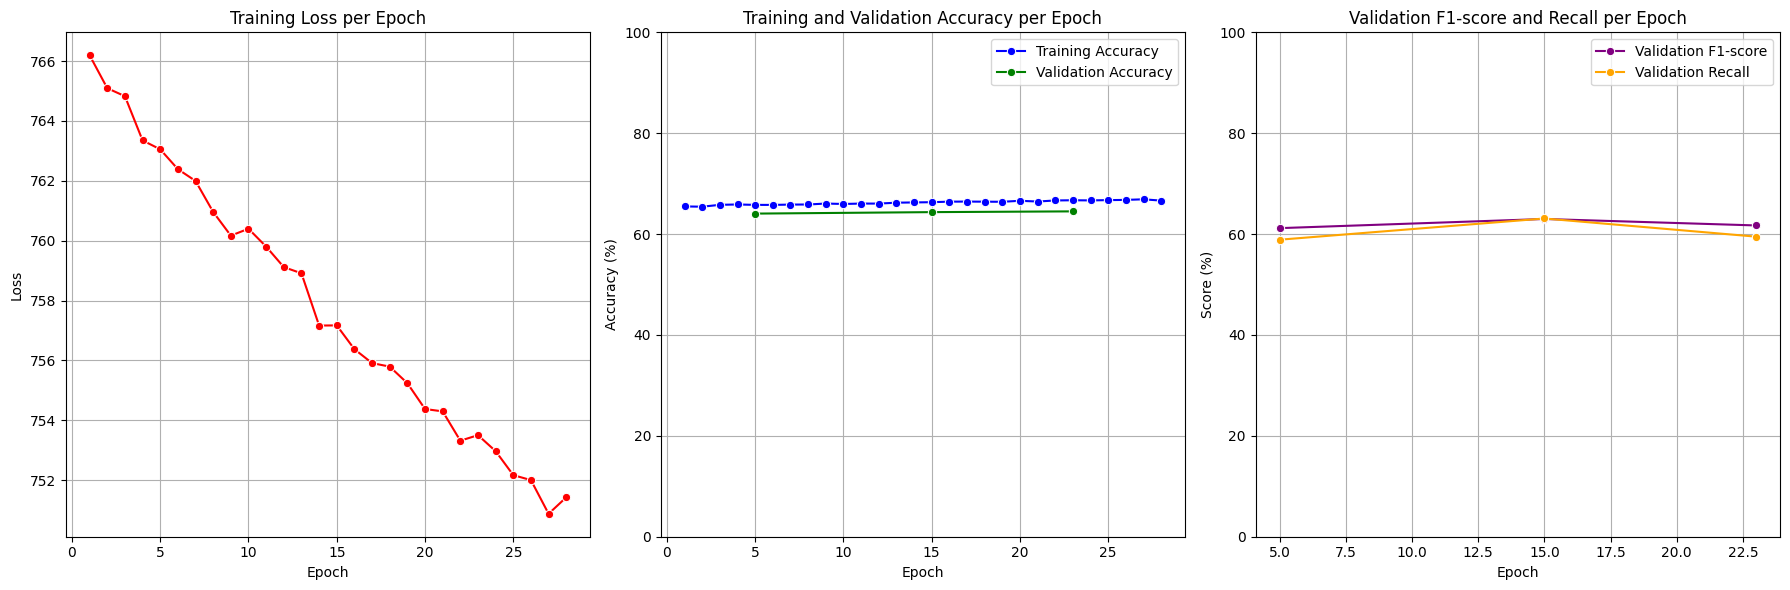

In [ ]:
# Combine the presaved metrics with the currently loaded metrics from the checkpoint.
# Make sure these lists are actually loaded from the checkpoint in cell 0tK_RdvP0D-5 before running this cell.
# If the current training run started from epoch 8 and the lists were successfully loaded,
# then the current lists already contain data from epoch 1-7. So we just need to append.

# Assuming `train_losses`, `train_accuracies`, `val_accuracies`, `val_f1_scores`, `val_recalls`
# already contain the loaded history up to `start_epoch - 1` (i.e., epoch 7's data).
# If they do, then we don't need to prepend `presaved_` lists.
# If they are empty because the checkpoint loading failed for some reason, then we should prepend.

# Let's check if the lists are empty or already contain data.
# The previous modification to cell 0tK_RdvP0D-5 already loads the full history into these lists.
# So, this cell will now just re-run the plotting based on the *already correctly populated* lists.

# The current epoch range should be derived from the length of `train_losses`.
epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(18, 6)) # Increase figure size to accommodate more plots

# Plotting Training Loss
plt.subplot(1, 3, 1) # 1 row, 3 columns, 1st plot
sns.lineplot(x=epochs_range, y=train_losses, marker='o', color='red')
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

# Plotting Training and Validation Accuracy
plt.subplot(1, 3, 2) # 1 row, 3 columns, 2nd plot
sns.lineplot(x=epochs_range, y=train_accuracies, marker='o', label='Training Accuracy', color='blue')

# Filter out None values for validation metrics before plotting
val_epochs_with_data = [e for e, acc in zip(epochs_range, val_accuracies) if acc is not None]
val_accuracies_filtered = [acc for acc in val_accuracies if acc is not None]
if val_accuracies_filtered:
    sns.lineplot(x=val_epochs_with_data, y=val_accuracies_filtered, marker='o', label='Validation Accuracy', color='green')

plt.title('Training and Validation Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
plt.legend()
plt.grid(True)

# Plotting Validation F1-score and Recall
plt.subplot(1, 3, 3) # 1 row, 3 columns, 3rd plot

# Filter out None values for F1-score and Recall before plotting
val_f1_filtered = [f1 for f1 in val_f1_scores if f1 is not None]
val_recall_filtered = [rec for rec in val_recalls if rec is not None]

if val_f1_filtered:
    sns.lineplot(x=val_epochs_with_data, y=val_f1_filtered, marker='o', label='Validation F1-score', color='purple')
if val_recall_filtered:
    sns.lineplot(x=val_epochs_with_data, y=val_recall_filtered, marker='o', label='Validation Recall', color='orange')

plt.title('Validation F1-score and Recall per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Score (%)')
plt.ylim(0, 100)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()